<a href="https://colab.research.google.com/github/lpodina/conformal_pinns/blob/main/Alpha_interval_Conformal_PINNs_noisy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from collections import OrderedDict
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from scipy.interpolate import griddata
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
import warnings
from scipy.integrate import odeint
from matplotlib import style
import numpy as np

warnings.filterwarnings('ignore')

np.random.seed(1234)

# CUDA support
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f"Device is {device}")
"""## Physics-informed Neural Networks"""

# define the right-hand side
def logistic_growth(N, t, r, K):
    return r * N * (1 - N/K)

Device is cuda


In [ ]:
def generate_data(noise, alpha, id):
  '''generates and returns data (logistic growth) using input parameters
     noise: amount of noise to add (>= 0)
     alpha: growth rate
     id: experiment id under which to save

     returns: dict {"t": numpy array with all time points,
                    "t_train": numpy array with training points (t),
                    "t_test": numpy array with test points (t),
                    "t_cal": numpy array with calibration points (t),

                    "N": numpy array with all points (N),
                    "N_train": numpy array with train points (N),
                    "N_test": numpy array with test points (N),
                    "N_cal": numpy array with calibration points (N),

                    "alpha": real value of current alpha,
                    "id": id of experiment,
                    "noise": noise of generated data}
  '''

  max_t = 150
  step_size = 1.0
  #step_size = 0.1 # MTR
  noise = noise # e.g. 0.0 or 0.03 <- change this to 0.03 to see how noise will affect performance

  t = np.arange(0, max_t, step_size) #0.1
  p_ = (alpha, 1.0)

  ic = 0.1
  # X is ideal noiseless data
  X = odeint(logistic_growth, ic, t, args=p_)

  # Add noise according to the mean
  xbar = np.mean(X, axis=0)
  Xn = X + noise * xbar * np.random.randn(*X.shape)

  t_cal, t_traintest, N_cal, N_traintest = train_test_split(t, Xn, test_size=0.33, random_state=42)
  t_train, t_test, N_train, N_test = train_test_split(t_traintest, N_traintest, test_size=0.50, random_state=42)

  print(f"num calibration: {t_cal.shape},{N_cal.shape}")
  print(f"num train: {t_train.shape},{N_train.shape}")
  print(f"num test: {t_test.shape},{N_test.shape}")

  t_train = np.expand_dims(t_train.copy(),axis=1)
  t_test = np.expand_dims(t_test.copy(),axis=1)
  t_cal = np.expand_dims(t_cal.copy(),axis=1)

  # plot the data for sanity check
  plt.grid()
  plt.title("Data points")
  plt.xlabel("Time")
  plt.ylabel("N")
  plt.plot(t, Xn,'o',label='all')
  plt.plot(t_train, N_train,'o',label='train')
  plt.legend()
  plt.savefig(f'data_{id}')
  plt.show()
  plt.clf()

  return {"id": id,
          "alpha": alpha,
          "noise": noise,

          "t": t,
          "t_train": t_train,
          "t_test": t_test,
          "t_cal": t_cal,

          "N": Xn,
          "N_train": N_train,
          "N_test": N_test,
          "N_cal": N_cal}

num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


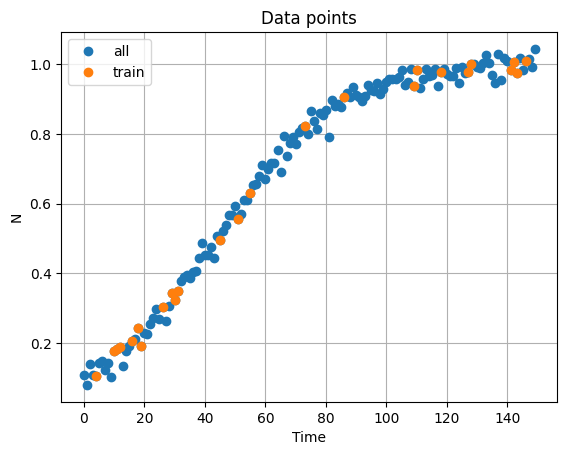

<Figure size 640x480 with 0 Axes>

In [ ]:
generate_data(0.03, 0.05, 0);

In [ ]:

# the deep neural network
class DNN(torch.nn.Module):
    def __init__(self, layers, min_val, max_val):
        super(DNN, self).__init__()

        # parameters
        self.depth = len(layers) - 1

        self.min_val = torch.tensor([min_val], requires_grad=True).float().to(device)
        self.max_val = torch.tensor([max_val], requires_grad=True).float().to(device)

        # set up layer order dict
        self.activation = torch.nn.Tanh

        layer_list = list()
        for i in range(self.depth - 1):
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i+1]))
            )
            layer_list.append(('activation_%d' % i, self.activation()))

        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)

        # deploy layers
        self.layers = torch.nn.Sequential(layerDict)

    def forward(self, x):
        res = (x - self.min_val) / (self.max_val - self.min_val)
        out = self.layers(res)
        return out

max_lr = -1
min_lr = -3

time_delta = 30000
warm_ups = 1000
rate = (min_lr - max_lr) / time_delta

def lr_schedule(epoch):
    """Linear annealing LR schedule."""
    if epoch < warm_ups:
        return 10**(max_lr)
    elif epoch < time_delta:
        return 10**(rate * (epoch - warm_ups) + max_lr)
    else:
        return 10**min_lr

# the physics-guided neural network
class PhysicsInformedNN():
    def __init__(self, t_colloc, layers, t_train, u_data):

        # save the training data
        self.t_train = torch.tensor(t_train, requires_grad=True).float().to(device) # t
        self.u_data = torch.tensor(u_data, requires_grad=True).float().to(device) # N

        # save the collocation times as well
        self.t_colloc = torch.tensor(t_colloc, requires_grad=True).float().to(device)

        # You need to know the parameters of the differential equation
        self.r = torch.tensor([0.01], requires_grad=True).float().to(device) # parameters
        self.K = torch.tensor([1.0], requires_grad=True).float().to(device)

        # deep neural networks
        print(f"layers: {layers}")

        self.dnn = DNN(layers,0.0,150.0).to(device)

        # optional 4 lines: if you want to fit the parameters as well
        self.r = torch.nn.Parameter(self.r)
        # self.K = torch.nn.Parameter(self.K) # assume K to be known
        self.dnn.register_parameter('r', self.r)
        # self.dnn.register_parameter('K', self.K)

         # optimizers: using the same settings
        self.optimizer = torch.optim.LBFGS(
            self.dnn.parameters(),
            lr=1.0,
            max_iter=50000,
            max_eval=50000,
            history_size=50,
            tolerance_grad=0,#1e-8,
            tolerance_change=0,#1.0 * np.finfo(float).eps,
            line_search_fn="strong_wolfe"       # can be "strong_wolfe"
        )

        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters())
        self.scheduler = torch.optim.lr_scheduler.LambdaLR(self.optimizer_Adam, lr_lambda=lr_schedule)
        self.iter = 0

    def net_u(self, t):
        u = self.dnn(t)
        return u

    def net_f(self, t_colloc):
        """ The pytorch autograd version of calculating residual """
        u_colloc = self.net_u(t_colloc)

        _u = torch.unsqueeze(u_colloc[:, 0],axis=1)

        u_t = torch.autograd.grad(
            _u, t_colloc,
            grad_outputs=torch.ones_like(_u),
            retain_graph=True,
            create_graph=True,
        )[0]

        u_dot = self.r * _u * (1 - _u/self.K)
        loss_pinn = torch.mean(torch.square(u_t - u_dot))

        return loss_pinn

    # this loss func is for the LBFGS optimizer
    def loss_func(self):
        self.optimizer.zero_grad()

        # compute the loss
        u_pred = self.net_u(self.t_train)
        data_loss = torch.mean((self.u_data - u_pred) ** 2) # mse loss
        pinn_loss = self.net_f(self.t_colloc) # pinn loss

        loss = data_loss + pinn_loss # add them together to get final loss

        loss.backward()

        self.iter += 1
        if self.iter % 100 == 0:
            print(
                'Loss: %.3e, pinn loss: %.3e, data loss: %.3e, r: %.3f, K: %.6f' %
                (
                    loss.item(),
                    pinn_loss.item(),
                    data_loss.item(),
                    self.r.item(),
                    self.K.item()
                )
            )
        return loss

    def train(self, adam_epochs, bfgs_epochs, polish_adam_epochs):
        self.dnn.train()

        for epoch in range(adam_epochs):
            u_pred = self.net_u(self.t_train)
            data_loss = torch.mean((self.u_data - u_pred) ** 2)
            pinn_loss = self.net_f(self.t_colloc)

            loss = data_loss + pinn_loss

            # Backward and optimize
            self.optimizer_Adam.zero_grad()
            loss.backward()
            self.optimizer_Adam.step()
            self.scheduler.step()

            if epoch % 100 == 0:
                print(
                    'It: %d, Loss: %.3e, pinn loss: %.3e, data loss: %.3e, r: %.3f, K: %.6f' %
                    (
                        epoch,
                        loss.item(),
                        pinn_loss.item(),
                        data_loss.item(),
                        self.r.item(),
                        self.K.item()
                    )
                )
        self.optimizer.step(self.loss_func)

    def predict(self, t):
        t = torch.tensor(t, requires_grad=True).float().to(device)

        self.dnn.eval()
        u = self.net_u(t)
        u = u.detach().cpu().numpy()
        return u

Step 2. Set Up Training
true alphas:  [0.    0.005 0.01  0.015 0.02  0.025 0.03  0.035 0.04  0.045 0.05  0.055
 0.06  0.065 0.07  0.075 0.08  0.085 0.09  0.095 0.1   0.105 0.11  0.115
 0.12  0.125 0.13  0.135 0.14  0.145 0.15  0.155 0.16  0.165 0.17  0.175
 0.18  0.185 0.19  0.195 0.2   0.205 0.21  0.215 0.22  0.225 0.23  0.235
 0.24  0.245 0.25  0.255 0.26  0.265 0.27  0.275 0.28  0.285 0.29  0.295
 0.3   0.305 0.31  0.315 0.32  0.325 0.33  0.335 0.34  0.345 0.35  0.355
 0.36  0.365 0.37  0.375 0.38  0.385 0.39  0.395 0.4   0.405 0.41  0.415
 0.42  0.425 0.43  0.435 0.44  0.445 0.45  0.455 0.46  0.465 0.47  0.475
 0.48  0.485 0.49  0.495]
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


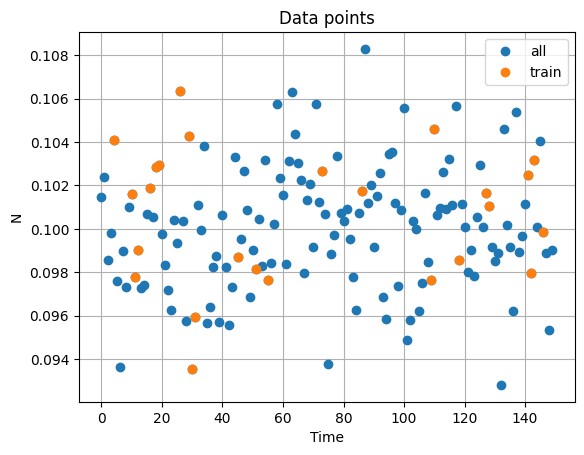

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 8.702e-02, pinn loss: 5.464e-06, data loss: 8.702e-02, r: 0.010, K: 1.000000
It: 100, Loss: 4.219e-03, pinn loss: 2.478e-08, data loss: 4.219e-03, r: 0.006, K: 1.000000
It: 200, Loss: 1.810e-05, pinn loss: 1.019e-07, data loss: 1.799e-05, r: 0.004, K: 1.000000
It: 300, Loss: 1.505e-05, pinn loss: 2.283e-08, data loss: 1.502e-05, r: 0.002, K: 1.000000
It: 400, Loss: 1.295e-05, pinn loss: 4.323e-09, data loss: 1.295e-05, r: 0.001, K: 1.000000
It: 500, Loss: 1.152e-05, pinn loss: 1.036e-09, data loss: 1.152e-05, r: 0.001, K: 1.000000
It: 600, Loss: 1.062e-05, pinn loss: 5.210e-10, data loss: 1.062e-05, r: 0.000, K: 1.000000
It: 700, Loss: 1.009e-05, pinn loss: 4.281e-10, data loss: 1.009e-05, r: 0.000, K: 1.000000
It: 800, Loss: 9.813e-06, pinn loss: 4.029e-10, data loss: 9.813e-06, r: 0.000, K: 1.000000
It: 900, Loss: 9.674e-06, pinn loss: 3.925e-10, data loss: 9.674e-06, r: 0.000, K: 1.000000
estimated alpha:  4.185210855212062

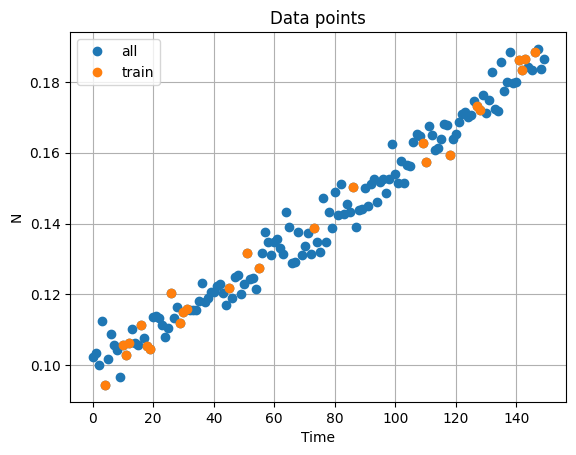

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 6.629e-03, pinn loss: 3.813e-07, data loss: 6.628e-03, r: 0.010, K: 1.000000
It: 100, Loss: 8.221e-04, pinn loss: 6.096e-09, data loss: 8.221e-04, r: 0.001, K: 1.000000
It: 200, Loss: 1.766e-04, pinn loss: 1.565e-08, data loss: 1.766e-04, r: 0.002, K: 1.000000
It: 300, Loss: 1.723e-05, pinn loss: 1.577e-08, data loss: 1.722e-05, r: 0.005, K: 1.000000
It: 400, Loss: 1.707e-05, pinn loss: 1.495e-08, data loss: 1.706e-05, r: 0.005, K: 1.000000
It: 500, Loss: 1.691e-05, pinn loss: 1.430e-08, data loss: 1.690e-05, r: 0.005, K: 1.000000
It: 600, Loss: 1.675e-05, pinn loss: 1.361e-08, data loss: 1.673e-05, r: 0.005, K: 1.000000
It: 700, Loss: 1.658e-05, pinn loss: 1.291e-08, data loss: 1.657e-05, r: 0.005, K: 1.000000
It: 800, Loss: 1.641e-05, pinn loss: 1.219e-08, data loss: 1.640e-05, r: 0.005, K: 1.000000
It: 900, Loss: 1.625e-05, pinn loss: 1.147e-08, data loss: 1.624e-05, r: 0.005, K: 1.000000
Loss: 1.256e-05, pinn loss: 1.598e-

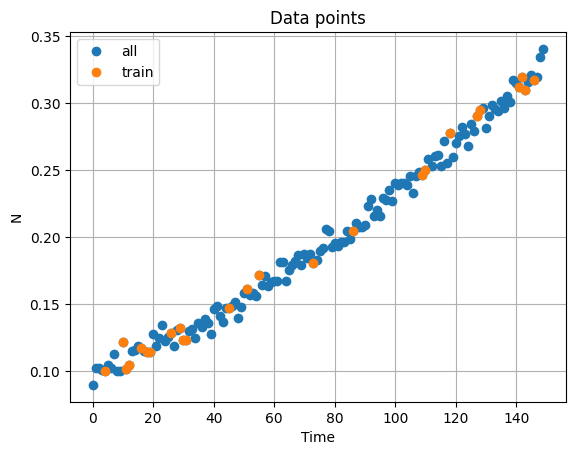

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 4.556e-02, pinn loss: 2.254e-09, data loss: 4.556e-02, r: 0.010, K: 1.000000
It: 100, Loss: 5.888e-03, pinn loss: 3.538e-09, data loss: 5.888e-03, r: 0.000, K: 1.000000
It: 200, Loss: 4.123e-03, pinn loss: 1.150e-08, data loss: 4.123e-03, r: 0.002, K: 1.000000
It: 300, Loss: 9.360e-04, pinn loss: 1.996e-07, data loss: 9.358e-04, r: 0.006, K: 1.000000
It: 400, Loss: 2.343e-04, pinn loss: 5.659e-07, data loss: 2.337e-04, r: 0.008, K: 1.000000
It: 500, Loss: 2.103e-04, pinn loss: 5.032e-07, data loss: 2.098e-04, r: 0.008, K: 1.000000
It: 600, Loss: 1.881e-04, pinn loss: 4.470e-07, data loss: 1.876e-04, r: 0.008, K: 1.000000
It: 700, Loss: 1.678e-04, pinn loss: 3.955e-07, data loss: 1.674e-04, r: 0.009, K: 1.000000
It: 800, Loss: 1.495e-04, pinn loss: 3.486e-07, data loss: 1.492e-04, r: 0.009, K: 1.000000
It: 900, Loss: 1.332e-04, pinn loss: 3.061e-07, data loss: 1.329e-04, r: 0.009, K: 1.000000
estimated alpha:  0.009863650426268

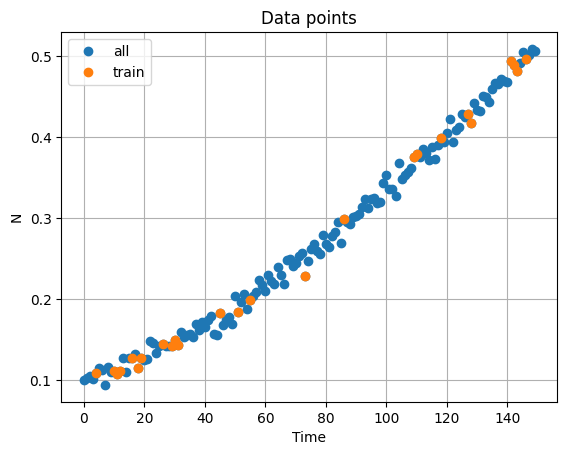

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 8.457e-02, pinn loss: 4.224e-09, data loss: 8.457e-02, r: 0.010, K: 1.000000
It: 100, Loss: 2.438e-02, pinn loss: 2.168e-09, data loss: 2.438e-02, r: 0.000, K: 1.000000
It: 200, Loss: 1.876e-02, pinn loss: 2.785e-09, data loss: 1.876e-02, r: 0.001, K: 1.000000
It: 300, Loss: 1.346e-02, pinn loss: 3.262e-08, data loss: 1.346e-02, r: 0.003, K: 1.000000
It: 400, Loss: 8.912e-04, pinn loss: 1.547e-06, data loss: 8.897e-04, r: 0.012, K: 1.000000
It: 500, Loss: 7.151e-04, pinn loss: 1.684e-06, data loss: 7.135e-04, r: 0.013, K: 1.000000
It: 600, Loss: 6.317e-04, pinn loss: 1.485e-06, data loss: 6.302e-04, r: 0.013, K: 1.000000
It: 700, Loss: 5.564e-04, pinn loss: 1.302e-06, data loss: 5.551e-04, r: 0.013, K: 1.000000
It: 800, Loss: 4.889e-04, pinn loss: 1.137e-06, data loss: 4.878e-04, r: 0.013, K: 1.000000
It: 900, Loss: 4.287e-04, pinn loss: 9.884e-07, data loss: 4.278e-04, r: 0.013, K: 1.000000
estimated alpha:  0.014968652278184

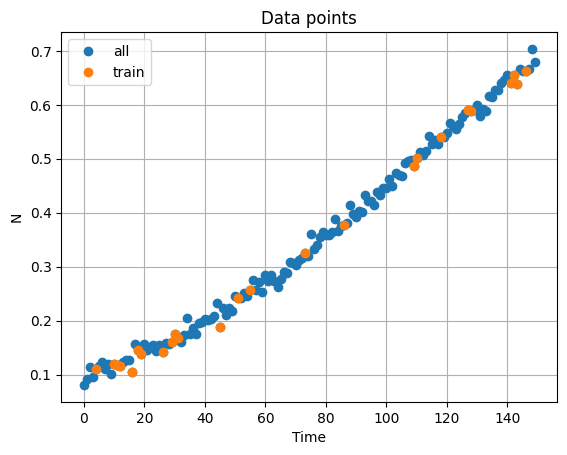

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 6.575e-02, pinn loss: 2.259e-06, data loss: 6.575e-02, r: 0.010, K: 1.000000
It: 100, Loss: 4.252e-02, pinn loss: 5.923e-08, data loss: 4.252e-02, r: 0.001, K: 1.000000
It: 200, Loss: 2.717e-02, pinn loss: 1.718e-07, data loss: 2.717e-02, r: 0.002, K: 1.000000
It: 300, Loss: 5.636e-04, pinn loss: 2.038e-06, data loss: 5.616e-04, r: 0.015, K: 1.000000
It: 400, Loss: 4.533e-04, pinn loss: 1.231e-06, data loss: 4.521e-04, r: 0.018, K: 1.000000
It: 500, Loss: 3.701e-04, pinn loss: 9.921e-07, data loss: 3.691e-04, r: 0.018, K: 1.000000
It: 600, Loss: 2.998e-04, pinn loss: 7.840e-07, data loss: 2.990e-04, r: 0.019, K: 1.000000
It: 700, Loss: 2.425e-04, pinn loss: 6.084e-07, data loss: 2.419e-04, r: 0.019, K: 1.000000
It: 800, Loss: 1.976e-04, pinn loss: 4.646e-07, data loss: 1.971e-04, r: 0.019, K: 1.000000
It: 900, Loss: 1.636e-04, pinn loss: 3.500e-07, data loss: 1.632e-04, r: 0.019, K: 1.000000
estimated alpha:  0.019695501774549

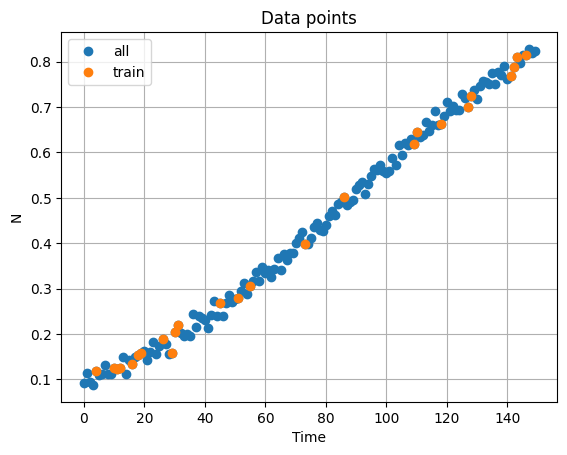

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 5.308e-01, pinn loss: 1.315e-05, data loss: 5.308e-01, r: 0.010, K: 1.000000
It: 100, Loss: 2.583e-01, pinn loss: 6.280e-08, data loss: 2.583e-01, r: 0.005, K: 1.000000
It: 200, Loss: 7.092e-02, pinn loss: 3.393e-07, data loss: 7.092e-02, r: 0.003, K: 1.000000
It: 300, Loss: 5.748e-02, pinn loss: 6.645e-08, data loss: 5.748e-02, r: 0.002, K: 1.000000
It: 400, Loss: 4.469e-02, pinn loss: 3.539e-07, data loss: 4.469e-02, r: 0.003, K: 1.000000
It: 500, Loss: 1.548e-02, pinn loss: 3.465e-06, data loss: 1.547e-02, r: 0.008, K: 1.000000
It: 600, Loss: 3.541e-03, pinn loss: 1.117e-05, data loss: 3.530e-03, r: 0.018, K: 1.000000
It: 700, Loss: 3.198e-03, pinn loss: 1.020e-05, data loss: 3.188e-03, r: 0.021, K: 1.000000
It: 800, Loss: 2.892e-03, pinn loss: 9.238e-06, data loss: 2.883e-03, r: 0.021, K: 1.000000
It: 900, Loss: 2.611e-03, pinn loss: 8.359e-06, data loss: 2.603e-03, r: 0.021, K: 1.000000
Loss: 1.599e-04, pinn loss: 4.114e-

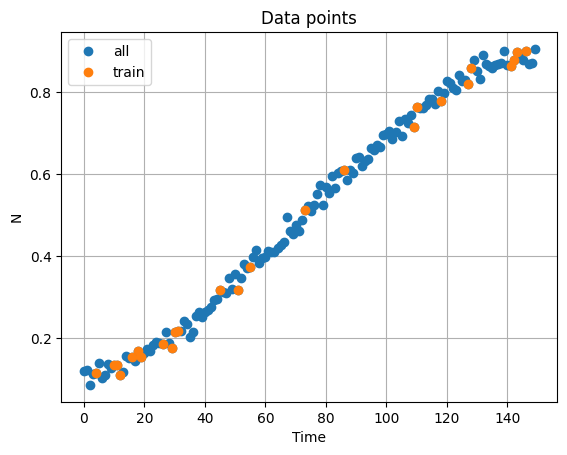

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 2.927e-01, pinn loss: 3.613e-09, data loss: 2.927e-01, r: 0.010, K: 1.000000
It: 100, Loss: 1.312e-01, pinn loss: 5.289e-09, data loss: 1.312e-01, r: 0.000, K: 1.000000
It: 200, Loss: 7.165e-02, pinn loss: 7.173e-08, data loss: 7.165e-02, r: 0.003, K: 1.000000
It: 300, Loss: 1.683e-02, pinn loss: 2.154e-06, data loss: 1.683e-02, r: 0.014, K: 1.000000
It: 400, Loss: 1.999e-03, pinn loss: 7.296e-06, data loss: 1.991e-03, r: 0.029, K: 1.000000
It: 500, Loss: 1.708e-03, pinn loss: 6.211e-06, data loss: 1.702e-03, r: 0.029, K: 1.000000
It: 600, Loss: 1.455e-03, pinn loss: 5.318e-06, data loss: 1.450e-03, r: 0.029, K: 1.000000
It: 700, Loss: 1.239e-03, pinn loss: 4.539e-06, data loss: 1.234e-03, r: 0.029, K: 1.000000
It: 800, Loss: 1.056e-03, pinn loss: 3.867e-06, data loss: 1.052e-03, r: 0.029, K: 1.000000
It: 900, Loss: 9.023e-04, pinn loss: 3.294e-06, data loss: 8.990e-04, r: 0.029, K: 1.000000
Loss: 2.067e-04, pinn loss: 7.126e-

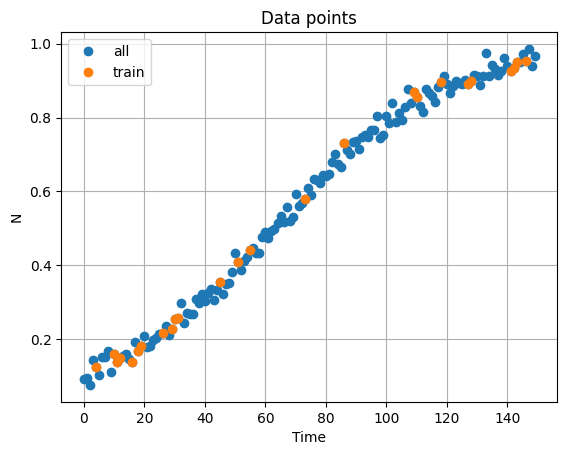

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 4.682e-01, pinn loss: 1.079e-06, data loss: 4.682e-01, r: 0.010, K: 1.000000
It: 100, Loss: 2.523e-01, pinn loss: 1.793e-07, data loss: 2.523e-01, r: 0.005, K: 1.000000
It: 200, Loss: 1.036e-01, pinn loss: 1.832e-08, data loss: 1.036e-01, r: 0.001, K: 1.000000
It: 300, Loss: 8.607e-02, pinn loss: 7.843e-08, data loss: 8.607e-02, r: 0.003, K: 1.000000
It: 400, Loss: 5.097e-02, pinn loss: 6.041e-07, data loss: 5.097e-02, r: 0.008, K: 1.000000
It: 500, Loss: 2.380e-03, pinn loss: 7.051e-06, data loss: 2.372e-03, r: 0.029, K: 1.000000
It: 600, Loss: 1.679e-03, pinn loss: 7.694e-06, data loss: 1.671e-03, r: 0.035, K: 1.000000
It: 700, Loss: 1.487e-03, pinn loss: 6.813e-06, data loss: 1.480e-03, r: 0.035, K: 1.000000
It: 800, Loss: 1.327e-03, pinn loss: 6.071e-06, data loss: 1.321e-03, r: 0.035, K: 1.000000
It: 900, Loss: 1.196e-03, pinn loss: 5.449e-06, data loss: 1.191e-03, r: 0.035, K: 1.000000
estimated alpha:  0.036263138055801

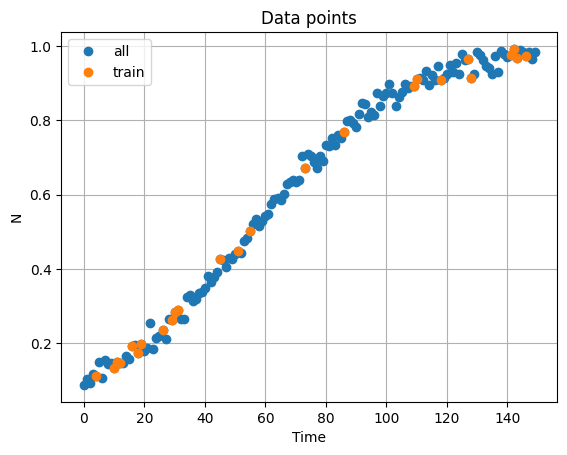

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 7.023e-01, pinn loss: 7.695e-06, data loss: 7.023e-01, r: 0.010, K: 1.000000
It: 100, Loss: 3.449e-01, pinn loss: 2.991e-08, data loss: 3.449e-01, r: 0.006, K: 1.000000
It: 200, Loss: 1.142e-01, pinn loss: 5.325e-08, data loss: 1.142e-01, r: 0.002, K: 1.000000
It: 300, Loss: 9.537e-02, pinn loss: 9.042e-08, data loss: 9.537e-02, r: 0.002, K: 1.000000
It: 400, Loss: 7.573e-02, pinn loss: 4.199e-07, data loss: 7.573e-02, r: 0.005, K: 1.000000
It: 500, Loss: 2.199e-02, pinn loss: 5.407e-06, data loss: 2.199e-02, r: 0.013, K: 1.000000
It: 600, Loss: 2.398e-03, pinn loss: 1.668e-05, data loss: 2.382e-03, r: 0.031, K: 1.000000
It: 700, Loss: 1.977e-03, pinn loss: 1.391e-05, data loss: 1.964e-03, r: 0.038, K: 1.000000
It: 800, Loss: 1.665e-03, pinn loss: 1.217e-05, data loss: 1.652e-03, r: 0.039, K: 1.000000
It: 900, Loss: 1.417e-03, pinn loss: 1.080e-05, data loss: 1.406e-03, r: 0.039, K: 1.000000
estimated alpha:  0.039735347032547

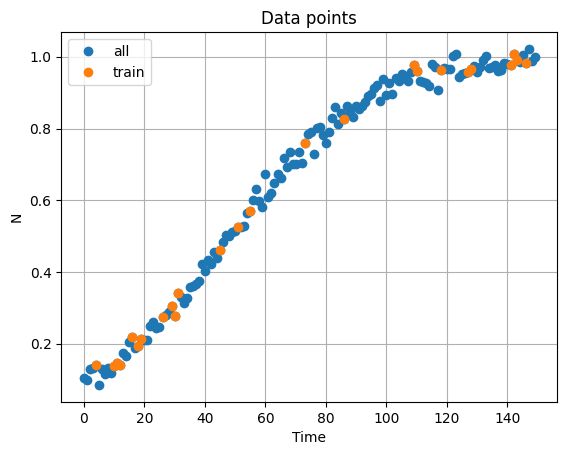

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 3.133e-01, pinn loss: 1.421e-06, data loss: 3.133e-01, r: 0.010, K: 1.000000
It: 100, Loss: 1.626e-01, pinn loss: 2.956e-08, data loss: 1.626e-01, r: 0.001, K: 1.000000
It: 200, Loss: 9.935e-02, pinn loss: 7.263e-08, data loss: 9.935e-02, r: 0.002, K: 1.000000
It: 300, Loss: 1.252e-02, pinn loss: 4.522e-06, data loss: 1.251e-02, r: 0.014, K: 1.000000
It: 400, Loss: 5.402e-04, pinn loss: 5.148e-06, data loss: 5.351e-04, r: 0.033, K: 1.000000
It: 500, Loss: 5.333e-04, pinn loss: 2.582e-06, data loss: 5.307e-04, r: 0.040, K: 1.000000
It: 600, Loss: 5.286e-04, pinn loss: 2.309e-06, data loss: 5.263e-04, r: 0.043, K: 1.000000
It: 700, Loss: 5.236e-04, pinn loss: 2.250e-06, data loss: 5.214e-04, r: 0.043, K: 1.000000
It: 800, Loss: 5.182e-04, pinn loss: 2.202e-06, data loss: 5.160e-04, r: 0.044, K: 1.000000
It: 900, Loss: 5.124e-04, pinn loss: 2.150e-06, data loss: 5.102e-04, r: 0.044, K: 1.000000
estimated alpha:  0.045748550444841

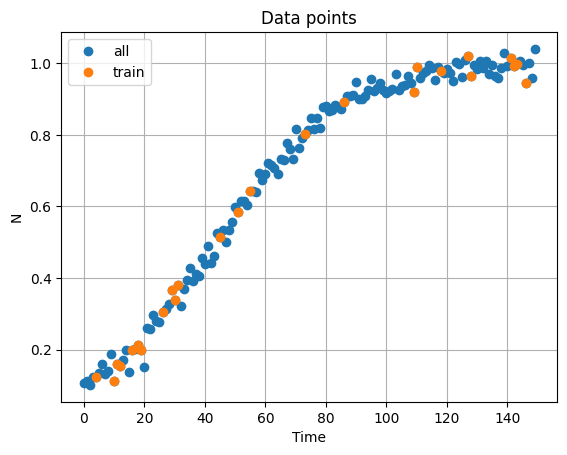

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 4.113e-01, pinn loss: 2.421e-07, data loss: 4.113e-01, r: 0.010, K: 1.000000
It: 100, Loss: 2.299e-01, pinn loss: 6.872e-10, data loss: 2.299e-01, r: 0.000, K: 1.000000
It: 200, Loss: 1.197e-01, pinn loss: 5.522e-09, data loss: 1.197e-01, r: 0.001, K: 1.000000
It: 300, Loss: 1.092e-01, pinn loss: 2.254e-08, data loss: 1.092e-01, r: 0.001, K: 1.000000
It: 400, Loss: 8.763e-02, pinn loss: 1.825e-07, data loss: 8.763e-02, r: 0.004, K: 1.000000
It: 500, Loss: 8.236e-03, pinn loss: 4.182e-06, data loss: 8.232e-03, r: 0.024, K: 1.000000
It: 600, Loss: 7.728e-04, pinn loss: 6.750e-06, data loss: 7.660e-04, r: 0.046, K: 1.000000
It: 700, Loss: 7.696e-04, pinn loss: 6.546e-06, data loss: 7.631e-04, r: 0.048, K: 1.000000
It: 800, Loss: 7.665e-04, pinn loss: 6.496e-06, data loss: 7.600e-04, r: 0.048, K: 1.000000
It: 900, Loss: 7.631e-04, pinn loss: 6.440e-06, data loss: 7.566e-04, r: 0.048, K: 1.000000
Loss: 4.627e-04, pinn loss: 1.608e-

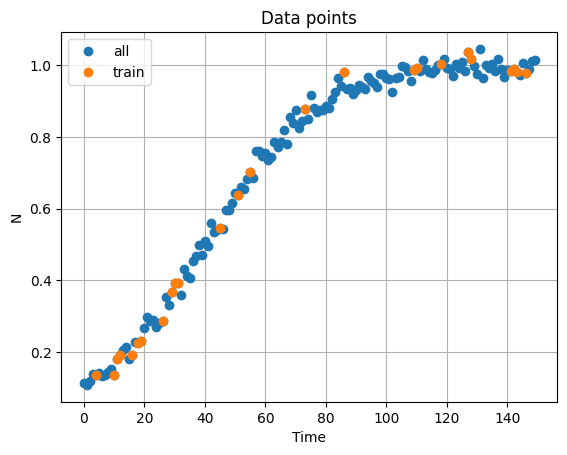

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 3.681e-01, pinn loss: 1.250e-06, data loss: 3.681e-01, r: 0.010, K: 1.000000
It: 100, Loss: 1.930e-01, pinn loss: 3.103e-08, data loss: 1.930e-01, r: 0.001, K: 1.000000
It: 200, Loss: 1.183e-01, pinn loss: 9.151e-09, data loss: 1.183e-01, r: 0.001, K: 1.000000
It: 300, Loss: 7.250e-02, pinn loss: 2.291e-07, data loss: 7.250e-02, r: 0.005, K: 1.000000
It: 400, Loss: 4.756e-03, pinn loss: 8.862e-06, data loss: 4.747e-03, r: 0.025, K: 1.000000
It: 500, Loss: 3.475e-03, pinn loss: 7.290e-06, data loss: 3.467e-03, r: 0.037, K: 1.000000
It: 600, Loss: 2.650e-03, pinn loss: 5.903e-06, data loss: 2.644e-03, r: 0.041, K: 1.000000
It: 700, Loss: 2.028e-03, pinn loss: 5.050e-06, data loss: 2.023e-03, r: 0.044, K: 1.000000
It: 800, Loss: 1.603e-03, pinn loss: 4.545e-06, data loss: 1.599e-03, r: 0.047, K: 1.000000
It: 900, Loss: 1.342e-03, pinn loss: 4.314e-06, data loss: 1.338e-03, r: 0.049, K: 1.000000
Loss: 3.078e-04, pinn loss: 1.667e-

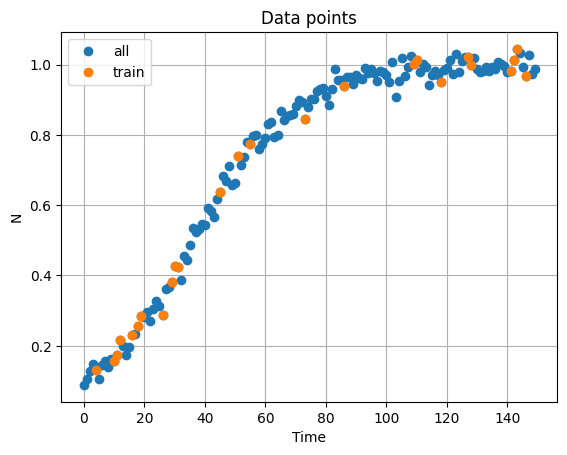

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 7.787e-01, pinn loss: 4.444e-06, data loss: 7.787e-01, r: 0.010, K: 1.000000
It: 100, Loss: 3.957e-01, pinn loss: 2.105e-07, data loss: 3.957e-01, r: 0.006, K: 1.000000
It: 200, Loss: 1.274e-01, pinn loss: 2.108e-08, data loss: 1.274e-01, r: 0.001, K: 1.000000
It: 300, Loss: 1.009e-01, pinn loss: 5.429e-08, data loss: 1.009e-01, r: 0.002, K: 1.000000
It: 400, Loss: 8.458e-02, pinn loss: 2.251e-07, data loss: 8.458e-02, r: 0.004, K: 1.000000
It: 500, Loss: 4.037e-02, pinn loss: 1.788e-06, data loss: 4.037e-02, r: 0.012, K: 1.000000
It: 600, Loss: 2.752e-03, pinn loss: 1.037e-05, data loss: 2.742e-03, r: 0.034, K: 1.000000
It: 700, Loss: 2.002e-03, pinn loss: 1.268e-05, data loss: 1.989e-03, r: 0.046, K: 1.000000
It: 800, Loss: 1.948e-03, pinn loss: 1.289e-05, data loss: 1.935e-03, r: 0.049, K: 1.000000
It: 900, Loss: 1.901e-03, pinn loss: 1.327e-05, data loss: 1.887e-03, r: 0.050, K: 1.000000
Loss: 6.460e-04, pinn loss: 1.795e-

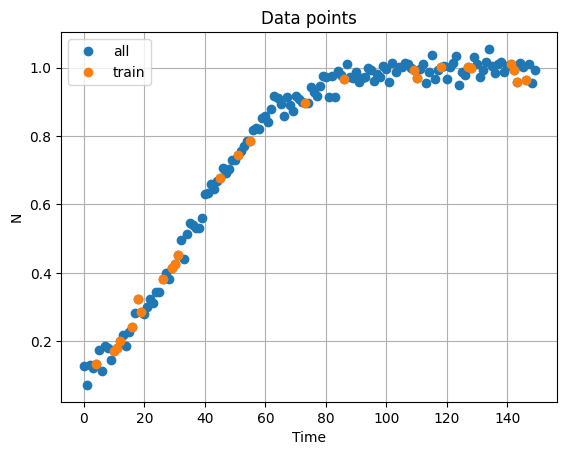

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 5.329e-01, pinn loss: 3.998e-10, data loss: 5.329e-01, r: 0.010, K: 1.000000
It: 100, Loss: 2.232e-01, pinn loss: 5.326e-09, data loss: 2.232e-01, r: 0.000, K: 1.000000
It: 200, Loss: 1.034e-01, pinn loss: 1.189e-08, data loss: 1.034e-01, r: 0.001, K: 1.000000
It: 300, Loss: 9.220e-02, pinn loss: 4.891e-08, data loss: 9.220e-02, r: 0.003, K: 1.000000
It: 400, Loss: 5.195e-02, pinn loss: 3.790e-07, data loss: 5.195e-02, r: 0.010, K: 1.000000
It: 500, Loss: 3.738e-03, pinn loss: 5.246e-06, data loss: 3.733e-03, r: 0.037, K: 1.000000
It: 600, Loss: 2.879e-03, pinn loss: 6.881e-06, data loss: 2.872e-03, r: 0.045, K: 1.000000
It: 700, Loss: 2.270e-03, pinn loss: 7.054e-06, data loss: 2.263e-03, r: 0.047, K: 1.000000
It: 800, Loss: 1.790e-03, pinn loss: 7.597e-06, data loss: 1.783e-03, r: 0.049, K: 1.000000
It: 900, Loss: 1.455e-03, pinn loss: 8.455e-06, data loss: 1.447e-03, r: 0.051, K: 1.000000
Loss: 2.514e-04, pinn loss: 4.681e-

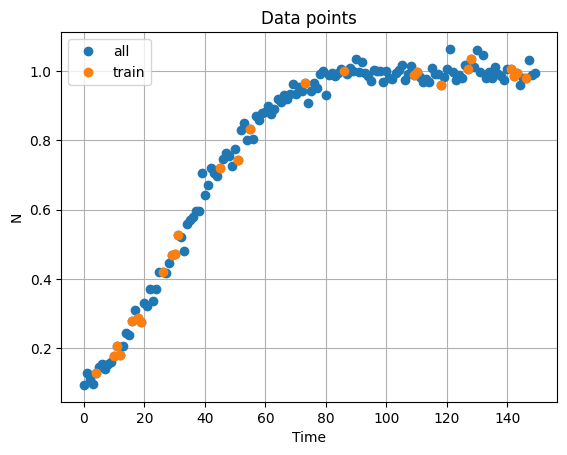

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 8.952e-01, pinn loss: 7.219e-06, data loss: 8.952e-01, r: 0.010, K: 1.000000
It: 100, Loss: 5.078e-01, pinn loss: 1.772e-08, data loss: 5.078e-01, r: 0.005, K: 1.000000
It: 200, Loss: 1.363e-01, pinn loss: 4.791e-08, data loss: 1.363e-01, r: 0.002, K: 1.000000
It: 300, Loss: 9.921e-02, pinn loss: 3.700e-08, data loss: 9.921e-02, r: 0.002, K: 1.000000
It: 400, Loss: 8.834e-02, pinn loss: 1.272e-07, data loss: 8.834e-02, r: 0.003, K: 1.000000
It: 500, Loss: 5.261e-02, pinn loss: 1.059e-06, data loss: 5.261e-02, r: 0.008, K: 1.000000
It: 600, Loss: 4.610e-03, pinn loss: 1.047e-05, data loss: 4.600e-03, r: 0.027, K: 1.000000
It: 700, Loss: 2.950e-03, pinn loss: 1.177e-05, data loss: 2.938e-03, r: 0.042, K: 1.000000
It: 800, Loss: 2.444e-03, pinn loss: 1.138e-05, data loss: 2.432e-03, r: 0.049, K: 1.000000
It: 900, Loss: 2.040e-03, pinn loss: 1.225e-05, data loss: 2.028e-03, r: 0.052, K: 1.000000
estimated alpha:  0.069663554430007

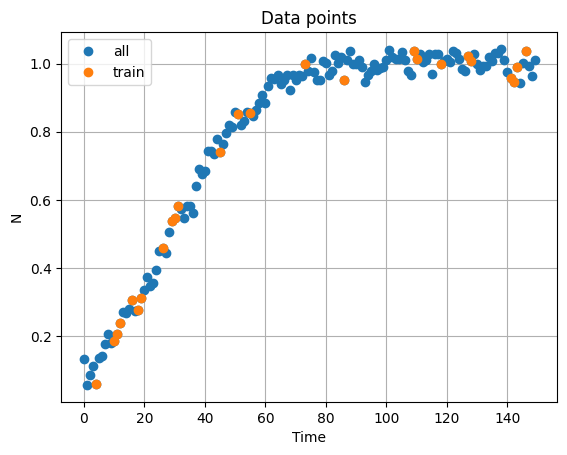

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 5.805e-01, pinn loss: 3.059e-10, data loss: 5.805e-01, r: 0.010, K: 1.000000
It: 100, Loss: 3.045e-01, pinn loss: 3.039e-09, data loss: 3.045e-01, r: -0.000, K: 1.000000
It: 200, Loss: 1.148e-01, pinn loss: 3.748e-09, data loss: 1.148e-01, r: 0.000, K: 1.000000
It: 300, Loss: 1.030e-01, pinn loss: 5.002e-09, data loss: 1.030e-01, r: 0.001, K: 1.000000
It: 400, Loss: 9.259e-02, pinn loss: 8.680e-09, data loss: 9.259e-02, r: 0.003, K: 1.000000
It: 500, Loss: 5.361e-02, pinn loss: 1.856e-08, data loss: 5.361e-02, r: 0.010, K: 1.000000
It: 600, Loss: 1.121e-02, pinn loss: 7.132e-06, data loss: 1.120e-02, r: 0.035, K: 1.000000
It: 700, Loss: 8.127e-03, pinn loss: 1.015e-05, data loss: 8.116e-03, r: 0.040, K: 1.000000
It: 800, Loss: 5.553e-03, pinn loss: 9.343e-06, data loss: 5.543e-03, r: 0.047, K: 1.000000
It: 900, Loss: 3.521e-03, pinn loss: 9.641e-06, data loss: 3.512e-03, r: 0.054, K: 1.000000
estimated alpha:  0.07871092855930

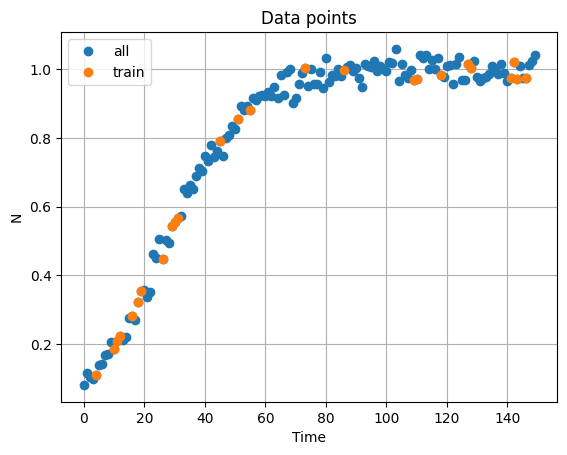

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 6.960e-01, pinn loss: 7.407e-07, data loss: 6.960e-01, r: 0.010, K: 1.000000
It: 100, Loss: 3.663e-01, pinn loss: 6.126e-08, data loss: 3.663e-01, r: 0.002, K: 1.000000
It: 200, Loss: 1.178e-01, pinn loss: 2.544e-08, data loss: 1.178e-01, r: 0.001, K: 1.000000
It: 300, Loss: 8.661e-02, pinn loss: 8.025e-08, data loss: 8.661e-02, r: 0.003, K: 1.000000
It: 400, Loss: 6.757e-02, pinn loss: 2.697e-07, data loss: 6.757e-02, r: 0.007, K: 1.000000
It: 500, Loss: 2.672e-02, pinn loss: 5.958e-07, data loss: 2.672e-02, r: 0.019, K: 1.000000
It: 600, Loss: 6.791e-03, pinn loss: 4.251e-06, data loss: 6.787e-03, r: 0.042, K: 1.000000
It: 700, Loss: 5.073e-03, pinn loss: 7.385e-06, data loss: 5.066e-03, r: 0.049, K: 1.000000
It: 800, Loss: 3.793e-03, pinn loss: 7.814e-06, data loss: 3.785e-03, r: 0.053, K: 1.000000
It: 900, Loss: 2.785e-03, pinn loss: 8.822e-06, data loss: 2.776e-03, r: 0.058, K: 1.000000
Loss: 2.215e-04, pinn loss: 3.280e-

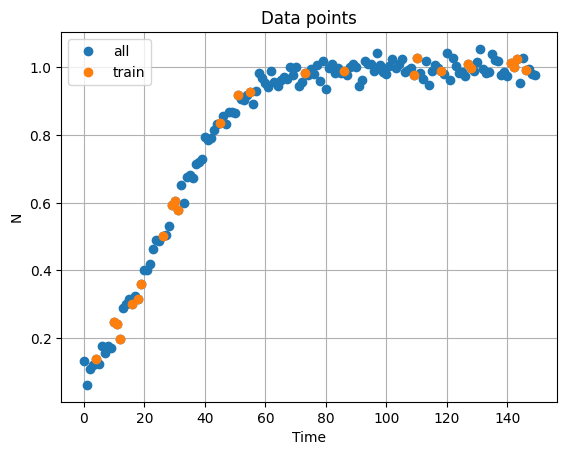

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 4.572e-01, pinn loss: 1.079e-06, data loss: 4.572e-01, r: 0.010, K: 1.000000
It: 100, Loss: 2.085e-01, pinn loss: 1.438e-08, data loss: 2.085e-01, r: 0.001, K: 1.000000
It: 200, Loss: 1.007e-01, pinn loss: 6.236e-09, data loss: 1.007e-01, r: 0.001, K: 1.000000
It: 300, Loss: 9.669e-02, pinn loss: 1.435e-08, data loss: 9.669e-02, r: 0.001, K: 1.000000
It: 400, Loss: 8.892e-02, pinn loss: 5.119e-08, data loss: 8.892e-02, r: 0.002, K: 1.000000
It: 500, Loss: 5.867e-02, pinn loss: 3.961e-07, data loss: 5.867e-02, r: 0.008, K: 1.000000
It: 600, Loss: 1.015e-02, pinn loss: 7.337e-06, data loss: 1.014e-02, r: 0.030, K: 1.000000
It: 700, Loss: 8.054e-03, pinn loss: 1.079e-05, data loss: 8.043e-03, r: 0.040, K: 1.000000
It: 800, Loss: 6.496e-03, pinn loss: 1.066e-05, data loss: 6.485e-03, r: 0.045, K: 1.000000
It: 900, Loss: 5.060e-03, pinn loss: 1.097e-05, data loss: 5.050e-03, r: 0.049, K: 1.000000
estimated alpha:  0.085538908839225

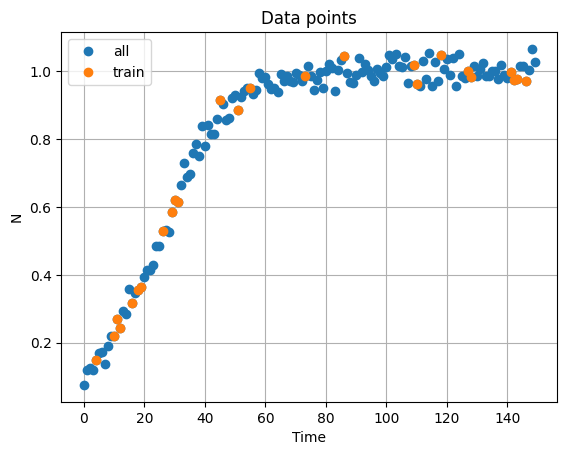

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 3.889e-01, pinn loss: 2.067e-06, data loss: 3.889e-01, r: 0.010, K: 1.000000
It: 100, Loss: 1.940e-01, pinn loss: 3.460e-08, data loss: 1.940e-01, r: 0.001, K: 1.000000
It: 200, Loss: 8.722e-02, pinn loss: 3.925e-08, data loss: 8.722e-02, r: 0.002, K: 1.000000
It: 300, Loss: 5.925e-02, pinn loss: 4.364e-07, data loss: 5.925e-02, r: 0.006, K: 1.000000
It: 400, Loss: 1.160e-02, pinn loss: 6.399e-06, data loss: 1.159e-02, r: 0.023, K: 1.000000
It: 500, Loss: 6.449e-03, pinn loss: 1.075e-05, data loss: 6.438e-03, r: 0.039, K: 1.000000
It: 600, Loss: 4.083e-03, pinn loss: 9.612e-06, data loss: 4.073e-03, r: 0.049, K: 1.000000
It: 700, Loss: 2.663e-03, pinn loss: 9.671e-06, data loss: 2.653e-03, r: 0.058, K: 1.000000
It: 800, Loss: 1.984e-03, pinn loss: 1.044e-05, data loss: 1.974e-03, r: 0.066, K: 1.000000
It: 900, Loss: 1.715e-03, pinn loss: 1.137e-05, data loss: 1.704e-03, r: 0.072, K: 1.000000
Loss: 4.755e-04, pinn loss: 2.443e-

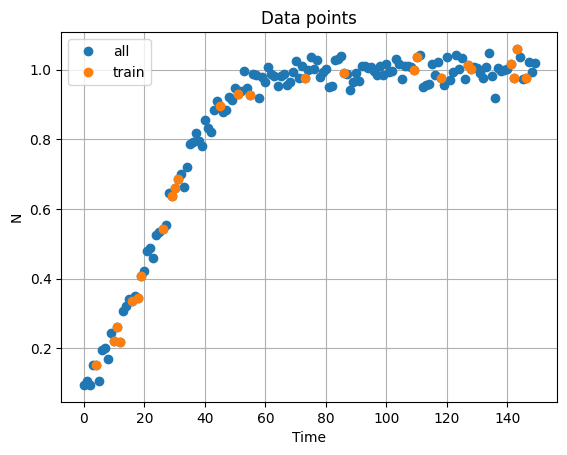

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 4.263e-01, pinn loss: 1.720e-06, data loss: 4.263e-01, r: 0.010, K: 1.000000
It: 100, Loss: 2.608e-01, pinn loss: 6.217e-08, data loss: 2.608e-01, r: 0.001, K: 1.000000
It: 200, Loss: 1.083e-01, pinn loss: 3.225e-09, data loss: 1.083e-01, r: 0.000, K: 1.000000
It: 300, Loss: 9.109e-02, pinn loss: 1.331e-08, data loss: 9.109e-02, r: 0.001, K: 1.000000
It: 400, Loss: 7.341e-02, pinn loss: 1.189e-07, data loss: 7.341e-02, r: 0.004, K: 1.000000
It: 500, Loss: 1.594e-02, pinn loss: 5.255e-06, data loss: 1.593e-02, r: 0.020, K: 1.000000
It: 600, Loss: 9.162e-03, pinn loss: 1.098e-05, data loss: 9.151e-03, r: 0.036, K: 1.000000
It: 700, Loss: 5.289e-03, pinn loss: 9.961e-06, data loss: 5.279e-03, r: 0.046, K: 1.000000
It: 800, Loss: 2.611e-03, pinn loss: 9.986e-06, data loss: 2.601e-03, r: 0.058, K: 1.000000
It: 900, Loss: 1.431e-03, pinn loss: 1.093e-05, data loss: 1.420e-03, r: 0.069, K: 1.000000
Loss: 4.142e-04, pinn loss: 3.897e-

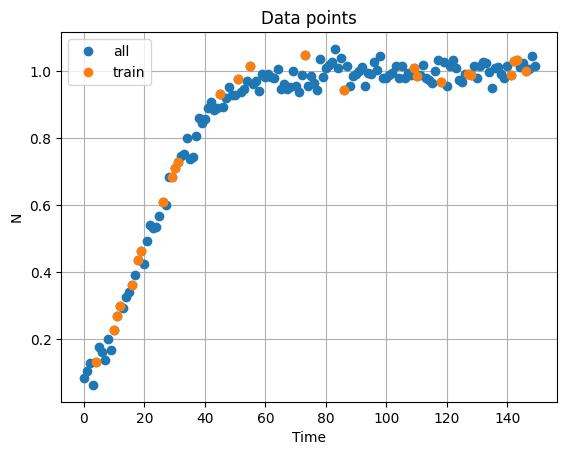

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 5.688e-01, pinn loss: 3.779e-07, data loss: 5.688e-01, r: 0.010, K: 1.000000
It: 100, Loss: 2.883e-01, pinn loss: 7.106e-10, data loss: 2.883e-01, r: 0.000, K: 1.000000
It: 200, Loss: 1.073e-01, pinn loss: 2.844e-09, data loss: 1.073e-01, r: 0.000, K: 1.000000
It: 300, Loss: 8.736e-02, pinn loss: 6.850e-09, data loss: 8.736e-02, r: 0.001, K: 1.000000
It: 400, Loss: 8.261e-02, pinn loss: 2.047e-08, data loss: 8.261e-02, r: 0.002, K: 1.000000
It: 500, Loss: 6.981e-02, pinn loss: 1.003e-07, data loss: 6.981e-02, r: 0.005, K: 1.000000
It: 600, Loss: 2.858e-02, pinn loss: 6.444e-07, data loss: 2.858e-02, r: 0.018, K: 1.000000
It: 700, Loss: 9.777e-03, pinn loss: 1.065e-05, data loss: 9.766e-03, r: 0.043, K: 1.000000
It: 800, Loss: 5.911e-03, pinn loss: 1.302e-05, data loss: 5.898e-03, r: 0.055, K: 1.000000
It: 900, Loss: 3.254e-03, pinn loss: 1.600e-05, data loss: 3.238e-03, r: 0.068, K: 1.000000
Loss: 4.207e-04, pinn loss: 1.361e-

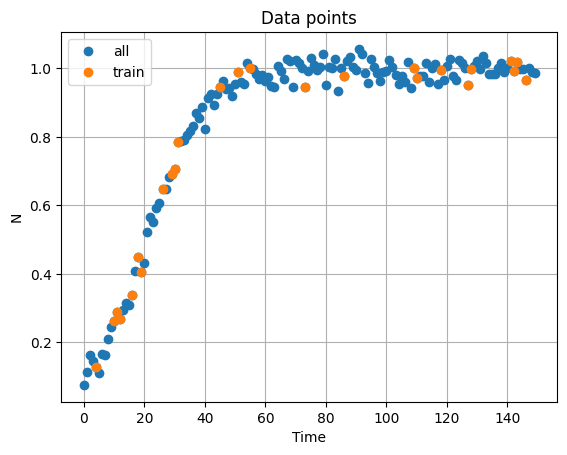

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 6.424e-01, pinn loss: 9.906e-09, data loss: 6.424e-01, r: 0.010, K: 1.000000
It: 100, Loss: 2.731e-01, pinn loss: 5.849e-09, data loss: 2.731e-01, r: -0.000, K: 1.000000
It: 200, Loss: 8.992e-02, pinn loss: 1.067e-08, data loss: 8.992e-02, r: 0.001, K: 1.000000
It: 300, Loss: 8.090e-02, pinn loss: 2.334e-08, data loss: 8.090e-02, r: 0.002, K: 1.000000
It: 400, Loss: 7.017e-02, pinn loss: 6.978e-08, data loss: 7.017e-02, r: 0.004, K: 1.000000
It: 500, Loss: 4.040e-02, pinn loss: 1.985e-07, data loss: 4.040e-02, r: 0.014, K: 1.000000
It: 600, Loss: 1.587e-02, pinn loss: 4.826e-06, data loss: 1.587e-02, r: 0.036, K: 1.000000
It: 700, Loss: 1.293e-02, pinn loss: 9.614e-06, data loss: 1.292e-02, r: 0.042, K: 1.000000
It: 800, Loss: 1.016e-02, pinn loss: 1.031e-05, data loss: 1.015e-02, r: 0.049, K: 1.000000
It: 900, Loss: 7.430e-03, pinn loss: 1.200e-05, data loss: 7.418e-03, r: 0.057, K: 1.000000
Loss: 5.490e-04, pinn loss: 7.911e

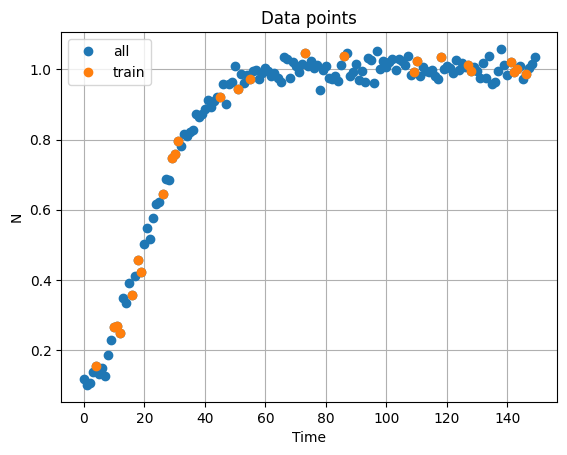

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 5.807e-01, pinn loss: 4.134e-07, data loss: 5.807e-01, r: 0.010, K: 1.000000
It: 100, Loss: 3.403e-01, pinn loss: 1.400e-09, data loss: 3.403e-01, r: 0.000, K: 1.000000
It: 200, Loss: 1.191e-01, pinn loss: 8.228e-09, data loss: 1.191e-01, r: 0.001, K: 1.000000
It: 300, Loss: 7.732e-02, pinn loss: 5.507e-08, data loss: 7.732e-02, r: 0.003, K: 1.000000
It: 400, Loss: 4.762e-02, pinn loss: 3.418e-07, data loss: 4.762e-02, r: 0.011, K: 1.000000
It: 500, Loss: 1.413e-02, pinn loss: 5.582e-06, data loss: 1.412e-02, r: 0.033, K: 1.000000
It: 600, Loss: 9.547e-03, pinn loss: 1.239e-05, data loss: 9.535e-03, r: 0.044, K: 1.000000
It: 700, Loss: 6.106e-03, pinn loss: 1.258e-05, data loss: 6.093e-03, r: 0.054, K: 1.000000
It: 800, Loss: 3.659e-03, pinn loss: 1.301e-05, data loss: 3.646e-03, r: 0.066, K: 1.000000
It: 900, Loss: 2.251e-03, pinn loss: 1.406e-05, data loss: 2.237e-03, r: 0.077, K: 1.000000
Loss: 3.139e-04, pinn loss: 5.589e-

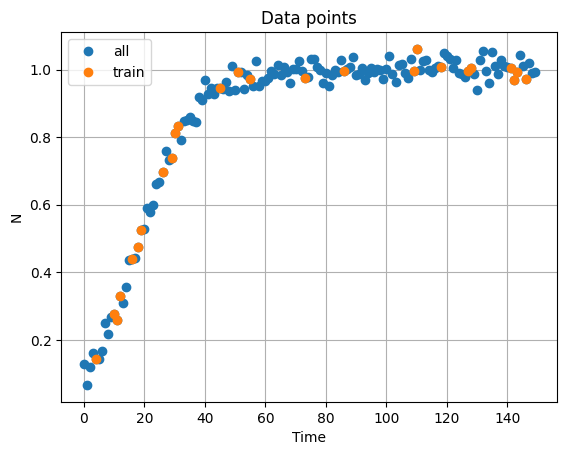

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 7.147e-01, pinn loss: 3.102e-08, data loss: 7.147e-01, r: 0.010, K: 1.000000
It: 100, Loss: 3.919e-01, pinn loss: 2.800e-09, data loss: 3.919e-01, r: -0.000, K: 1.000000
It: 200, Loss: 1.132e-01, pinn loss: 4.135e-09, data loss: 1.132e-01, r: 0.001, K: 1.000000
It: 300, Loss: 7.449e-02, pinn loss: 1.045e-08, data loss: 7.449e-02, r: 0.002, K: 1.000000
It: 400, Loss: 6.816e-02, pinn loss: 2.411e-08, data loss: 6.816e-02, r: 0.004, K: 1.000000
It: 500, Loss: 5.074e-02, pinn loss: 5.119e-08, data loss: 5.074e-02, r: 0.009, K: 1.000000
It: 600, Loss: 2.097e-02, pinn loss: 1.548e-06, data loss: 2.096e-02, r: 0.028, K: 1.000000
It: 700, Loss: 1.525e-02, pinn loss: 9.518e-06, data loss: 1.524e-02, r: 0.037, K: 1.000000
It: 800, Loss: 1.166e-02, pinn loss: 1.003e-05, data loss: 1.165e-02, r: 0.044, K: 1.000000
It: 900, Loss: 8.074e-03, pinn loss: 1.057e-05, data loss: 8.063e-03, r: 0.055, K: 1.000000
estimated alpha:  0.11976666748523

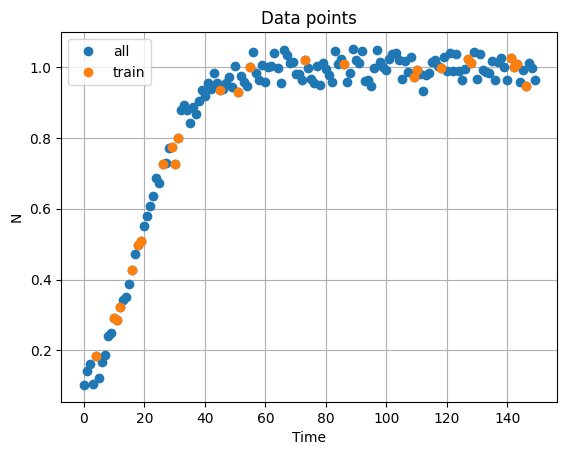

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 4.889e-01, pinn loss: 1.399e-06, data loss: 4.889e-01, r: 0.010, K: 1.000000
It: 100, Loss: 2.365e-01, pinn loss: 2.651e-08, data loss: 2.365e-01, r: 0.001, K: 1.000000
It: 200, Loss: 7.587e-02, pinn loss: 1.485e-08, data loss: 7.587e-02, r: 0.001, K: 1.000000
It: 300, Loss: 6.846e-02, pinn loss: 3.297e-08, data loss: 6.846e-02, r: 0.002, K: 1.000000
It: 400, Loss: 5.784e-02, pinn loss: 1.089e-07, data loss: 5.784e-02, r: 0.005, K: 1.000000
It: 500, Loss: 2.854e-02, pinn loss: 7.152e-07, data loss: 2.854e-02, r: 0.014, K: 1.000000
It: 600, Loss: 1.483e-02, pinn loss: 7.838e-06, data loss: 1.482e-02, r: 0.031, K: 1.000000
It: 700, Loss: 1.225e-02, pinn loss: 7.970e-06, data loss: 1.225e-02, r: 0.036, K: 1.000000
It: 800, Loss: 9.252e-03, pinn loss: 7.755e-06, data loss: 9.245e-03, r: 0.043, K: 1.000000
It: 900, Loss: 6.107e-03, pinn loss: 7.698e-06, data loss: 6.099e-03, r: 0.052, K: 1.000000
Loss: 4.525e-04, pinn loss: 1.987e-

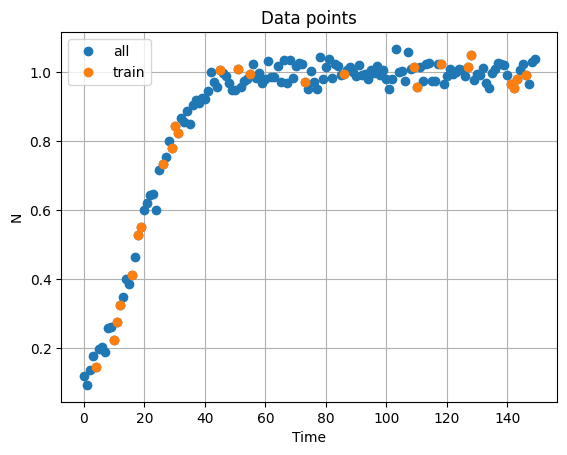

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 5.827e-01, pinn loss: 4.638e-07, data loss: 5.827e-01, r: 0.010, K: 1.000000
It: 100, Loss: 3.518e-01, pinn loss: 1.554e-09, data loss: 3.518e-01, r: 0.001, K: 1.000000
It: 200, Loss: 1.020e-01, pinn loss: 1.662e-08, data loss: 1.020e-01, r: 0.001, K: 1.000000
It: 300, Loss: 7.128e-02, pinn loss: 4.595e-08, data loss: 7.128e-02, r: 0.003, K: 1.000000
It: 400, Loss: 5.778e-02, pinn loss: 1.404e-07, data loss: 5.778e-02, r: 0.007, K: 1.000000
It: 500, Loss: 2.835e-02, pinn loss: 4.441e-07, data loss: 2.835e-02, r: 0.021, K: 1.000000
It: 600, Loss: 1.819e-02, pinn loss: 8.208e-06, data loss: 1.818e-02, r: 0.037, K: 1.000000
It: 700, Loss: 1.394e-02, pinn loss: 1.007e-05, data loss: 1.393e-02, r: 0.044, K: 1.000000
It: 800, Loss: 9.629e-03, pinn loss: 1.151e-05, data loss: 9.617e-03, r: 0.056, K: 1.000000
It: 900, Loss: 5.987e-03, pinn loss: 1.461e-05, data loss: 5.973e-03, r: 0.070, K: 1.000000
estimated alpha:  0.134294688701629

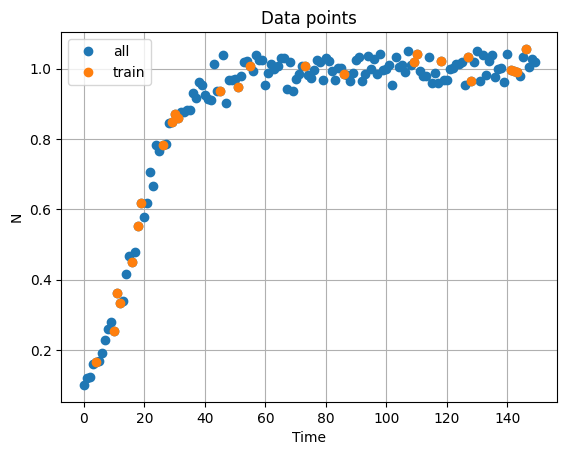

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.185e+00, pinn loss: 1.004e-05, data loss: 1.185e+00, r: 0.010, K: 1.000000
It: 100, Loss: 7.404e-01, pinn loss: 5.331e-08, data loss: 7.404e-01, r: 0.005, K: 1.000000
It: 200, Loss: 1.990e-01, pinn loss: 1.895e-07, data loss: 1.990e-01, r: 0.003, K: 1.000000
It: 300, Loss: 7.167e-02, pinn loss: 2.858e-08, data loss: 7.167e-02, r: 0.002, K: 1.000000
It: 400, Loss: 6.639e-02, pinn loss: 5.308e-08, data loss: 6.639e-02, r: 0.002, K: 1.000000
It: 500, Loss: 6.086e-02, pinn loss: 1.218e-07, data loss: 6.086e-02, r: 0.004, K: 1.000000
It: 600, Loss: 4.828e-02, pinn loss: 4.502e-07, data loss: 4.828e-02, r: 0.007, K: 1.000000
It: 700, Loss: 2.475e-02, pinn loss: 2.430e-06, data loss: 2.475e-02, r: 0.016, K: 1.000000
It: 800, Loss: 1.419e-02, pinn loss: 9.015e-06, data loss: 1.418e-02, r: 0.031, K: 1.000000
It: 900, Loss: 1.151e-02, pinn loss: 1.419e-05, data loss: 1.149e-02, r: 0.041, K: 1.000000
Loss: 5.903e-04, pinn loss: 5.190e-

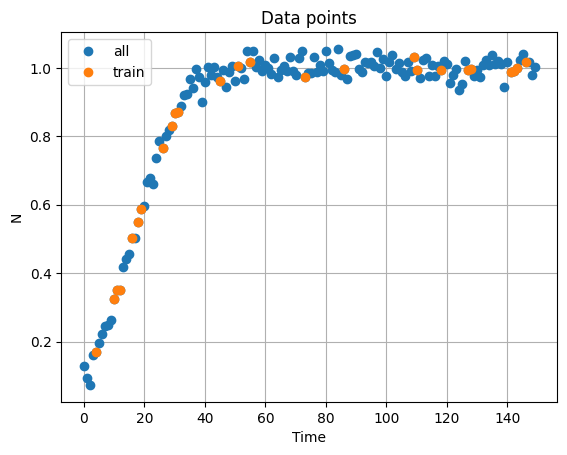

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 6.242e-01, pinn loss: 3.321e-07, data loss: 6.242e-01, r: 0.010, K: 1.000000
It: 100, Loss: 2.719e-01, pinn loss: 1.460e-09, data loss: 2.719e-01, r: 0.000, K: 1.000000
It: 200, Loss: 7.119e-02, pinn loss: 7.922e-09, data loss: 7.119e-02, r: 0.001, K: 1.000000
It: 300, Loss: 6.589e-02, pinn loss: 1.123e-08, data loss: 6.589e-02, r: 0.002, K: 1.000000
It: 400, Loss: 6.289e-02, pinn loss: 1.797e-08, data loss: 6.289e-02, r: 0.003, K: 1.000000
It: 500, Loss: 5.702e-02, pinn loss: 3.110e-08, data loss: 5.702e-02, r: 0.004, K: 1.000000
It: 600, Loss: 4.361e-02, pinn loss: 3.816e-08, data loss: 4.361e-02, r: 0.010, K: 1.000000
It: 700, Loss: 2.451e-02, pinn loss: 1.602e-06, data loss: 2.450e-02, r: 0.022, K: 1.000000
It: 800, Loss: 2.034e-02, pinn loss: 7.406e-06, data loss: 2.033e-02, r: 0.028, K: 1.000000
It: 900, Loss: 1.818e-02, pinn loss: 7.790e-06, data loss: 1.818e-02, r: 0.031, K: 1.000000
estimated alpha:  0.129186779260635

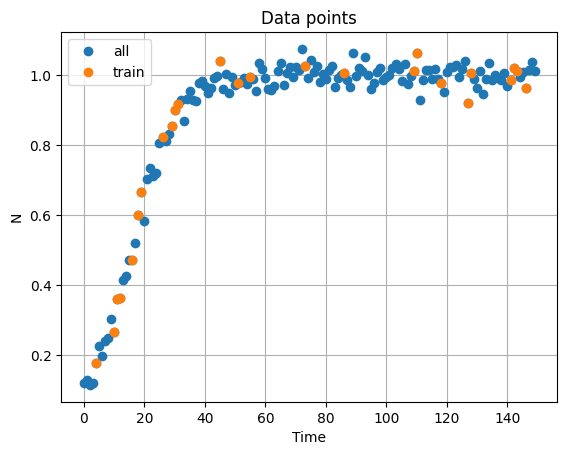

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.381e+00, pinn loss: 1.917e-05, data loss: 1.381e+00, r: 0.010, K: 1.000000
It: 100, Loss: 8.264e-01, pinn loss: 1.995e-07, data loss: 8.264e-01, r: 0.004, K: 1.000000
It: 200, Loss: 1.998e-01, pinn loss: 3.641e-07, data loss: 1.998e-01, r: 0.003, K: 1.000000
It: 300, Loss: 7.134e-02, pinn loss: 3.048e-08, data loss: 7.134e-02, r: 0.002, K: 1.000000
It: 400, Loss: 6.591e-02, pinn loss: 4.326e-08, data loss: 6.591e-02, r: 0.002, K: 1.000000
It: 500, Loss: 6.291e-02, pinn loss: 9.658e-08, data loss: 6.291e-02, r: 0.002, K: 1.000000
It: 600, Loss: 5.737e-02, pinn loss: 2.610e-07, data loss: 5.737e-02, r: 0.004, K: 1.000000
It: 700, Loss: 4.545e-02, pinn loss: 1.040e-06, data loss: 4.545e-02, r: 0.006, K: 1.000000
It: 800, Loss: 2.473e-02, pinn loss: 5.639e-06, data loss: 2.473e-02, r: 0.014, K: 1.000000
It: 900, Loss: 1.600e-02, pinn loss: 1.419e-05, data loss: 1.598e-02, r: 0.027, K: 1.000000
Loss: 8.912e-04, pinn loss: 5.484e-

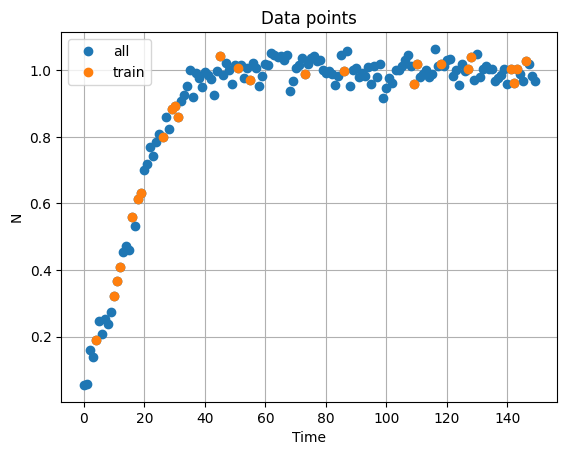

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 6.855e-01, pinn loss: 1.242e-07, data loss: 6.855e-01, r: 0.010, K: 1.000000
It: 100, Loss: 3.739e-01, pinn loss: 6.591e-10, data loss: 3.739e-01, r: -0.000, K: 1.000000
It: 200, Loss: 9.895e-02, pinn loss: 3.285e-09, data loss: 9.895e-02, r: -0.000, K: 1.000000
It: 300, Loss: 6.573e-02, pinn loss: 3.067e-09, data loss: 6.573e-02, r: 0.000, K: 1.000000
It: 400, Loss: 6.325e-02, pinn loss: 3.294e-09, data loss: 6.325e-02, r: 0.001, K: 1.000000
It: 500, Loss: 5.921e-02, pinn loss: 5.857e-09, data loss: 5.921e-02, r: 0.002, K: 1.000000
It: 600, Loss: 4.963e-02, pinn loss: 1.471e-08, data loss: 4.963e-02, r: 0.006, K: 1.000000
It: 700, Loss: 2.858e-02, pinn loss: 3.228e-07, data loss: 2.858e-02, r: 0.018, K: 1.000000
It: 800, Loss: 1.961e-02, pinn loss: 6.358e-06, data loss: 1.960e-02, r: 0.029, K: 1.000000
It: 900, Loss: 1.578e-02, pinn loss: 8.152e-06, data loss: 1.578e-02, r: 0.035, K: 1.000000
Loss: 5.292e-04, pinn loss: 1.370

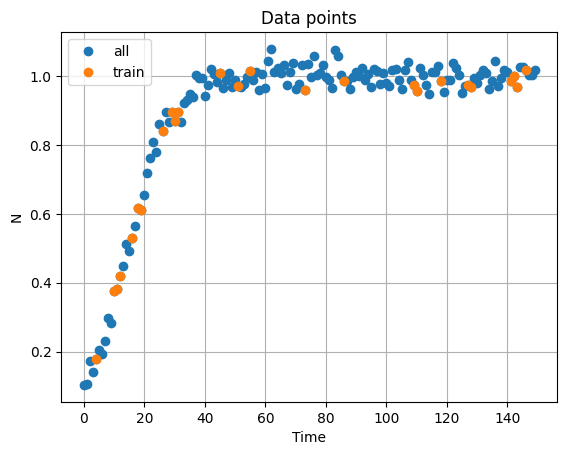

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 8.913e-01, pinn loss: 1.121e-06, data loss: 8.913e-01, r: 0.010, K: 1.000000
It: 100, Loss: 4.764e-01, pinn loss: 2.217e-07, data loss: 4.764e-01, r: 0.003, K: 1.000000
It: 200, Loss: 1.106e-01, pinn loss: 4.733e-09, data loss: 1.106e-01, r: 0.000, K: 1.000000
It: 300, Loss: 5.574e-02, pinn loss: 1.400e-08, data loss: 5.574e-02, r: 0.002, K: 1.000000
It: 400, Loss: 5.129e-02, pinn loss: 3.514e-08, data loss: 5.129e-02, r: 0.004, K: 1.000000
It: 500, Loss: 4.271e-02, pinn loss: 1.041e-07, data loss: 4.271e-02, r: 0.007, K: 1.000000
It: 600, Loss: 2.537e-02, pinn loss: 1.319e-07, data loss: 2.537e-02, r: 0.019, K: 1.000000
It: 700, Loss: 1.590e-02, pinn loss: 2.850e-06, data loss: 1.589e-02, r: 0.036, K: 1.000000
It: 800, Loss: 1.274e-02, pinn loss: 4.842e-06, data loss: 1.274e-02, r: 0.044, K: 1.000000
It: 900, Loss: 9.446e-03, pinn loss: 5.210e-06, data loss: 9.441e-03, r: 0.054, K: 1.000000
Loss: 2.903e-04, pinn loss: 1.073e-

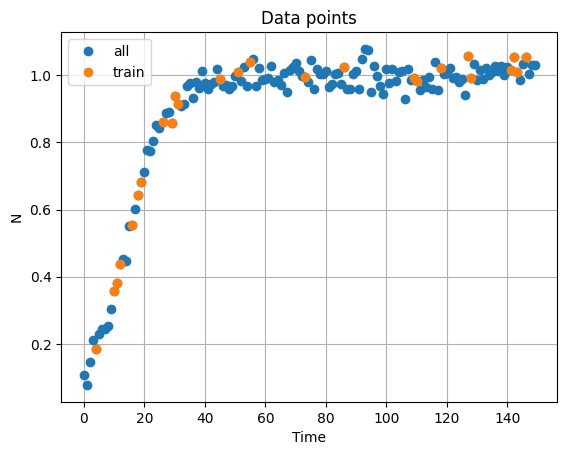

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.477e+00, pinn loss: 2.180e-05, data loss: 1.477e+00, r: 0.010, K: 1.000000
It: 100, Loss: 1.027e+00, pinn loss: 4.708e-07, data loss: 1.027e+00, r: 0.004, K: 1.000000
It: 200, Loss: 3.408e-01, pinn loss: 3.122e-07, data loss: 3.408e-01, r: 0.003, K: 1.000000
It: 300, Loss: 7.317e-02, pinn loss: 3.115e-08, data loss: 7.317e-02, r: 0.002, K: 1.000000
It: 400, Loss: 6.049e-02, pinn loss: 1.851e-08, data loss: 6.049e-02, r: 0.002, K: 1.000000
It: 500, Loss: 5.819e-02, pinn loss: 4.876e-08, data loss: 5.819e-02, r: 0.002, K: 1.000000
It: 600, Loss: 5.412e-02, pinn loss: 1.459e-07, data loss: 5.412e-02, r: 0.003, K: 1.000000
It: 700, Loss: 4.530e-02, pinn loss: 6.036e-07, data loss: 4.530e-02, r: 0.004, K: 1.000000
It: 800, Loss: 2.680e-02, pinn loss: 3.790e-06, data loss: 2.679e-02, r: 0.009, K: 1.000000
It: 900, Loss: 1.369e-02, pinn loss: 1.408e-05, data loss: 1.368e-02, r: 0.020, K: 1.000000
estimated alpha:  0.142779439687728

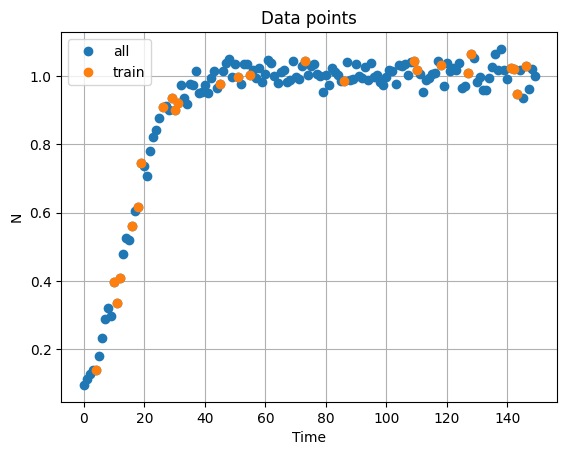

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.007e+00, pinn loss: 2.019e-06, data loss: 1.007e+00, r: 0.010, K: 1.000000
It: 100, Loss: 6.137e-01, pinn loss: 3.107e-07, data loss: 6.137e-01, r: 0.006, K: 1.000000
It: 200, Loss: 1.464e-01, pinn loss: 5.655e-09, data loss: 1.464e-01, r: 0.000, K: 1.000000
It: 300, Loss: 6.787e-02, pinn loss: 6.033e-09, data loss: 6.787e-02, r: 0.000, K: 1.000000
It: 400, Loss: 6.668e-02, pinn loss: 7.095e-09, data loss: 6.668e-02, r: 0.001, K: 1.000000
It: 500, Loss: 6.554e-02, pinn loss: 9.746e-09, data loss: 6.554e-02, r: 0.001, K: 1.000000
It: 600, Loss: 6.356e-02, pinn loss: 1.643e-08, data loss: 6.356e-02, r: 0.002, K: 1.000000
It: 700, Loss: 5.921e-02, pinn loss: 3.807e-08, data loss: 5.921e-02, r: 0.003, K: 1.000000
It: 800, Loss: 4.647e-02, pinn loss: 1.209e-07, data loss: 4.647e-02, r: 0.009, K: 1.000000
It: 900, Loss: 2.384e-02, pinn loss: 1.739e-06, data loss: 2.384e-02, r: 0.027, K: 1.000000
estimated alpha:  0.163942679762840

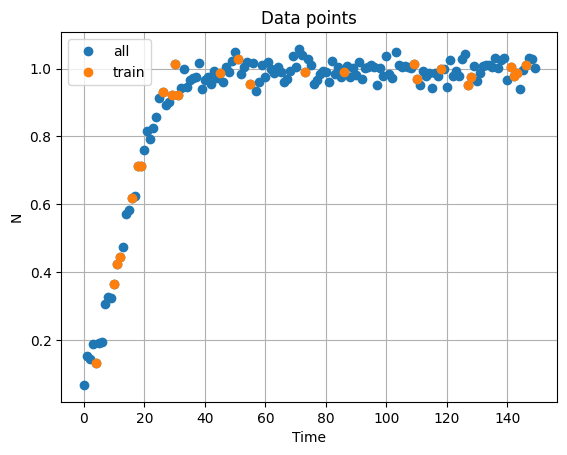

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 5.605e-01, pinn loss: 1.348e-06, data loss: 5.605e-01, r: 0.010, K: 1.000000
It: 100, Loss: 3.168e-01, pinn loss: 4.072e-08, data loss: 3.168e-01, r: 0.001, K: 1.000000
It: 200, Loss: 8.489e-02, pinn loss: 3.435e-09, data loss: 8.489e-02, r: 0.000, K: 1.000000
It: 300, Loss: 5.851e-02, pinn loss: 4.808e-09, data loss: 5.851e-02, r: 0.000, K: 1.000000
It: 400, Loss: 5.734e-02, pinn loss: 7.315e-09, data loss: 5.734e-02, r: 0.001, K: 1.000000
It: 500, Loss: 5.509e-02, pinn loss: 1.573e-08, data loss: 5.509e-02, r: 0.002, K: 1.000000
It: 600, Loss: 4.930e-02, pinn loss: 5.628e-08, data loss: 4.930e-02, r: 0.004, K: 1.000000
It: 700, Loss: 3.396e-02, pinn loss: 3.284e-07, data loss: 3.396e-02, r: 0.012, K: 1.000000
It: 800, Loss: 2.292e-02, pinn loss: 3.621e-06, data loss: 2.292e-02, r: 0.029, K: 1.000000
It: 900, Loss: 1.799e-02, pinn loss: 5.836e-06, data loss: 1.799e-02, r: 0.039, K: 1.000000
estimated alpha:  0.184865593910217

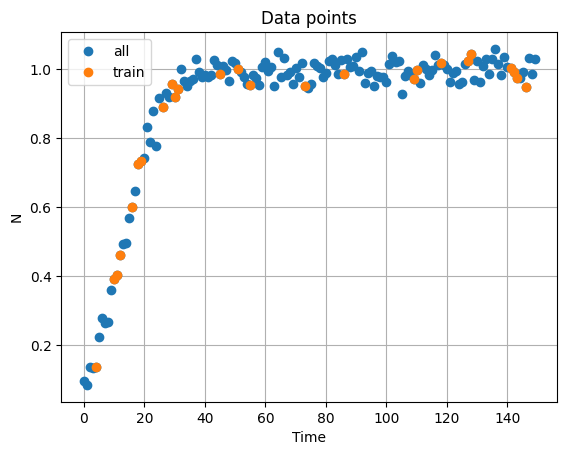

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 8.571e-01, pinn loss: 2.993e-07, data loss: 8.571e-01, r: 0.010, K: 1.000000
It: 100, Loss: 4.749e-01, pinn loss: 1.417e-10, data loss: 4.749e-01, r: 0.000, K: 1.000000
It: 200, Loss: 1.123e-01, pinn loss: 4.873e-09, data loss: 1.123e-01, r: 0.001, K: 1.000000
It: 300, Loss: 5.408e-02, pinn loss: 1.122e-08, data loss: 5.408e-02, r: 0.002, K: 1.000000
It: 400, Loss: 5.220e-02, pinn loss: 1.802e-08, data loss: 5.220e-02, r: 0.003, K: 1.000000
It: 500, Loss: 4.934e-02, pinn loss: 3.179e-08, data loss: 4.934e-02, r: 0.004, K: 1.000000
It: 600, Loss: 4.392e-02, pinn loss: 5.554e-08, data loss: 4.392e-02, r: 0.007, K: 1.000000
It: 700, Loss: 3.293e-02, pinn loss: 2.130e-08, data loss: 3.293e-02, r: 0.015, K: 1.000000
It: 800, Loss: 2.221e-02, pinn loss: 1.740e-06, data loss: 2.221e-02, r: 0.029, K: 1.000000
It: 900, Loss: 1.912e-02, pinn loss: 5.094e-06, data loss: 1.912e-02, r: 0.035, K: 1.000000
Loss: 5.312e-04, pinn loss: 1.305e-

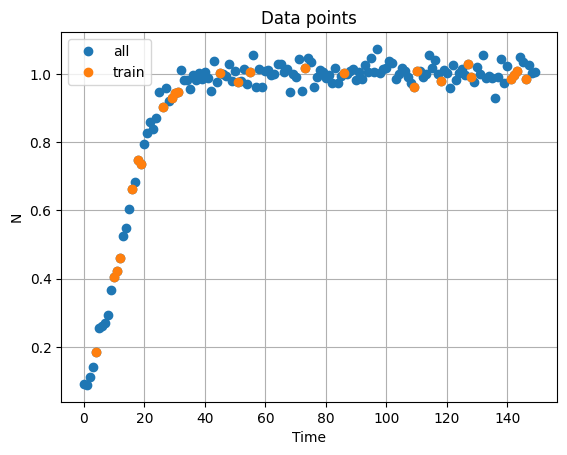

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.281e+00, pinn loss: 1.019e-05, data loss: 1.281e+00, r: 0.010, K: 1.000000
It: 100, Loss: 8.620e-01, pinn loss: 6.764e-08, data loss: 8.620e-01, r: 0.005, K: 1.000000
It: 200, Loss: 2.839e-01, pinn loss: 3.362e-07, data loss: 2.839e-01, r: 0.003, K: 1.000000
It: 300, Loss: 5.901e-02, pinn loss: 1.635e-08, data loss: 5.901e-02, r: 0.001, K: 1.000000
It: 400, Loss: 5.067e-02, pinn loss: 2.361e-08, data loss: 5.067e-02, r: 0.001, K: 1.000000
It: 500, Loss: 4.956e-02, pinn loss: 3.331e-08, data loss: 4.956e-02, r: 0.002, K: 1.000000
It: 600, Loss: 4.775e-02, pinn loss: 5.631e-08, data loss: 4.775e-02, r: 0.002, K: 1.000000
It: 700, Loss: 4.430e-02, pinn loss: 1.233e-07, data loss: 4.430e-02, r: 0.004, K: 1.000000
It: 800, Loss: 3.694e-02, pinn loss: 3.820e-07, data loss: 3.694e-02, r: 0.007, K: 1.000000
It: 900, Loss: 2.444e-02, pinn loss: 1.433e-06, data loss: 2.444e-02, r: 0.014, K: 1.000000
Loss: 2.435e-04, pinn loss: 7.509e-

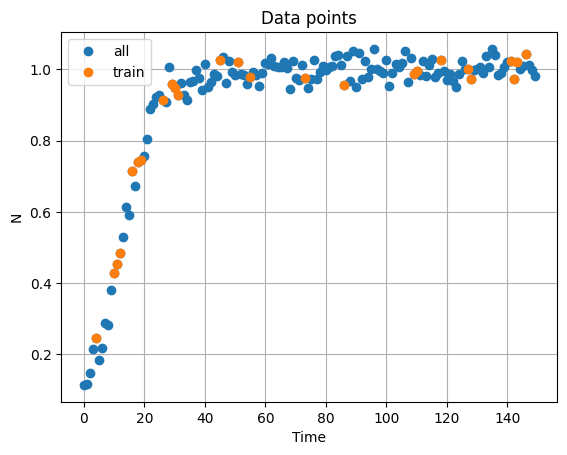

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 9.421e-01, pinn loss: 8.465e-07, data loss: 9.421e-01, r: 0.010, K: 1.000000
It: 100, Loss: 5.526e-01, pinn loss: 1.349e-07, data loss: 5.526e-01, r: 0.003, K: 1.000000
It: 200, Loss: 1.268e-01, pinn loss: 4.110e-08, data loss: 1.268e-01, r: 0.001, K: 1.000000
It: 300, Loss: 4.135e-02, pinn loss: 7.067e-08, data loss: 4.135e-02, r: 0.004, K: 1.000000
It: 400, Loss: 3.747e-02, pinn loss: 1.022e-07, data loss: 3.747e-02, r: 0.007, K: 1.000000
It: 500, Loss: 3.167e-02, pinn loss: 1.377e-07, data loss: 3.167e-02, r: 0.012, K: 1.000000
It: 600, Loss: 2.295e-02, pinn loss: 5.262e-08, data loss: 2.295e-02, r: 0.021, K: 1.000000
It: 700, Loss: 1.620e-02, pinn loss: 1.612e-06, data loss: 1.619e-02, r: 0.033, K: 1.000000
It: 800, Loss: 1.404e-02, pinn loss: 5.458e-06, data loss: 1.403e-02, r: 0.039, K: 1.000000
It: 900, Loss: 1.217e-02, pinn loss: 6.796e-06, data loss: 1.216e-02, r: 0.044, K: 1.000000
Loss: 5.522e-04, pinn loss: 6.280e-

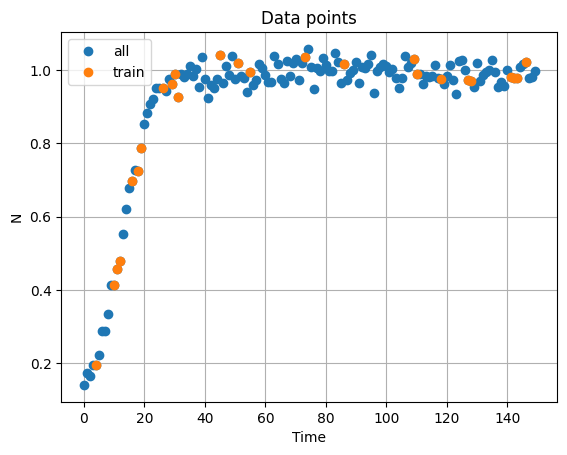

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 5.119e-01, pinn loss: 2.229e-06, data loss: 5.119e-01, r: 0.010, K: 1.000000
It: 100, Loss: 2.212e-01, pinn loss: 5.181e-08, data loss: 2.212e-01, r: 0.001, K: 1.000000
It: 200, Loss: 5.136e-02, pinn loss: 3.309e-08, data loss: 5.136e-02, r: 0.001, K: 1.000000
It: 300, Loss: 4.545e-02, pinn loss: 6.358e-08, data loss: 4.545e-02, r: 0.003, K: 1.000000
It: 400, Loss: 4.087e-02, pinn loss: 1.201e-07, data loss: 4.087e-02, r: 0.005, K: 1.000000
It: 500, Loss: 3.239e-02, pinn loss: 3.993e-07, data loss: 3.239e-02, r: 0.011, K: 1.000000
It: 600, Loss: 2.439e-02, pinn loss: 2.473e-06, data loss: 2.438e-02, r: 0.021, K: 1.000000
It: 700, Loss: 2.168e-02, pinn loss: 4.676e-06, data loss: 2.168e-02, r: 0.028, K: 1.000000
It: 800, Loss: 1.853e-02, pinn loss: 5.350e-06, data loss: 1.853e-02, r: 0.033, K: 1.000000
It: 900, Loss: 1.452e-02, pinn loss: 6.672e-06, data loss: 1.451e-02, r: 0.042, K: 1.000000
estimated alpha:  0.177141860127449

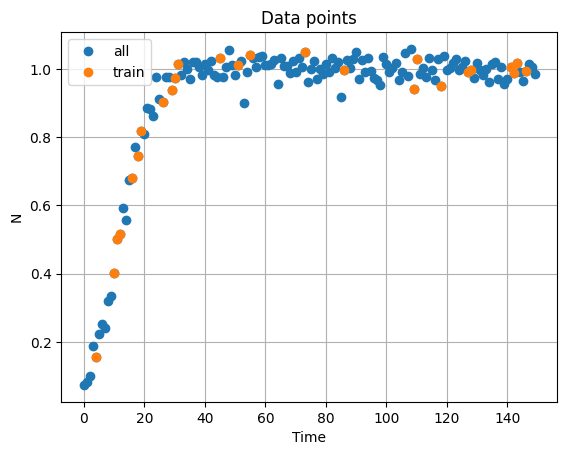

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 6.390e-01, pinn loss: 8.278e-07, data loss: 6.390e-01, r: 0.010, K: 1.000000
It: 100, Loss: 3.342e-01, pinn loss: 2.113e-08, data loss: 3.342e-01, r: 0.000, K: 1.000000
It: 200, Loss: 8.512e-02, pinn loss: 1.550e-08, data loss: 8.512e-02, r: -0.000, K: 1.000000
It: 300, Loss: 5.144e-02, pinn loss: 2.530e-08, data loss: 5.144e-02, r: 0.000, K: 1.000000
It: 400, Loss: 4.713e-02, pinn loss: 4.019e-08, data loss: 4.713e-02, r: 0.003, K: 1.000000
It: 500, Loss: 3.996e-02, pinn loss: 8.791e-08, data loss: 3.996e-02, r: 0.007, K: 1.000000
It: 600, Loss: 2.936e-02, pinn loss: 5.993e-07, data loss: 2.936e-02, r: 0.017, K: 1.000000
It: 700, Loss: 2.464e-02, pinn loss: 4.046e-06, data loss: 2.464e-02, r: 0.026, K: 1.000000
It: 800, Loss: 2.188e-02, pinn loss: 5.769e-06, data loss: 2.188e-02, r: 0.030, K: 1.000000
It: 900, Loss: 1.815e-02, pinn loss: 7.068e-06, data loss: 1.814e-02, r: 0.037, K: 1.000000
Loss: 5.753e-04, pinn loss: 1.412e

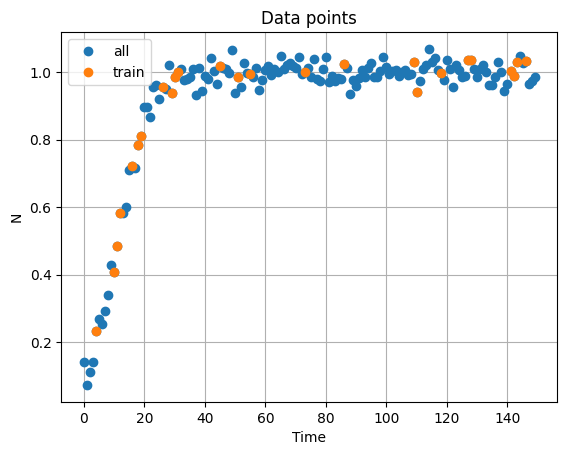

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 6.415e-01, pinn loss: 9.764e-07, data loss: 6.415e-01, r: 0.010, K: 1.000000
It: 100, Loss: 3.319e-01, pinn loss: 1.410e-08, data loss: 3.319e-01, r: 0.001, K: 1.000000
It: 200, Loss: 7.038e-02, pinn loss: 6.319e-09, data loss: 7.038e-02, r: 0.000, K: 1.000000
It: 300, Loss: 4.575e-02, pinn loss: 9.857e-09, data loss: 4.575e-02, r: 0.001, K: 1.000000
It: 400, Loss: 4.435e-02, pinn loss: 1.490e-08, data loss: 4.435e-02, r: 0.002, K: 1.000000
It: 500, Loss: 4.166e-02, pinn loss: 3.064e-08, data loss: 4.166e-02, r: 0.003, K: 1.000000
It: 600, Loss: 3.534e-02, pinn loss: 8.837e-08, data loss: 3.534e-02, r: 0.007, K: 1.000000
It: 700, Loss: 2.427e-02, pinn loss: 7.170e-07, data loss: 2.427e-02, r: 0.017, K: 1.000000
It: 800, Loss: 1.997e-02, pinn loss: 4.669e-06, data loss: 1.996e-02, r: 0.026, K: 1.000000
It: 900, Loss: 1.762e-02, pinn loss: 6.085e-06, data loss: 1.761e-02, r: 0.030, K: 1.000000
estimated alpha:  0.179969921708107

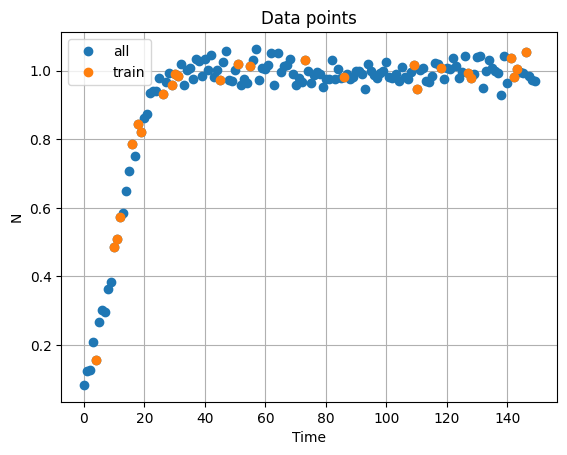

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 8.877e-01, pinn loss: 1.058e-07, data loss: 8.877e-01, r: 0.010, K: 1.000000
It: 100, Loss: 4.559e-01, pinn loss: 9.598e-09, data loss: 4.559e-01, r: -0.000, K: 1.000000
It: 200, Loss: 7.320e-02, pinn loss: 2.360e-08, data loss: 7.320e-02, r: 0.001, K: 1.000000
It: 300, Loss: 4.383e-02, pinn loss: 2.744e-08, data loss: 4.383e-02, r: 0.002, K: 1.000000
It: 400, Loss: 4.172e-02, pinn loss: 3.492e-08, data loss: 4.172e-02, r: 0.004, K: 1.000000
It: 500, Loss: 3.846e-02, pinn loss: 4.421e-08, data loss: 3.846e-02, r: 0.006, K: 1.000000
It: 600, Loss: 3.303e-02, pinn loss: 2.809e-08, data loss: 3.303e-02, r: 0.012, K: 1.000000
It: 700, Loss: 2.574e-02, pinn loss: 1.615e-07, data loss: 2.574e-02, r: 0.021, K: 1.000000
It: 800, Loss: 2.188e-02, pinn loss: 2.645e-06, data loss: 2.188e-02, r: 0.028, K: 1.000000
It: 900, Loss: 2.065e-02, pinn loss: 4.869e-06, data loss: 2.065e-02, r: 0.030, K: 1.000000
estimated alpha:  0.22905488312244

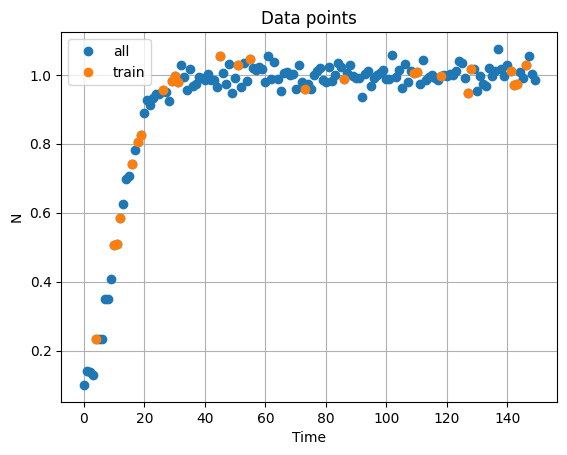

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 2.803e-01, pinn loss: 5.655e-06, data loss: 2.803e-01, r: 0.010, K: 1.000000
It: 100, Loss: 1.104e-01, pinn loss: 2.346e-07, data loss: 1.104e-01, r: 0.002, K: 1.000000
It: 200, Loss: 4.192e-02, pinn loss: 3.756e-09, data loss: 4.192e-02, r: 0.001, K: 1.000000
It: 300, Loss: 3.822e-02, pinn loss: 6.448e-08, data loss: 3.822e-02, r: 0.001, K: 1.000000
It: 400, Loss: 3.209e-02, pinn loss: 4.510e-07, data loss: 3.209e-02, r: 0.004, K: 1.000000
It: 500, Loss: 2.413e-02, pinn loss: 2.899e-06, data loss: 2.413e-02, r: 0.010, K: 1.000000
It: 600, Loss: 2.170e-02, pinn loss: 4.191e-06, data loss: 2.169e-02, r: 0.017, K: 1.000000
It: 700, Loss: 1.825e-02, pinn loss: 4.829e-06, data loss: 1.824e-02, r: 0.023, K: 1.000000
It: 800, Loss: 1.279e-02, pinn loss: 7.577e-06, data loss: 1.278e-02, r: 0.032, K: 1.000000
It: 900, Loss: 6.608e-03, pinn loss: 1.453e-05, data loss: 6.594e-03, r: 0.047, K: 1.000000
Loss: 4.231e-04, pinn loss: 1.094e-

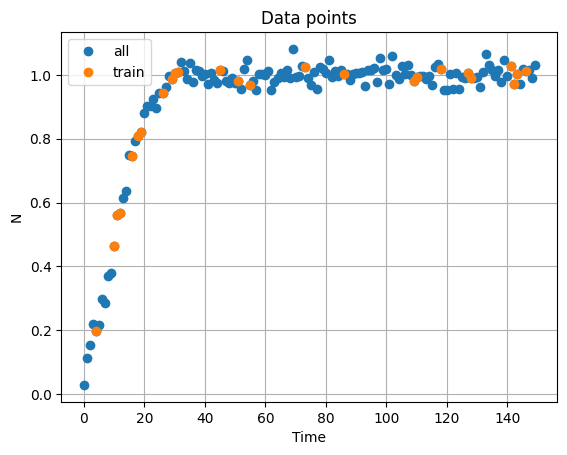

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 6.394e-01, pinn loss: 9.258e-07, data loss: 6.394e-01, r: 0.010, K: 1.000000
It: 100, Loss: 2.817e-01, pinn loss: 8.314e-09, data loss: 2.817e-01, r: 0.001, K: 1.000000
It: 200, Loss: 5.238e-02, pinn loss: 2.101e-09, data loss: 5.238e-02, r: 0.001, K: 1.000000
It: 300, Loss: 4.161e-02, pinn loss: 8.163e-09, data loss: 4.161e-02, r: 0.001, K: 1.000000
It: 400, Loss: 3.945e-02, pinn loss: 1.283e-08, data loss: 3.945e-02, r: 0.003, K: 1.000000
It: 500, Loss: 3.594e-02, pinn loss: 3.064e-08, data loss: 3.594e-02, r: 0.006, K: 1.000000
It: 600, Loss: 3.023e-02, pinn loss: 1.537e-07, data loss: 3.023e-02, r: 0.010, K: 1.000000
It: 700, Loss: 2.490e-02, pinn loss: 1.292e-06, data loss: 2.490e-02, r: 0.018, K: 1.000000
It: 800, Loss: 2.315e-02, pinn loss: 3.282e-06, data loss: 2.314e-02, r: 0.022, K: 1.000000
It: 900, Loss: 2.180e-02, pinn loss: 3.796e-06, data loss: 2.180e-02, r: 0.024, K: 1.000000
Loss: 3.241e-04, pinn loss: 8.783e-

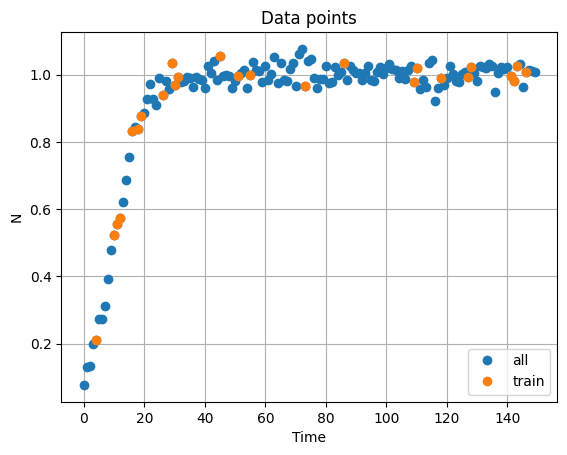

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 4.335e-01, pinn loss: 3.943e-06, data loss: 4.335e-01, r: 0.010, K: 1.000000
It: 100, Loss: 2.056e-01, pinn loss: 1.292e-07, data loss: 2.056e-01, r: 0.002, K: 1.000000
It: 200, Loss: 4.473e-02, pinn loss: 3.636e-08, data loss: 4.473e-02, r: 0.001, K: 1.000000
It: 300, Loss: 3.504e-02, pinn loss: 1.426e-07, data loss: 3.504e-02, r: 0.003, K: 1.000000
It: 400, Loss: 3.093e-02, pinn loss: 3.359e-07, data loss: 3.093e-02, r: 0.005, K: 1.000000
It: 500, Loss: 2.514e-02, pinn loss: 9.807e-07, data loss: 2.514e-02, r: 0.010, K: 1.000000
It: 600, Loss: 2.129e-02, pinn loss: 2.867e-06, data loss: 2.129e-02, r: 0.018, K: 1.000000
It: 700, Loss: 1.952e-02, pinn loss: 4.262e-06, data loss: 1.951e-02, r: 0.024, K: 1.000000
It: 800, Loss: 1.730e-02, pinn loss: 5.087e-06, data loss: 1.729e-02, r: 0.030, K: 1.000000
It: 900, Loss: 1.436e-02, pinn loss: 6.664e-06, data loss: 1.435e-02, r: 0.037, K: 1.000000
Loss: 5.953e-04, pinn loss: 1.466e-

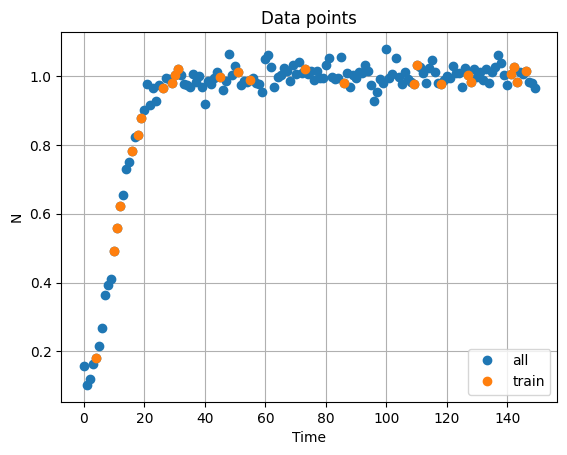

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.260e+00, pinn loss: 6.476e-06, data loss: 1.260e+00, r: 0.010, K: 1.000000
It: 100, Loss: 7.401e-01, pinn loss: 1.038e-07, data loss: 7.401e-01, r: 0.006, K: 1.000000
It: 200, Loss: 1.964e-01, pinn loss: 2.779e-08, data loss: 1.964e-01, r: 0.001, K: 1.000000
It: 300, Loss: 4.643e-02, pinn loss: 4.724e-09, data loss: 4.643e-02, r: 0.000, K: 1.000000
It: 400, Loss: 4.176e-02, pinn loss: 5.540e-09, data loss: 4.176e-02, r: 0.001, K: 1.000000
It: 500, Loss: 4.140e-02, pinn loss: 6.497e-09, data loss: 4.140e-02, r: 0.001, K: 1.000000
It: 600, Loss: 4.092e-02, pinn loss: 8.482e-09, data loss: 4.092e-02, r: 0.001, K: 1.000000
It: 700, Loss: 4.020e-02, pinn loss: 1.254e-08, data loss: 4.020e-02, r: 0.002, K: 1.000000
It: 800, Loss: 3.898e-02, pinn loss: 2.159e-08, data loss: 3.898e-02, r: 0.003, K: 1.000000
It: 900, Loss: 3.673e-02, pinn loss: 4.607e-08, data loss: 3.673e-02, r: 0.004, K: 1.000000
estimated alpha:  0.234943196177482

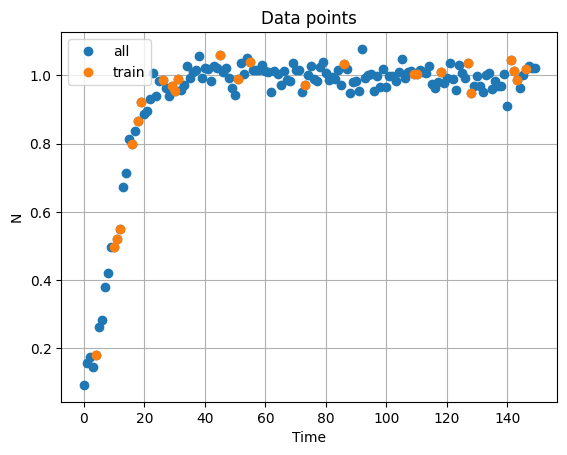

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.198e+00, pinn loss: 4.325e-06, data loss: 1.198e+00, r: 0.010, K: 1.000000
It: 100, Loss: 7.367e-01, pinn loss: 1.189e-07, data loss: 7.367e-01, r: 0.006, K: 1.000000
It: 200, Loss: 2.222e-01, pinn loss: 3.060e-09, data loss: 2.222e-01, r: 0.000, K: 1.000000
It: 300, Loss: 5.050e-02, pinn loss: 4.606e-09, data loss: 5.050e-02, r: 0.001, K: 1.000000
It: 400, Loss: 4.474e-02, pinn loss: 5.940e-09, data loss: 4.474e-02, r: 0.001, K: 1.000000
It: 500, Loss: 4.421e-02, pinn loss: 6.733e-09, data loss: 4.421e-02, r: 0.002, K: 1.000000
It: 600, Loss: 4.356e-02, pinn loss: 8.728e-09, data loss: 4.356e-02, r: 0.002, K: 1.000000
It: 700, Loss: 4.263e-02, pinn loss: 1.266e-08, data loss: 4.263e-02, r: 0.003, K: 1.000000
It: 800, Loss: 4.120e-02, pinn loss: 2.042e-08, data loss: 4.120e-02, r: 0.004, K: 1.000000
It: 900, Loss: 3.874e-02, pinn loss: 3.720e-08, data loss: 3.874e-02, r: 0.006, K: 1.000000
Loss: 6.965e-04, pinn loss: 6.920e-

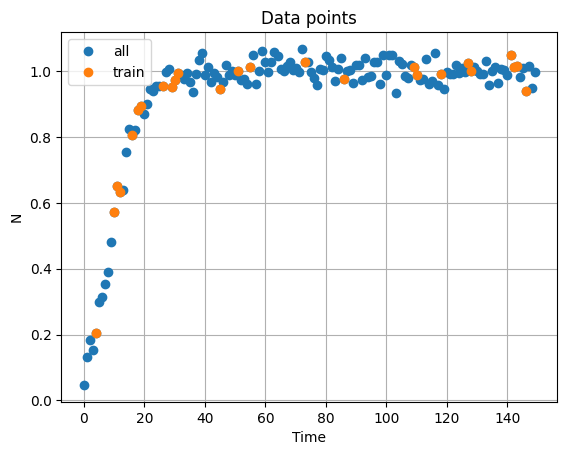

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.171e+00, pinn loss: 3.759e-06, data loss: 1.171e+00, r: 0.010, K: 1.000000
It: 100, Loss: 7.038e-01, pinn loss: 1.626e-07, data loss: 7.038e-01, r: 0.006, K: 1.000000
It: 200, Loss: 1.970e-01, pinn loss: 1.342e-08, data loss: 1.970e-01, r: 0.001, K: 1.000000
It: 300, Loss: 3.783e-02, pinn loss: 2.712e-08, data loss: 3.783e-02, r: 0.002, K: 1.000000
It: 400, Loss: 3.186e-02, pinn loss: 3.961e-08, data loss: 3.186e-02, r: 0.003, K: 1.000000
It: 500, Loss: 3.044e-02, pinn loss: 5.521e-08, data loss: 3.044e-02, r: 0.005, K: 1.000000
It: 600, Loss: 2.824e-02, pinn loss: 9.247e-08, data loss: 2.824e-02, r: 0.007, K: 1.000000
It: 700, Loss: 2.451e-02, pinn loss: 1.742e-07, data loss: 2.451e-02, r: 0.011, K: 1.000000
It: 800, Loss: 1.897e-02, pinn loss: 3.779e-07, data loss: 1.897e-02, r: 0.019, K: 1.000000
It: 900, Loss: 1.497e-02, pinn loss: 1.965e-06, data loss: 1.497e-02, r: 0.032, K: 1.000000
Loss: 6.186e-04, pinn loss: 9.471e-

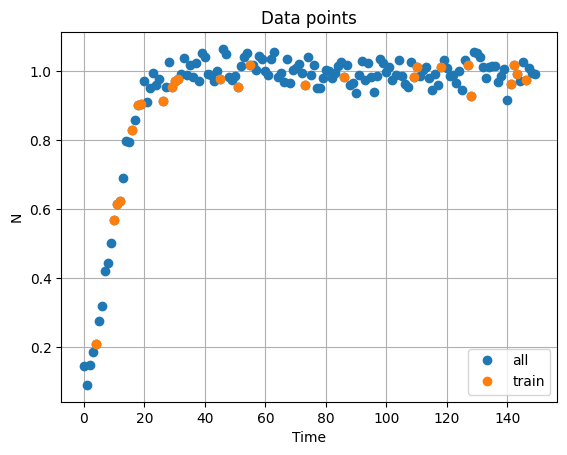

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 8.157e-01, pinn loss: 5.728e-09, data loss: 8.157e-01, r: 0.010, K: 1.000000
It: 100, Loss: 5.378e-01, pinn loss: 1.647e-09, data loss: 5.378e-01, r: -0.000, K: 1.000000
It: 200, Loss: 2.084e-01, pinn loss: 2.094e-09, data loss: 2.084e-01, r: 0.000, K: 1.000000
It: 300, Loss: 3.726e-02, pinn loss: 7.128e-09, data loss: 3.726e-02, r: 0.001, K: 1.000000
It: 400, Loss: 3.223e-02, pinn loss: 1.058e-08, data loss: 3.223e-02, r: 0.002, K: 1.000000
It: 500, Loss: 3.113e-02, pinn loss: 1.746e-08, data loss: 3.113e-02, r: 0.003, K: 1.000000
It: 600, Loss: 2.925e-02, pinn loss: 3.080e-08, data loss: 2.925e-02, r: 0.006, K: 1.000000
It: 700, Loss: 2.562e-02, pinn loss: 4.238e-08, data loss: 2.562e-02, r: 0.010, K: 1.000000
It: 800, Loss: 2.011e-02, pinn loss: 1.893e-08, data loss: 2.011e-02, r: 0.020, K: 1.000000
It: 900, Loss: 1.684e-02, pinn loss: 1.087e-06, data loss: 1.684e-02, r: 0.031, K: 1.000000
Loss: 6.033e-04, pinn loss: 1.744e

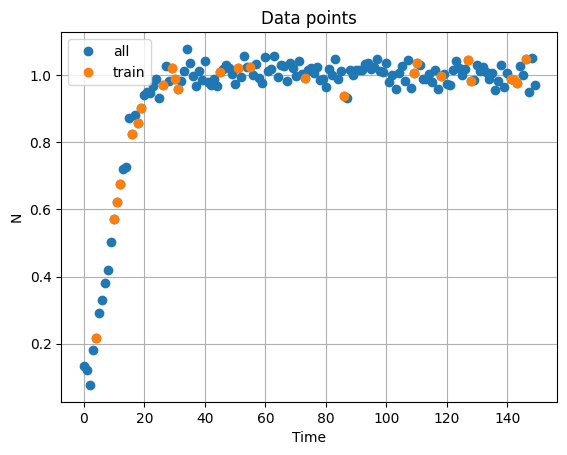

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.300e+00, pinn loss: 7.074e-06, data loss: 1.300e+00, r: 0.010, K: 1.000000
It: 100, Loss: 8.130e-01, pinn loss: 7.359e-09, data loss: 8.130e-01, r: 0.005, K: 1.000000
It: 200, Loss: 1.873e-01, pinn loss: 6.390e-08, data loss: 1.873e-01, r: 0.002, K: 1.000000
It: 300, Loss: 3.410e-02, pinn loss: 2.993e-08, data loss: 3.410e-02, r: 0.001, K: 1.000000
It: 400, Loss: 3.236e-02, pinn loss: 4.375e-08, data loss: 3.236e-02, r: 0.002, K: 1.000000
It: 500, Loss: 3.116e-02, pinn loss: 6.052e-08, data loss: 3.116e-02, r: 0.003, K: 1.000000
It: 600, Loss: 2.937e-02, pinn loss: 9.680e-08, data loss: 2.937e-02, r: 0.005, K: 1.000000
It: 700, Loss: 2.658e-02, pinn loss: 1.834e-07, data loss: 2.658e-02, r: 0.008, K: 1.000000
It: 800, Loss: 2.250e-02, pinn loss: 4.165e-07, data loss: 2.250e-02, r: 0.012, K: 1.000000
It: 900, Loss: 1.873e-02, pinn loss: 1.209e-06, data loss: 1.873e-02, r: 0.020, K: 1.000000
estimated alpha:  0.238257214426994

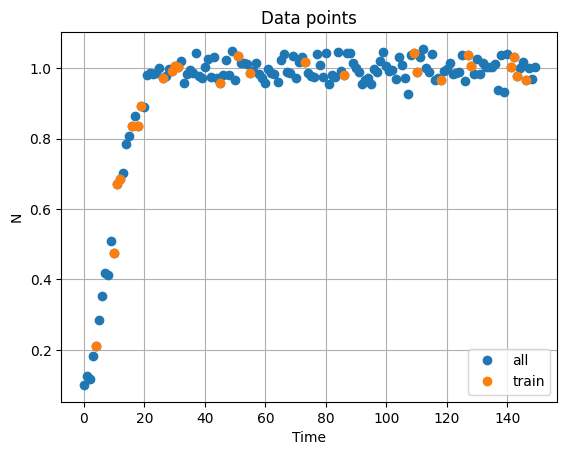

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 9.920e-01, pinn loss: 6.501e-07, data loss: 9.920e-01, r: 0.010, K: 1.000000
It: 100, Loss: 5.718e-01, pinn loss: 5.822e-08, data loss: 5.718e-01, r: 0.002, K: 1.000000
It: 200, Loss: 1.359e-01, pinn loss: 5.326e-09, data loss: 1.359e-01, r: 0.001, K: 1.000000
It: 300, Loss: 3.581e-02, pinn loss: 1.094e-08, data loss: 3.581e-02, r: 0.002, K: 1.000000
It: 400, Loss: 3.356e-02, pinn loss: 1.355e-08, data loss: 3.356e-02, r: 0.004, K: 1.000000
It: 500, Loss: 3.185e-02, pinn loss: 1.966e-08, data loss: 3.185e-02, r: 0.006, K: 1.000000
It: 600, Loss: 2.925e-02, pinn loss: 2.352e-08, data loss: 2.925e-02, r: 0.010, K: 1.000000
It: 700, Loss: 2.522e-02, pinn loss: 1.331e-08, data loss: 2.522e-02, r: 0.016, K: 1.000000
It: 800, Loss: 2.061e-02, pinn loss: 4.388e-07, data loss: 2.061e-02, r: 0.026, K: 1.000000
It: 900, Loss: 1.818e-02, pinn loss: 2.840e-06, data loss: 1.817e-02, r: 0.032, K: 1.000000
Loss: 9.387e-04, pinn loss: 1.474e-

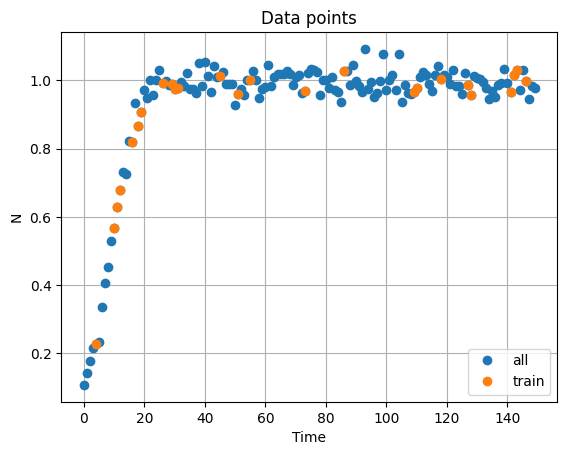

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 9.259e-01, pinn loss: 2.229e-07, data loss: 9.259e-01, r: 0.010, K: 1.000000
It: 100, Loss: 5.411e-01, pinn loss: 1.594e-09, data loss: 5.411e-01, r: 0.000, K: 1.000000
It: 200, Loss: 1.322e-01, pinn loss: 6.772e-09, data loss: 1.322e-01, r: 0.001, K: 1.000000
It: 300, Loss: 3.197e-02, pinn loss: 9.789e-09, data loss: 3.197e-02, r: 0.002, K: 1.000000
It: 400, Loss: 3.083e-02, pinn loss: 1.211e-08, data loss: 3.083e-02, r: 0.003, K: 1.000000
It: 500, Loss: 2.997e-02, pinn loss: 1.733e-08, data loss: 2.997e-02, r: 0.004, K: 1.000000
It: 600, Loss: 2.869e-02, pinn loss: 2.542e-08, data loss: 2.869e-02, r: 0.006, K: 1.000000
It: 700, Loss: 2.670e-02, pinn loss: 3.380e-08, data loss: 2.670e-02, r: 0.008, K: 1.000000
It: 800, Loss: 2.361e-02, pinn loss: 2.073e-08, data loss: 2.361e-02, r: 0.014, K: 1.000000
It: 900, Loss: 1.980e-02, pinn loss: 5.648e-08, data loss: 1.980e-02, r: 0.022, K: 1.000000
Loss: 3.848e-04, pinn loss: 4.448e-

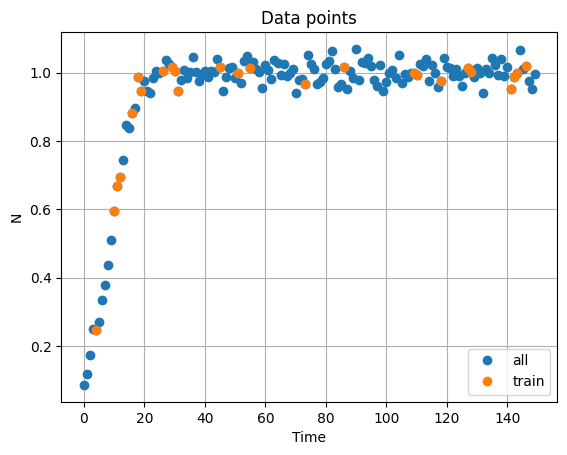

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 5.071e-01, pinn loss: 3.064e-06, data loss: 5.071e-01, r: 0.010, K: 1.000000
It: 100, Loss: 2.665e-01, pinn loss: 1.019e-07, data loss: 2.665e-01, r: 0.002, K: 1.000000
It: 200, Loss: 5.693e-02, pinn loss: 1.326e-08, data loss: 5.693e-02, r: 0.001, K: 1.000000
It: 300, Loss: 2.887e-02, pinn loss: 3.950e-08, data loss: 2.887e-02, r: 0.002, K: 1.000000
It: 400, Loss: 2.791e-02, pinn loss: 5.680e-08, data loss: 2.791e-02, r: 0.003, K: 1.000000
It: 500, Loss: 2.649e-02, pinn loss: 9.356e-08, data loss: 2.649e-02, r: 0.005, K: 1.000000
It: 600, Loss: 2.424e-02, pinn loss: 2.011e-07, data loss: 2.424e-02, r: 0.007, K: 1.000000
It: 700, Loss: 2.131e-02, pinn loss: 5.704e-07, data loss: 2.131e-02, r: 0.012, K: 1.000000
It: 800, Loss: 1.951e-02, pinn loss: 1.505e-06, data loss: 1.951e-02, r: 0.019, K: 1.000000
It: 900, Loss: 1.856e-02, pinn loss: 2.245e-06, data loss: 1.855e-02, r: 0.024, K: 1.000000
Loss: 4.578e-04, pinn loss: 4.808e-

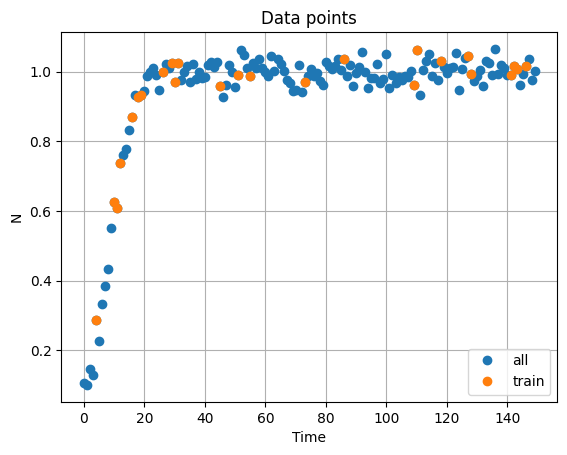

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 5.959e-01, pinn loss: 1.953e-06, data loss: 5.959e-01, r: 0.010, K: 1.000000
It: 100, Loss: 3.282e-01, pinn loss: 5.981e-08, data loss: 3.282e-01, r: 0.001, K: 1.000000
It: 200, Loss: 6.105e-02, pinn loss: 4.913e-09, data loss: 6.105e-02, r: 0.000, K: 1.000000
It: 300, Loss: 2.880e-02, pinn loss: 1.256e-08, data loss: 2.880e-02, r: 0.001, K: 1.000000
It: 400, Loss: 2.826e-02, pinn loss: 1.423e-08, data loss: 2.826e-02, r: 0.002, K: 1.000000
It: 500, Loss: 2.751e-02, pinn loss: 1.800e-08, data loss: 2.751e-02, r: 0.003, K: 1.000000
It: 600, Loss: 2.634e-02, pinn loss: 2.875e-08, data loss: 2.634e-02, r: 0.004, K: 1.000000
It: 700, Loss: 2.435e-02, pinn loss: 6.468e-08, data loss: 2.435e-02, r: 0.007, K: 1.000000
It: 800, Loss: 2.114e-02, pinn loss: 2.414e-07, data loss: 2.114e-02, r: 0.011, K: 1.000000
It: 900, Loss: 1.823e-02, pinn loss: 1.208e-06, data loss: 1.822e-02, r: 0.017, K: 1.000000
Loss: 6.550e-04, pinn loss: 8.489e-

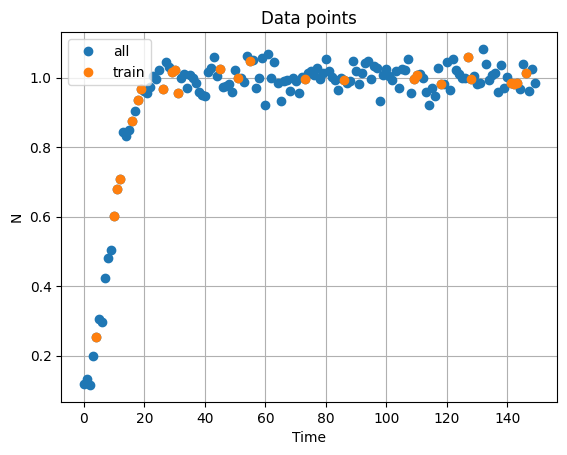

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 8.901e-01, pinn loss: 3.131e-09, data loss: 8.901e-01, r: 0.010, K: 1.000000
It: 100, Loss: 5.427e-01, pinn loss: 1.486e-09, data loss: 5.427e-01, r: 0.000, K: 1.000000
It: 200, Loss: 9.161e-02, pinn loss: 1.027e-08, data loss: 9.161e-02, r: 0.001, K: 1.000000
It: 300, Loss: 2.861e-02, pinn loss: 9.822e-09, data loss: 2.861e-02, r: 0.004, K: 1.000000
It: 400, Loss: 2.785e-02, pinn loss: 9.766e-09, data loss: 2.785e-02, r: 0.005, K: 1.000000
It: 500, Loss: 2.715e-02, pinn loss: 1.186e-08, data loss: 2.715e-02, r: 0.007, K: 1.000000
It: 600, Loss: 2.618e-02, pinn loss: 1.318e-08, data loss: 2.618e-02, r: 0.008, K: 1.000000
It: 700, Loss: 2.475e-02, pinn loss: 1.004e-08, data loss: 2.475e-02, r: 0.011, K: 1.000000
It: 800, Loss: 2.262e-02, pinn loss: 1.490e-09, data loss: 2.262e-02, r: 0.016, K: 1.000000
It: 900, Loss: 1.991e-02, pinn loss: 1.476e-07, data loss: 1.991e-02, r: 0.023, K: 1.000000
estimated alpha:  0.259005486965179

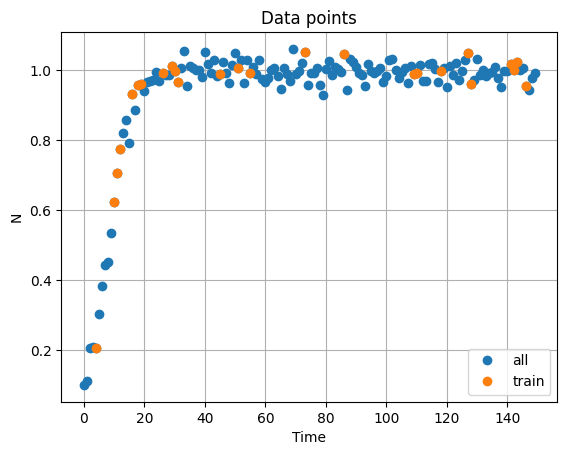

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 8.601e-01, pinn loss: 2.443e-08, data loss: 8.601e-01, r: 0.010, K: 1.000000
It: 100, Loss: 4.586e-01, pinn loss: 3.795e-09, data loss: 4.586e-01, r: 0.000, K: 1.000000
It: 200, Loss: 8.483e-02, pinn loss: 7.659e-09, data loss: 8.483e-02, r: 0.001, K: 1.000000
It: 300, Loss: 3.026e-02, pinn loss: 8.898e-09, data loss: 3.026e-02, r: 0.002, K: 1.000000
It: 400, Loss: 2.938e-02, pinn loss: 8.073e-09, data loss: 2.938e-02, r: 0.004, K: 1.000000
It: 500, Loss: 2.871e-02, pinn loss: 8.741e-09, data loss: 2.871e-02, r: 0.005, K: 1.000000
It: 600, Loss: 2.783e-02, pinn loss: 8.848e-09, data loss: 2.783e-02, r: 0.007, K: 1.000000
It: 700, Loss: 2.662e-02, pinn loss: 6.482e-09, data loss: 2.662e-02, r: 0.010, K: 1.000000
It: 800, Loss: 2.493e-02, pinn loss: 3.908e-09, data loss: 2.493e-02, r: 0.014, K: 1.000000
It: 900, Loss: 2.280e-02, pinn loss: 7.724e-08, data loss: 2.280e-02, r: 0.019, K: 1.000000
estimated alpha:  0.320668607950210

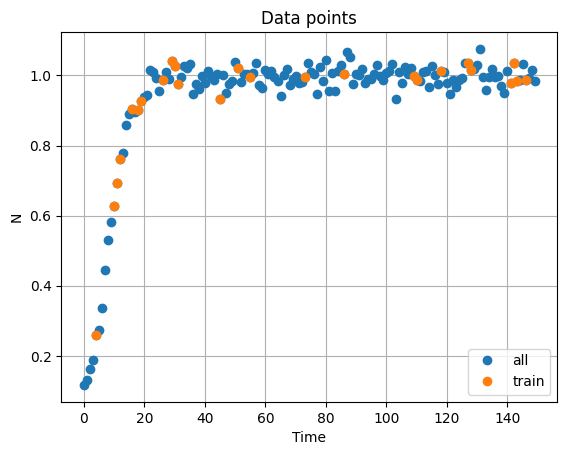

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 8.494e-01, pinn loss: 2.276e-08, data loss: 8.494e-01, r: 0.010, K: 1.000000
It: 100, Loss: 5.383e-01, pinn loss: 2.774e-09, data loss: 5.383e-01, r: 0.000, K: 1.000000
It: 200, Loss: 1.794e-01, pinn loss: 2.019e-08, data loss: 1.794e-01, r: 0.001, K: 1.000000
It: 300, Loss: 3.051e-02, pinn loss: 3.323e-08, data loss: 3.051e-02, r: 0.003, K: 1.000000
It: 400, Loss: 2.519e-02, pinn loss: 3.422e-08, data loss: 2.519e-02, r: 0.006, K: 1.000000
It: 500, Loss: 2.384e-02, pinn loss: 4.445e-08, data loss: 2.384e-02, r: 0.009, K: 1.000000
It: 600, Loss: 2.168e-02, pinn loss: 4.736e-08, data loss: 2.168e-02, r: 0.014, K: 1.000000
It: 700, Loss: 1.850e-02, pinn loss: 1.892e-08, data loss: 1.850e-02, r: 0.022, K: 1.000000
It: 800, Loss: 1.560e-02, pinn loss: 6.621e-07, data loss: 1.560e-02, r: 0.032, K: 1.000000
It: 900, Loss: 1.421e-02, pinn loss: 2.757e-06, data loss: 1.421e-02, r: 0.037, K: 1.000000
estimated alpha:  0.259762465953826

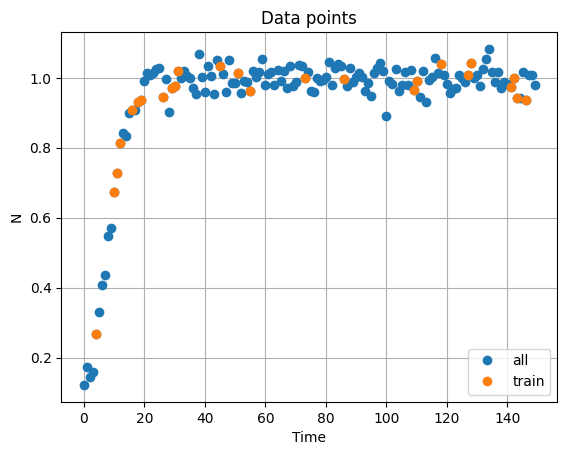

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.229e+00, pinn loss: 3.990e-06, data loss: 1.229e+00, r: 0.010, K: 1.000000
It: 100, Loss: 7.071e-01, pinn loss: 2.911e-07, data loss: 7.071e-01, r: 0.006, K: 1.000000
It: 200, Loss: 1.554e-01, pinn loss: 1.109e-08, data loss: 1.554e-01, r: 0.000, K: 1.000000
It: 300, Loss: 2.418e-02, pinn loss: 3.334e-08, data loss: 2.418e-02, r: 0.002, K: 1.000000
It: 400, Loss: 2.243e-02, pinn loss: 4.104e-08, data loss: 2.243e-02, r: 0.004, K: 1.000000
It: 500, Loss: 2.177e-02, pinn loss: 3.565e-08, data loss: 2.177e-02, r: 0.006, K: 1.000000
It: 600, Loss: 2.100e-02, pinn loss: 3.416e-08, data loss: 2.100e-02, r: 0.008, K: 1.000000
It: 700, Loss: 2.012e-02, pinn loss: 3.791e-08, data loss: 2.012e-02, r: 0.010, K: 1.000000
It: 800, Loss: 1.916e-02, pinn loss: 5.513e-08, data loss: 1.916e-02, r: 0.013, K: 1.000000
It: 900, Loss: 1.820e-02, pinn loss: 1.135e-07, data loss: 1.820e-02, r: 0.016, K: 1.000000
Loss: 7.512e-04, pinn loss: 7.310e-

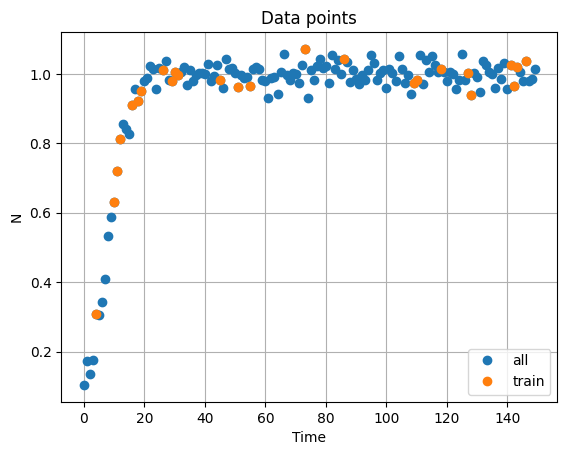

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.342e+00, pinn loss: 6.974e-06, data loss: 1.342e+00, r: 0.010, K: 1.000000
It: 100, Loss: 9.069e-01, pinn loss: 1.664e-09, data loss: 9.069e-01, r: 0.005, K: 1.000000
It: 200, Loss: 2.918e-01, pinn loss: 1.653e-07, data loss: 2.918e-01, r: 0.002, K: 1.000000
It: 300, Loss: 4.232e-02, pinn loss: 5.053e-09, data loss: 4.232e-02, r: 0.000, K: 1.000000
It: 400, Loss: 2.501e-02, pinn loss: 5.628e-09, data loss: 2.501e-02, r: 0.001, K: 1.000000
It: 500, Loss: 2.471e-02, pinn loss: 6.008e-09, data loss: 2.471e-02, r: 0.001, K: 1.000000
It: 600, Loss: 2.461e-02, pinn loss: 6.335e-09, data loss: 2.461e-02, r: 0.001, K: 1.000000
It: 700, Loss: 2.450e-02, pinn loss: 6.923e-09, data loss: 2.450e-02, r: 0.001, K: 1.000000
It: 800, Loss: 2.435e-02, pinn loss: 7.879e-09, data loss: 2.435e-02, r: 0.001, K: 1.000000
It: 900, Loss: 2.417e-02, pinn loss: 9.362e-09, data loss: 2.417e-02, r: 0.002, K: 1.000000
Loss: 8.696e-04, pinn loss: 1.960e-

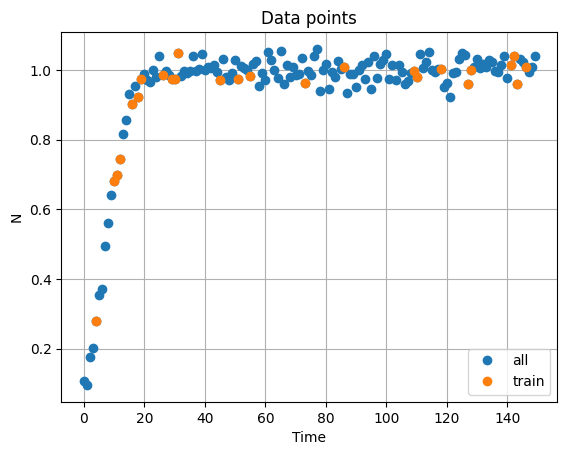

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 7.176e-01, pinn loss: 6.602e-07, data loss: 7.176e-01, r: 0.010, K: 1.000000
It: 100, Loss: 4.505e-01, pinn loss: 1.018e-08, data loss: 4.505e-01, r: 0.001, K: 1.000000
It: 200, Loss: 1.407e-01, pinn loss: 1.079e-09, data loss: 1.407e-01, r: 0.000, K: 1.000000
It: 300, Loss: 2.627e-02, pinn loss: 2.855e-09, data loss: 2.627e-02, r: 0.000, K: 1.000000
It: 400, Loss: 2.533e-02, pinn loss: 3.960e-09, data loss: 2.533e-02, r: 0.001, K: 1.000000
It: 500, Loss: 2.495e-02, pinn loss: 4.993e-09, data loss: 2.495e-02, r: 0.001, K: 1.000000
It: 600, Loss: 2.448e-02, pinn loss: 6.745e-09, data loss: 2.448e-02, r: 0.002, K: 1.000000
It: 700, Loss: 2.381e-02, pinn loss: 9.745e-09, data loss: 2.381e-02, r: 0.003, K: 1.000000
It: 800, Loss: 2.280e-02, pinn loss: 1.476e-08, data loss: 2.280e-02, r: 0.005, K: 1.000000
It: 900, Loss: 2.114e-02, pinn loss: 2.263e-08, data loss: 2.114e-02, r: 0.008, K: 1.000000
Loss: 5.048e-04, pinn loss: 1.285e-

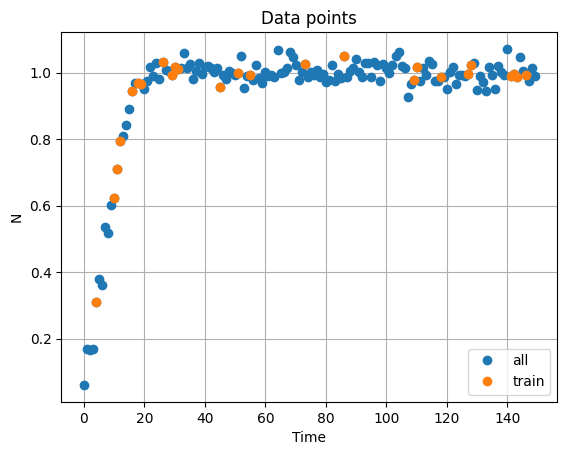

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 7.661e-01, pinn loss: 4.697e-07, data loss: 7.661e-01, r: 0.010, K: 1.000000
It: 100, Loss: 3.703e-01, pinn loss: 1.356e-09, data loss: 3.703e-01, r: 0.000, K: 1.000000
It: 200, Loss: 5.947e-02, pinn loss: 2.913e-09, data loss: 5.947e-02, r: 0.000, K: 1.000000
It: 300, Loss: 2.473e-02, pinn loss: 9.650e-09, data loss: 2.473e-02, r: 0.001, K: 1.000000
It: 400, Loss: 2.421e-02, pinn loss: 1.087e-08, data loss: 2.421e-02, r: 0.003, K: 1.000000
It: 500, Loss: 2.355e-02, pinn loss: 1.368e-08, data loss: 2.355e-02, r: 0.004, K: 1.000000
It: 600, Loss: 2.256e-02, pinn loss: 2.123e-08, data loss: 2.256e-02, r: 0.006, K: 1.000000
It: 700, Loss: 2.108e-02, pinn loss: 4.180e-08, data loss: 2.108e-02, r: 0.009, K: 1.000000
It: 800, Loss: 1.923e-02, pinn loss: 1.429e-07, data loss: 1.923e-02, r: 0.014, K: 1.000000
It: 900, Loss: 1.775e-02, pinn loss: 6.166e-07, data loss: 1.775e-02, r: 0.020, K: 1.000000
estimated alpha:  0.243113651871681

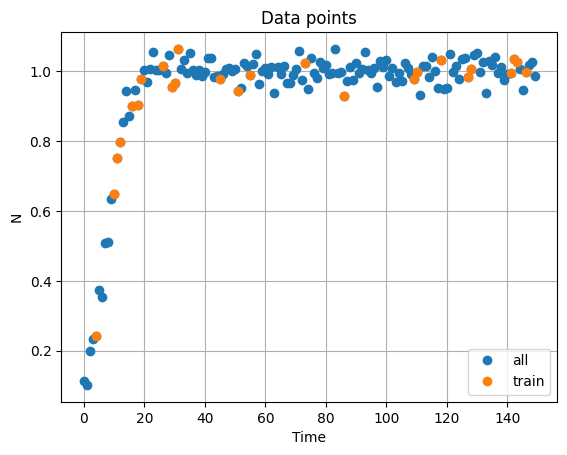

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 6.434e-01, pinn loss: 1.426e-06, data loss: 6.434e-01, r: 0.010, K: 1.000000
It: 100, Loss: 2.732e-01, pinn loss: 3.957e-08, data loss: 2.732e-01, r: 0.001, K: 1.000000
It: 200, Loss: 4.795e-02, pinn loss: 5.957e-09, data loss: 4.795e-02, r: -0.000, K: 1.000000
It: 300, Loss: 2.801e-02, pinn loss: 6.693e-09, data loss: 2.801e-02, r: -0.000, K: 1.000000
It: 400, Loss: 2.731e-02, pinn loss: 1.100e-08, data loss: 2.731e-02, r: 0.000, K: 1.000000
It: 500, Loss: 2.647e-02, pinn loss: 1.856e-08, data loss: 2.647e-02, r: 0.001, K: 1.000000
It: 600, Loss: 2.530e-02, pinn loss: 3.122e-08, data loss: 2.530e-02, r: 0.002, K: 1.000000
It: 700, Loss: 2.360e-02, pinn loss: 6.297e-08, data loss: 2.360e-02, r: 0.005, K: 1.000000
It: 800, Loss: 2.144e-02, pinn loss: 1.802e-07, data loss: 2.144e-02, r: 0.009, K: 1.000000
It: 900, Loss: 1.981e-02, pinn loss: 6.091e-07, data loss: 1.981e-02, r: 0.014, K: 1.000000
Loss: 9.618e-04, pinn loss: 2.974

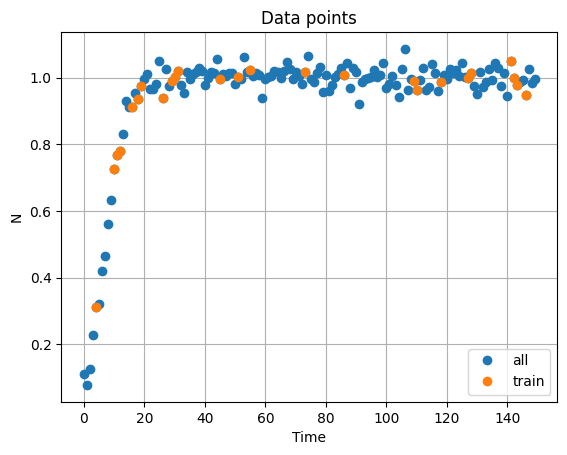

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 6.804e-01, pinn loss: 1.125e-06, data loss: 6.804e-01, r: 0.010, K: 1.000000
It: 100, Loss: 3.741e-01, pinn loss: 2.322e-08, data loss: 3.741e-01, r: 0.001, K: 1.000000
It: 200, Loss: 1.024e-01, pinn loss: 7.537e-10, data loss: 1.024e-01, r: 0.000, K: 1.000000
It: 300, Loss: 2.369e-02, pinn loss: 1.651e-09, data loss: 2.369e-02, r: 0.000, K: 1.000000
It: 400, Loss: 2.202e-02, pinn loss: 2.277e-09, data loss: 2.202e-02, r: 0.001, K: 1.000000
It: 500, Loss: 2.186e-02, pinn loss: 2.569e-09, data loss: 2.186e-02, r: 0.001, K: 1.000000
It: 600, Loss: 2.165e-02, pinn loss: 3.039e-09, data loss: 2.165e-02, r: 0.001, K: 1.000000
It: 700, Loss: 2.139e-02, pinn loss: 3.854e-09, data loss: 2.139e-02, r: 0.002, K: 1.000000
It: 800, Loss: 2.102e-02, pinn loss: 5.317e-09, data loss: 2.102e-02, r: 0.003, K: 1.000000
It: 900, Loss: 2.047e-02, pinn loss: 8.206e-09, data loss: 2.047e-02, r: 0.004, K: 1.000000
Loss: 5.031e-04, pinn loss: 2.944e-

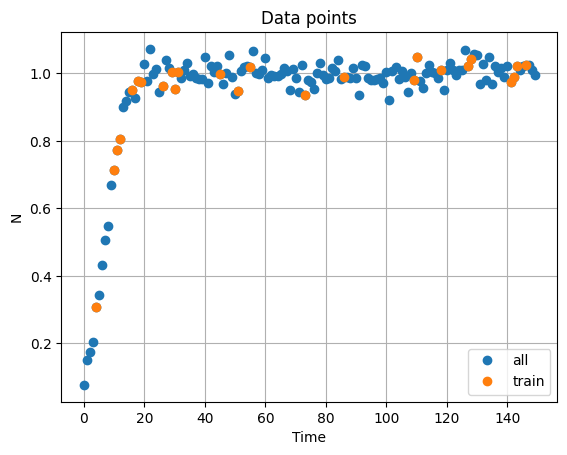

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 6.408e-01, pinn loss: 1.614e-06, data loss: 6.408e-01, r: 0.010, K: 1.000000
It: 100, Loss: 2.888e-01, pinn loss: 3.742e-08, data loss: 2.888e-01, r: 0.001, K: 1.000000
It: 200, Loss: 3.581e-02, pinn loss: 5.293e-09, data loss: 3.581e-02, r: 0.000, K: 1.000000
It: 300, Loss: 2.199e-02, pinn loss: 1.035e-08, data loss: 2.199e-02, r: 0.001, K: 1.000000
It: 400, Loss: 2.158e-02, pinn loss: 1.500e-08, data loss: 2.158e-02, r: 0.001, K: 1.000000
It: 500, Loss: 2.103e-02, pinn loss: 2.197e-08, data loss: 2.103e-02, r: 0.002, K: 1.000000
It: 600, Loss: 2.022e-02, pinn loss: 3.495e-08, data loss: 2.022e-02, r: 0.004, K: 1.000000
It: 700, Loss: 1.901e-02, pinn loss: 6.477e-08, data loss: 1.901e-02, r: 0.006, K: 1.000000
It: 800, Loss: 1.729e-02, pinn loss: 1.554e-07, data loss: 1.729e-02, r: 0.009, K: 1.000000
It: 900, Loss: 1.569e-02, pinn loss: 4.887e-07, data loss: 1.569e-02, r: 0.015, K: 1.000000
Loss: 5.962e-04, pinn loss: 1.131e-

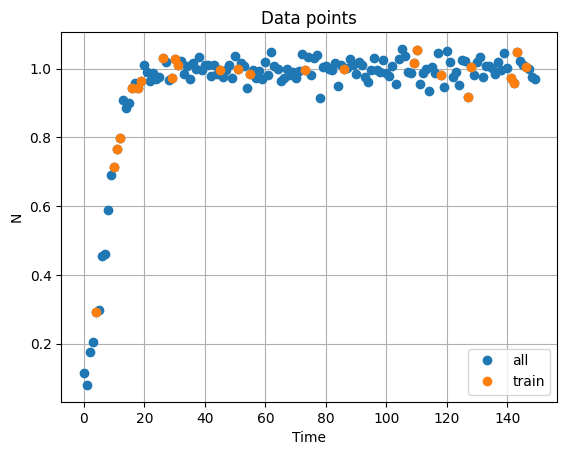

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.127e+00, pinn loss: 1.613e-06, data loss: 1.127e+00, r: 0.010, K: 1.000000
It: 100, Loss: 7.550e-01, pinn loss: 1.935e-07, data loss: 7.550e-01, r: 0.006, K: 1.000000
It: 200, Loss: 1.865e-01, pinn loss: 1.543e-09, data loss: 1.865e-01, r: -0.000, K: 1.000000
It: 300, Loss: 2.768e-02, pinn loss: 1.242e-09, data loss: 2.768e-02, r: -0.000, K: 1.000000
It: 400, Loss: 2.416e-02, pinn loss: 1.146e-09, data loss: 2.416e-02, r: -0.000, K: 1.000000
It: 500, Loss: 2.411e-02, pinn loss: 1.148e-09, data loss: 2.411e-02, r: -0.000, K: 1.000000
It: 600, Loss: 2.406e-02, pinn loss: 1.158e-09, data loss: 2.406e-02, r: 0.000, K: 1.000000
It: 700, Loss: 2.400e-02, pinn loss: 1.174e-09, data loss: 2.400e-02, r: 0.000, K: 1.000000
It: 800, Loss: 2.392e-02, pinn loss: 1.209e-09, data loss: 2.392e-02, r: 0.000, K: 1.000000
It: 900, Loss: 2.384e-02, pinn loss: 1.271e-09, data loss: 2.384e-02, r: 0.001, K: 1.000000
Loss: 7.616e-04, pinn loss: 2.5

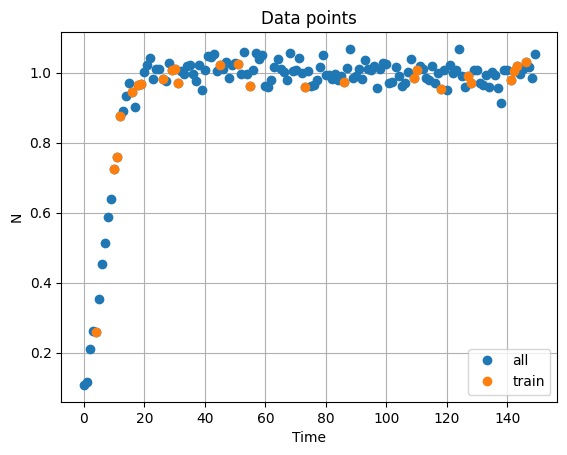

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.011e+00, pinn loss: 3.668e-07, data loss: 1.011e+00, r: 0.010, K: 1.000000
It: 100, Loss: 6.023e-01, pinn loss: 1.279e-08, data loss: 6.023e-01, r: 0.001, K: 1.000000
It: 200, Loss: 1.456e-01, pinn loss: 4.770e-09, data loss: 1.456e-01, r: 0.000, K: 1.000000
It: 300, Loss: 2.460e-02, pinn loss: 7.625e-09, data loss: 2.460e-02, r: 0.000, K: 1.000000
It: 400, Loss: 2.344e-02, pinn loss: 8.131e-09, data loss: 2.344e-02, r: 0.001, K: 1.000000
It: 500, Loss: 2.307e-02, pinn loss: 8.589e-09, data loss: 2.307e-02, r: 0.002, K: 1.000000
It: 600, Loss: 2.264e-02, pinn loss: 9.199e-09, data loss: 2.264e-02, r: 0.003, K: 1.000000
It: 700, Loss: 2.213e-02, pinn loss: 9.641e-09, data loss: 2.213e-02, r: 0.005, K: 1.000000
It: 800, Loss: 2.149e-02, pinn loss: 9.118e-09, data loss: 2.149e-02, r: 0.007, K: 1.000000
It: 900, Loss: 2.069e-02, pinn loss: 6.088e-09, data loss: 2.069e-02, r: 0.009, K: 1.000000
estimated alpha:  0.325017124414443

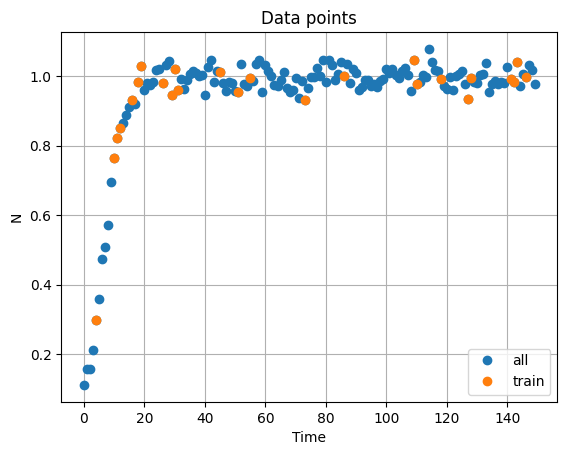

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 7.124e-01, pinn loss: 9.823e-07, data loss: 7.124e-01, r: 0.010, K: 1.000000
It: 100, Loss: 3.828e-01, pinn loss: 1.063e-08, data loss: 3.828e-01, r: 0.001, K: 1.000000
It: 200, Loss: 7.230e-02, pinn loss: 3.029e-08, data loss: 7.230e-02, r: 0.001, K: 1.000000
It: 300, Loss: 1.949e-02, pinn loss: 5.089e-08, data loss: 1.949e-02, r: 0.003, K: 1.000000
It: 400, Loss: 1.871e-02, pinn loss: 5.161e-08, data loss: 1.871e-02, r: 0.005, K: 1.000000
It: 500, Loss: 1.830e-02, pinn loss: 4.692e-08, data loss: 1.830e-02, r: 0.007, K: 1.000000
It: 600, Loss: 1.779e-02, pinn loss: 4.590e-08, data loss: 1.779e-02, r: 0.009, K: 1.000000
It: 700, Loss: 1.716e-02, pinn loss: 4.569e-08, data loss: 1.716e-02, r: 0.011, K: 1.000000
It: 800, Loss: 1.642e-02, pinn loss: 4.646e-08, data loss: 1.642e-02, r: 0.014, K: 1.000000
It: 900, Loss: 1.564e-02, pinn loss: 6.797e-08, data loss: 1.564e-02, r: 0.018, K: 1.000000
Loss: 8.553e-04, pinn loss: 1.494e-

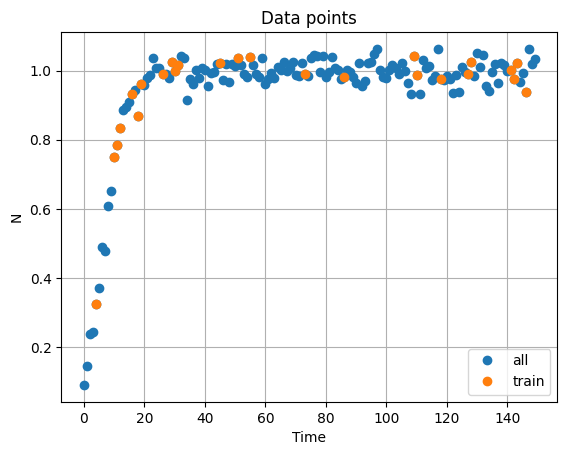

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 9.044e-01, pinn loss: 1.361e-10, data loss: 9.044e-01, r: 0.010, K: 1.000000
It: 100, Loss: 5.104e-01, pinn loss: 3.133e-09, data loss: 5.104e-01, r: 0.000, K: 1.000000
It: 200, Loss: 8.366e-02, pinn loss: 1.137e-08, data loss: 8.366e-02, r: 0.001, K: 1.000000
It: 300, Loss: 2.047e-02, pinn loss: 1.191e-08, data loss: 2.047e-02, r: 0.002, K: 1.000000
It: 400, Loss: 1.989e-02, pinn loss: 1.035e-08, data loss: 1.989e-02, r: 0.004, K: 1.000000
It: 500, Loss: 1.965e-02, pinn loss: 1.096e-08, data loss: 1.965e-02, r: 0.005, K: 1.000000
It: 600, Loss: 1.936e-02, pinn loss: 1.167e-08, data loss: 1.936e-02, r: 0.006, K: 1.000000
It: 700, Loss: 1.898e-02, pinn loss: 1.196e-08, data loss: 1.898e-02, r: 0.007, K: 1.000000
It: 800, Loss: 1.849e-02, pinn loss: 1.101e-08, data loss: 1.849e-02, r: 0.009, K: 1.000000
It: 900, Loss: 1.784e-02, pinn loss: 7.303e-09, data loss: 1.784e-02, r: 0.011, K: 1.000000
Loss: 6.342e-04, pinn loss: 1.801e-

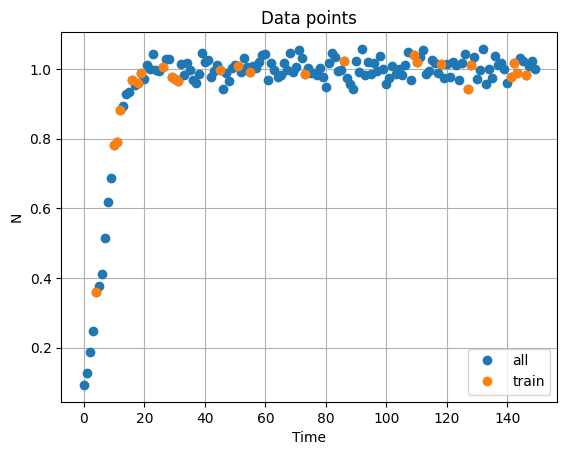

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.112e+00, pinn loss: 1.153e-06, data loss: 1.112e+00, r: 0.010, K: 1.000000
It: 100, Loss: 5.194e-01, pinn loss: 1.352e-07, data loss: 5.194e-01, r: 0.002, K: 1.000000
It: 200, Loss: 5.605e-02, pinn loss: 1.694e-08, data loss: 5.605e-02, r: 0.000, K: 1.000000
It: 300, Loss: 1.719e-02, pinn loss: 2.128e-08, data loss: 1.719e-02, r: 0.001, K: 1.000000
It: 400, Loss: 1.686e-02, pinn loss: 1.997e-08, data loss: 1.686e-02, r: 0.003, K: 1.000000
It: 500, Loss: 1.659e-02, pinn loss: 1.782e-08, data loss: 1.659e-02, r: 0.004, K: 1.000000
It: 600, Loss: 1.629e-02, pinn loss: 1.559e-08, data loss: 1.629e-02, r: 0.005, K: 1.000000
It: 700, Loss: 1.595e-02, pinn loss: 1.277e-08, data loss: 1.595e-02, r: 0.007, K: 1.000000
It: 800, Loss: 1.556e-02, pinn loss: 9.236e-09, data loss: 1.556e-02, r: 0.008, K: 1.000000
It: 900, Loss: 1.513e-02, pinn loss: 5.820e-09, data loss: 1.513e-02, r: 0.010, K: 1.000000
Loss: 4.319e-04, pinn loss: 4.358e-

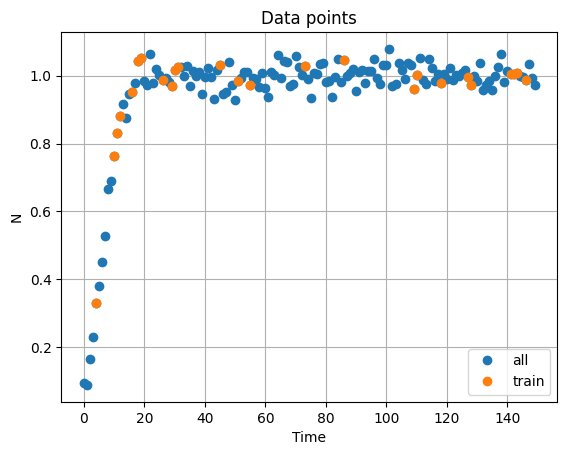

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.558e+00, pinn loss: 1.386e-05, data loss: 1.558e+00, r: 0.010, K: 1.000000
It: 100, Loss: 9.637e-01, pinn loss: 2.990e-08, data loss: 9.637e-01, r: 0.005, K: 1.000000
It: 200, Loss: 1.647e-01, pinn loss: 2.737e-07, data loss: 1.647e-01, r: 0.003, K: 1.000000
It: 300, Loss: 2.020e-02, pinn loss: 1.092e-08, data loss: 2.020e-02, r: 0.002, K: 1.000000
It: 400, Loss: 1.924e-02, pinn loss: 2.191e-08, data loss: 1.924e-02, r: 0.002, K: 1.000000
It: 500, Loss: 1.906e-02, pinn loss: 2.995e-08, data loss: 1.906e-02, r: 0.002, K: 1.000000
It: 600, Loss: 1.886e-02, pinn loss: 3.946e-08, data loss: 1.886e-02, r: 0.002, K: 1.000000
It: 700, Loss: 1.865e-02, pinn loss: 5.089e-08, data loss: 1.865e-02, r: 0.003, K: 1.000000
It: 800, Loss: 1.841e-02, pinn loss: 6.481e-08, data loss: 1.841e-02, r: 0.003, K: 1.000000
It: 900, Loss: 1.814e-02, pinn loss: 8.220e-08, data loss: 1.814e-02, r: 0.004, K: 1.000000
Loss: 6.070e-04, pinn loss: 1.208e-

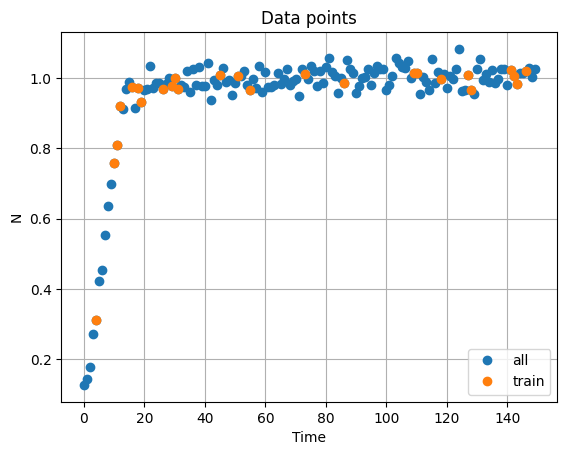

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.063e+00, pinn loss: 7.298e-07, data loss: 1.063e+00, r: 0.010, K: 1.000000
It: 100, Loss: 5.961e-01, pinn loss: 7.509e-08, data loss: 5.961e-01, r: 0.002, K: 1.000000
It: 200, Loss: 1.070e-01, pinn loss: 6.198e-09, data loss: 1.070e-01, r: 0.001, K: 1.000000
It: 300, Loss: 2.031e-02, pinn loss: 7.887e-09, data loss: 2.031e-02, r: 0.002, K: 1.000000
It: 400, Loss: 1.864e-02, pinn loss: 7.373e-09, data loss: 1.864e-02, r: 0.004, K: 1.000000
It: 500, Loss: 1.828e-02, pinn loss: 5.765e-09, data loss: 1.828e-02, r: 0.006, K: 1.000000
It: 600, Loss: 1.784e-02, pinn loss: 5.478e-09, data loss: 1.784e-02, r: 0.008, K: 1.000000
It: 700, Loss: 1.728e-02, pinn loss: 4.978e-09, data loss: 1.728e-02, r: 0.010, K: 1.000000
It: 800, Loss: 1.655e-02, pinn loss: 4.864e-09, data loss: 1.655e-02, r: 0.012, K: 1.000000
It: 900, Loss: 1.563e-02, pinn loss: 1.730e-08, data loss: 1.563e-02, r: 0.016, K: 1.000000
Loss: 3.223e-04, pinn loss: 3.327e-

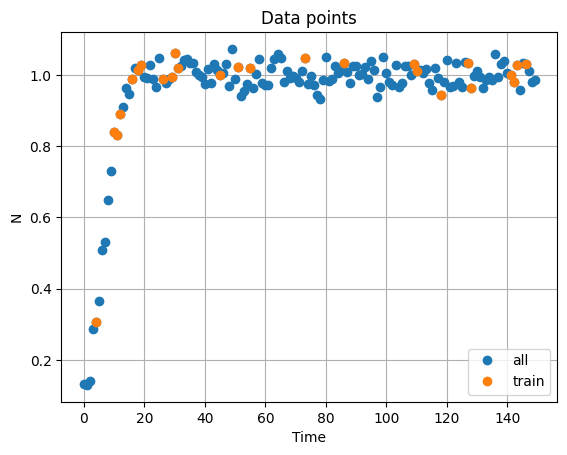

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.152e+00, pinn loss: 1.152e-06, data loss: 1.152e+00, r: 0.010, K: 1.000000
It: 100, Loss: 7.394e-01, pinn loss: 2.431e-07, data loss: 7.394e-01, r: 0.005, K: 1.000000
It: 200, Loss: 2.172e-01, pinn loss: 4.511e-09, data loss: 2.172e-01, r: 0.001, K: 1.000000
It: 300, Loss: 2.803e-02, pinn loss: 7.275e-09, data loss: 2.803e-02, r: 0.001, K: 1.000000
It: 400, Loss: 2.023e-02, pinn loss: 1.165e-08, data loss: 2.023e-02, r: 0.003, K: 1.000000
It: 500, Loss: 2.011e-02, pinn loss: 8.514e-09, data loss: 2.011e-02, r: 0.005, K: 1.000000
It: 600, Loss: 2.000e-02, pinn loss: 5.930e-09, data loss: 2.000e-02, r: 0.006, K: 1.000000
It: 700, Loss: 1.986e-02, pinn loss: 4.852e-09, data loss: 1.986e-02, r: 0.007, K: 1.000000
It: 800, Loss: 1.969e-02, pinn loss: 4.464e-09, data loss: 1.969e-02, r: 0.008, K: 1.000000
It: 900, Loss: 1.948e-02, pinn loss: 4.389e-09, data loss: 1.948e-02, r: 0.009, K: 1.000000
estimated alpha:  0.371091991662979

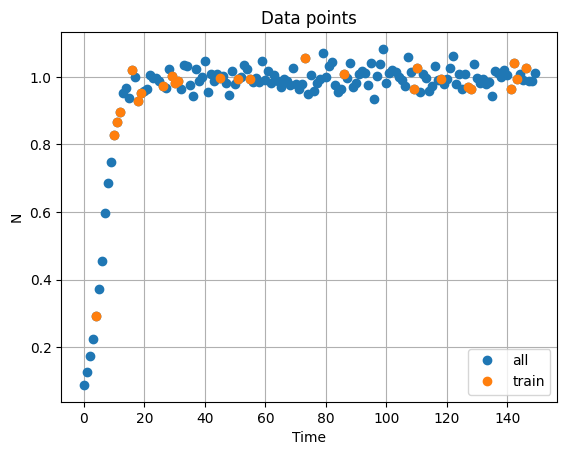

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 8.278e-01, pinn loss: 2.202e-07, data loss: 8.278e-01, r: 0.010, K: 1.000000
It: 100, Loss: 4.887e-01, pinn loss: 2.790e-10, data loss: 4.887e-01, r: 0.000, K: 1.000000
It: 200, Loss: 8.493e-02, pinn loss: 3.310e-09, data loss: 8.493e-02, r: 0.000, K: 1.000000
It: 300, Loss: 2.018e-02, pinn loss: 4.559e-09, data loss: 2.018e-02, r: 0.001, K: 1.000000
It: 400, Loss: 1.982e-02, pinn loss: 5.100e-09, data loss: 1.982e-02, r: 0.001, K: 1.000000
It: 500, Loss: 1.960e-02, pinn loss: 5.337e-09, data loss: 1.960e-02, r: 0.002, K: 1.000000
It: 600, Loss: 1.934e-02, pinn loss: 5.664e-09, data loss: 1.934e-02, r: 0.003, K: 1.000000
It: 700, Loss: 1.901e-02, pinn loss: 5.970e-09, data loss: 1.901e-02, r: 0.004, K: 1.000000
It: 800, Loss: 1.859e-02, pinn loss: 6.063e-09, data loss: 1.859e-02, r: 0.006, K: 1.000000
It: 900, Loss: 1.804e-02, pinn loss: 6.152e-09, data loss: 1.804e-02, r: 0.008, K: 1.000000
Loss: 7.159e-04, pinn loss: 1.175e-

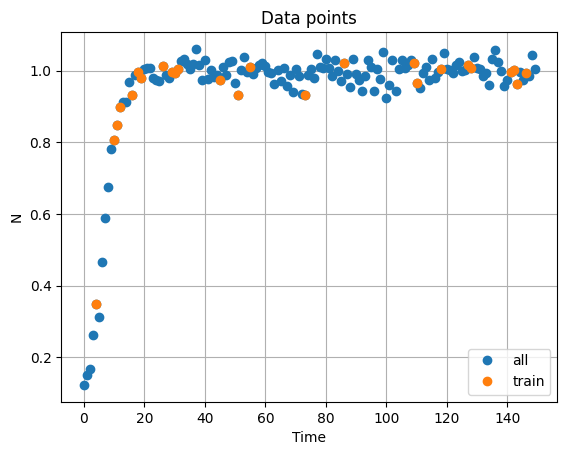

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 6.907e-01, pinn loss: 1.157e-06, data loss: 6.907e-01, r: 0.010, K: 1.000000
It: 100, Loss: 2.826e-01, pinn loss: 2.515e-08, data loss: 2.826e-01, r: 0.001, K: 1.000000
It: 200, Loss: 3.479e-02, pinn loss: 3.745e-09, data loss: 3.479e-02, r: -0.000, K: 1.000000
It: 300, Loss: 1.759e-02, pinn loss: 4.642e-09, data loss: 1.759e-02, r: -0.000, K: 1.000000
It: 400, Loss: 1.728e-02, pinn loss: 7.790e-09, data loss: 1.728e-02, r: 0.000, K: 1.000000
It: 500, Loss: 1.696e-02, pinn loss: 1.313e-08, data loss: 1.696e-02, r: 0.001, K: 1.000000
It: 600, Loss: 1.657e-02, pinn loss: 2.009e-08, data loss: 1.657e-02, r: 0.002, K: 1.000000
It: 700, Loss: 1.609e-02, pinn loss: 2.988e-08, data loss: 1.609e-02, r: 0.003, K: 1.000000
It: 800, Loss: 1.548e-02, pinn loss: 4.604e-08, data loss: 1.548e-02, r: 0.005, K: 1.000000
It: 900, Loss: 1.476e-02, pinn loss: 7.777e-08, data loss: 1.476e-02, r: 0.008, K: 1.000000
estimated alpha:  0.3349796235561

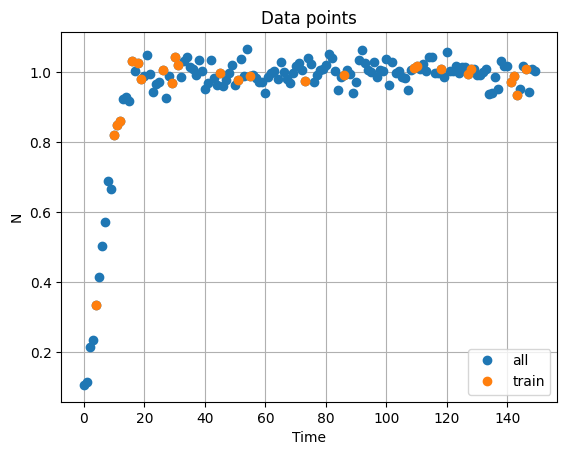

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 5.021e-01, pinn loss: 3.657e-06, data loss: 5.021e-01, r: 0.010, K: 1.000000
It: 100, Loss: 2.088e-01, pinn loss: 1.335e-07, data loss: 2.088e-01, r: 0.002, K: 1.000000
It: 200, Loss: 2.658e-02, pinn loss: 7.604e-09, data loss: 2.658e-02, r: 0.001, K: 1.000000
It: 300, Loss: 1.800e-02, pinn loss: 2.083e-08, data loss: 1.800e-02, r: 0.001, K: 1.000000
It: 400, Loss: 1.782e-02, pinn loss: 2.719e-08, data loss: 1.782e-02, r: 0.001, K: 1.000000
It: 500, Loss: 1.762e-02, pinn loss: 3.458e-08, data loss: 1.762e-02, r: 0.002, K: 1.000000
It: 600, Loss: 1.738e-02, pinn loss: 4.424e-08, data loss: 1.738e-02, r: 0.003, K: 1.000000
It: 700, Loss: 1.710e-02, pinn loss: 5.804e-08, data loss: 1.710e-02, r: 0.004, K: 1.000000
It: 800, Loss: 1.676e-02, pinn loss: 7.938e-08, data loss: 1.676e-02, r: 0.005, K: 1.000000
It: 900, Loss: 1.637e-02, pinn loss: 1.145e-07, data loss: 1.637e-02, r: 0.007, K: 1.000000
Loss: 5.729e-04, pinn loss: 1.173e-

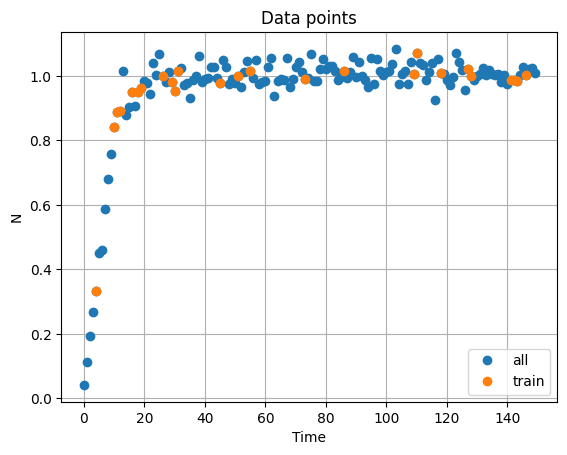

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.325e+00, pinn loss: 5.193e-06, data loss: 1.325e+00, r: 0.010, K: 1.000000
It: 100, Loss: 8.030e-01, pinn loss: 7.863e-08, data loss: 8.030e-01, r: 0.006, K: 1.000000
It: 200, Loss: 1.535e-01, pinn loss: 8.736e-09, data loss: 1.535e-01, r: 0.001, K: 1.000000
It: 300, Loss: 1.929e-02, pinn loss: 1.744e-08, data loss: 1.929e-02, r: 0.001, K: 1.000000
It: 400, Loss: 1.686e-02, pinn loss: 2.900e-08, data loss: 1.686e-02, r: 0.002, K: 1.000000
It: 500, Loss: 1.660e-02, pinn loss: 3.552e-08, data loss: 1.660e-02, r: 0.003, K: 1.000000
It: 600, Loss: 1.628e-02, pinn loss: 4.289e-08, data loss: 1.628e-02, r: 0.004, K: 1.000000
It: 700, Loss: 1.590e-02, pinn loss: 5.316e-08, data loss: 1.590e-02, r: 0.005, K: 1.000000
It: 800, Loss: 1.543e-02, pinn loss: 6.879e-08, data loss: 1.543e-02, r: 0.007, K: 1.000000
It: 900, Loss: 1.485e-02, pinn loss: 9.507e-08, data loss: 1.485e-02, r: 0.009, K: 1.000000
Loss: 3.824e-04, pinn loss: 1.661e-

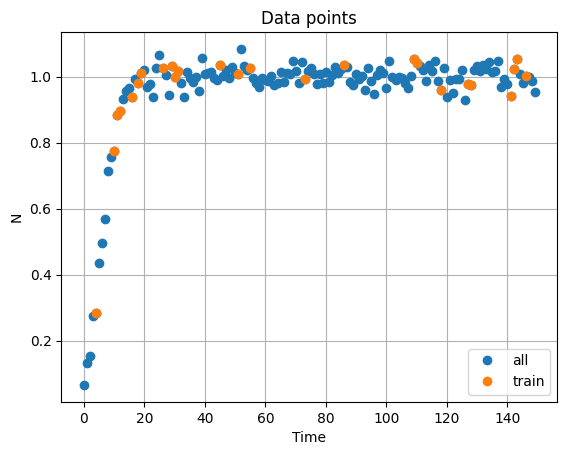

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 7.541e-01, pinn loss: 8.866e-07, data loss: 7.541e-01, r: 0.010, K: 1.000000
It: 100, Loss: 4.546e-01, pinn loss: 1.540e-08, data loss: 4.546e-01, r: 0.001, K: 1.000000
It: 200, Loss: 8.953e-02, pinn loss: 4.562e-09, data loss: 8.953e-02, r: 0.000, K: 1.000000
It: 300, Loss: 2.160e-02, pinn loss: 2.351e-08, data loss: 2.160e-02, r: 0.001, K: 1.000000
It: 400, Loss: 2.120e-02, pinn loss: 3.278e-08, data loss: 2.120e-02, r: 0.003, K: 1.000000
It: 500, Loss: 2.082e-02, pinn loss: 3.827e-08, data loss: 2.082e-02, r: 0.004, K: 1.000000
It: 600, Loss: 2.038e-02, pinn loss: 4.498e-08, data loss: 2.038e-02, r: 0.006, K: 1.000000
It: 700, Loss: 1.988e-02, pinn loss: 5.876e-08, data loss: 1.988e-02, r: 0.009, K: 1.000000
It: 800, Loss: 1.930e-02, pinn loss: 9.604e-08, data loss: 1.930e-02, r: 0.012, K: 1.000000
It: 900, Loss: 1.870e-02, pinn loss: 1.999e-07, data loss: 1.870e-02, r: 0.015, K: 1.000000
Loss: 7.989e-04, pinn loss: 1.508e-

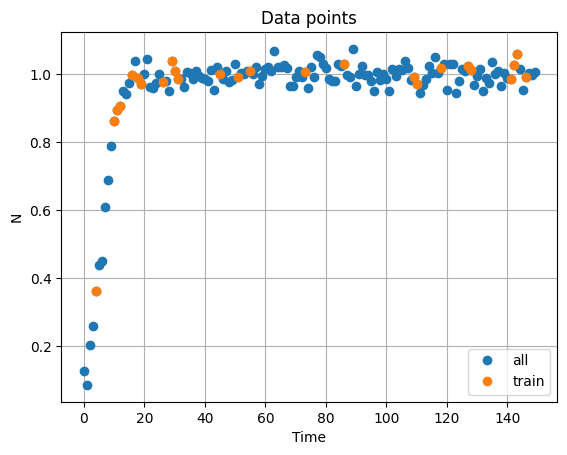

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 9.465e-01, pinn loss: 1.493e-09, data loss: 9.465e-01, r: 0.010, K: 1.000000
It: 100, Loss: 5.241e-01, pinn loss: 3.692e-09, data loss: 5.241e-01, r: -0.000, K: 1.000000
It: 200, Loss: 1.121e-01, pinn loss: 4.051e-09, data loss: 1.121e-01, r: 0.000, K: 1.000000
It: 300, Loss: 1.799e-02, pinn loss: 4.798e-09, data loss: 1.799e-02, r: 0.001, K: 1.000000
It: 400, Loss: 1.631e-02, pinn loss: 4.964e-09, data loss: 1.631e-02, r: 0.002, K: 1.000000
It: 500, Loss: 1.622e-02, pinn loss: 4.252e-09, data loss: 1.622e-02, r: 0.003, K: 1.000000
It: 600, Loss: 1.611e-02, pinn loss: 4.106e-09, data loss: 1.611e-02, r: 0.004, K: 1.000000
It: 700, Loss: 1.598e-02, pinn loss: 4.130e-09, data loss: 1.598e-02, r: 0.005, K: 1.000000
It: 800, Loss: 1.583e-02, pinn loss: 4.118e-09, data loss: 1.583e-02, r: 0.006, K: 1.000000
It: 900, Loss: 1.563e-02, pinn loss: 3.913e-09, data loss: 1.563e-02, r: 0.007, K: 1.000000
Loss: 4.019e-04, pinn loss: 7.749e

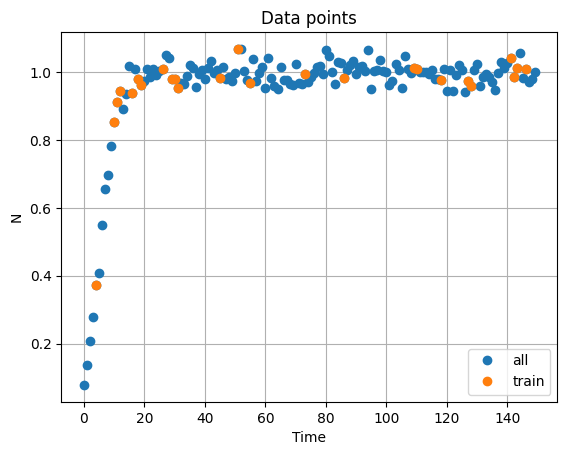

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.348e+00, pinn loss: 5.726e-06, data loss: 1.348e+00, r: 0.010, K: 1.000000
It: 100, Loss: 8.217e-01, pinn loss: 6.085e-08, data loss: 8.217e-01, r: 0.005, K: 1.000000
It: 200, Loss: 1.412e-01, pinn loss: 2.269e-08, data loss: 1.412e-01, r: 0.001, K: 1.000000
It: 300, Loss: 1.627e-02, pinn loss: 1.556e-08, data loss: 1.627e-02, r: 0.000, K: 1.000000
It: 400, Loss: 1.521e-02, pinn loss: 1.829e-08, data loss: 1.521e-02, r: 0.000, K: 1.000000
It: 500, Loss: 1.501e-02, pinn loss: 2.315e-08, data loss: 1.501e-02, r: 0.001, K: 1.000000
It: 600, Loss: 1.479e-02, pinn loss: 2.983e-08, data loss: 1.479e-02, r: 0.001, K: 1.000000
It: 700, Loss: 1.453e-02, pinn loss: 3.834e-08, data loss: 1.453e-02, r: 0.002, K: 1.000000
It: 800, Loss: 1.423e-02, pinn loss: 4.907e-08, data loss: 1.423e-02, r: 0.003, K: 1.000000
It: 900, Loss: 1.388e-02, pinn loss: 6.280e-08, data loss: 1.388e-02, r: 0.004, K: 1.000000
Loss: 6.424e-04, pinn loss: 8.428e-

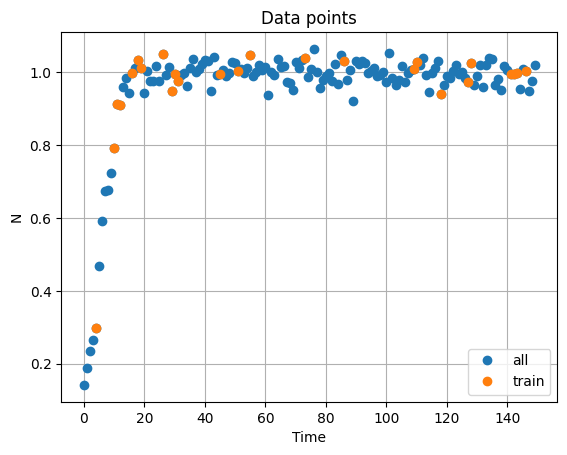

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.073e+00, pinn loss: 4.653e-07, data loss: 1.073e+00, r: 0.010, K: 1.000000
It: 100, Loss: 6.527e-01, pinn loss: 4.169e-08, data loss: 6.527e-01, r: 0.001, K: 1.000000
It: 200, Loss: 9.739e-02, pinn loss: 7.469e-09, data loss: 9.739e-02, r: 0.001, K: 1.000000
It: 300, Loss: 2.019e-02, pinn loss: 1.262e-08, data loss: 2.019e-02, r: 0.003, K: 1.000000
It: 400, Loss: 2.000e-02, pinn loss: 7.655e-09, data loss: 2.000e-02, r: 0.005, K: 1.000000
It: 500, Loss: 1.983e-02, pinn loss: 5.077e-09, data loss: 1.983e-02, r: 0.006, K: 1.000000
It: 600, Loss: 1.965e-02, pinn loss: 3.685e-09, data loss: 1.965e-02, r: 0.008, K: 1.000000
It: 700, Loss: 1.943e-02, pinn loss: 2.503e-09, data loss: 1.943e-02, r: 0.009, K: 1.000000
It: 800, Loss: 1.918e-02, pinn loss: 1.698e-09, data loss: 1.918e-02, r: 0.011, K: 1.000000
It: 900, Loss: 1.889e-02, pinn loss: 2.674e-09, data loss: 1.889e-02, r: 0.013, K: 1.000000
Loss: 7.738e-04, pinn loss: 1.371e-

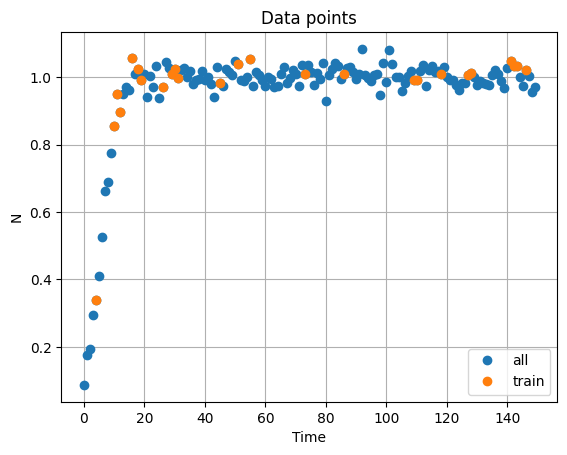

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.053e+00, pinn loss: 2.205e-07, data loss: 1.053e+00, r: 0.010, K: 1.000000
It: 100, Loss: 6.233e-01, pinn loss: 1.792e-09, data loss: 6.233e-01, r: 0.000, K: 1.000000
It: 200, Loss: 1.446e-01, pinn loss: 9.552e-09, data loss: 1.446e-01, r: 0.000, K: 1.000000
It: 300, Loss: 1.876e-02, pinn loss: 1.475e-08, data loss: 1.876e-02, r: 0.001, K: 1.000000
It: 400, Loss: 1.795e-02, pinn loss: 1.484e-08, data loss: 1.795e-02, r: 0.003, K: 1.000000
It: 500, Loss: 1.779e-02, pinn loss: 1.204e-08, data loss: 1.779e-02, r: 0.005, K: 1.000000
It: 600, Loss: 1.761e-02, pinn loss: 9.228e-09, data loss: 1.761e-02, r: 0.007, K: 1.000000
It: 700, Loss: 1.741e-02, pinn loss: 6.327e-09, data loss: 1.741e-02, r: 0.009, K: 1.000000
It: 800, Loss: 1.717e-02, pinn loss: 3.852e-09, data loss: 1.717e-02, r: 0.011, K: 1.000000
It: 900, Loss: 1.689e-02, pinn loss: 3.960e-09, data loss: 1.689e-02, r: 0.014, K: 1.000000
Loss: 6.295e-04, pinn loss: 3.109e-

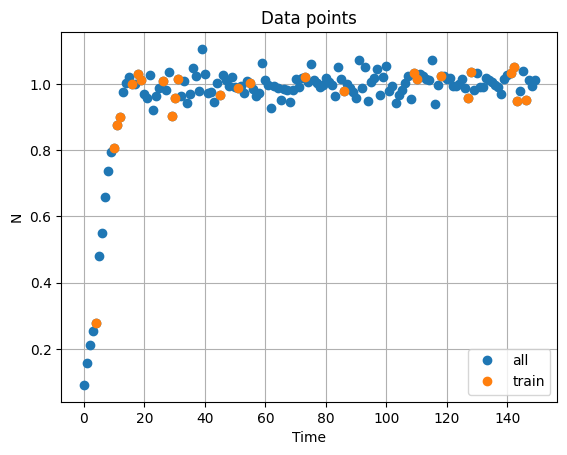

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.518e+00, pinn loss: 1.174e-05, data loss: 1.518e+00, r: 0.010, K: 1.000000
It: 100, Loss: 1.101e+00, pinn loss: 1.681e-07, data loss: 1.101e+00, r: 0.004, K: 1.000000
It: 200, Loss: 4.119e-01, pinn loss: 3.939e-07, data loss: 4.119e-01, r: 0.003, K: 1.000000
It: 300, Loss: 5.331e-02, pinn loss: 6.464e-09, data loss: 5.331e-02, r: 0.001, K: 1.000000
It: 400, Loss: 2.231e-02, pinn loss: 4.970e-09, data loss: 2.231e-02, r: 0.001, K: 1.000000
It: 500, Loss: 2.153e-02, pinn loss: 6.418e-09, data loss: 2.153e-02, r: 0.001, K: 1.000000
It: 600, Loss: 2.147e-02, pinn loss: 7.360e-09, data loss: 2.147e-02, r: 0.001, K: 1.000000
It: 700, Loss: 2.140e-02, pinn loss: 8.388e-09, data loss: 2.140e-02, r: 0.001, K: 1.000000
It: 800, Loss: 2.131e-02, pinn loss: 9.674e-09, data loss: 2.131e-02, r: 0.001, K: 1.000000
It: 900, Loss: 2.121e-02, pinn loss: 1.134e-08, data loss: 2.121e-02, r: 0.001, K: 1.000000
Loss: 1.136e-03, pinn loss: 1.314e-

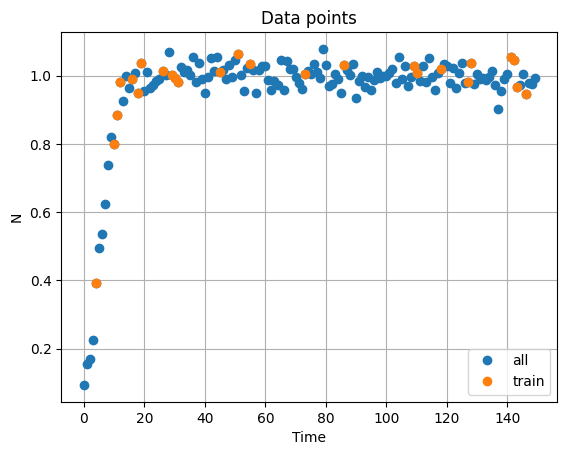

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 6.077e-01, pinn loss: 2.457e-06, data loss: 6.077e-01, r: 0.010, K: 1.000000
It: 100, Loss: 2.934e-01, pinn loss: 5.697e-08, data loss: 2.934e-01, r: 0.001, K: 1.000000
It: 200, Loss: 2.759e-02, pinn loss: 2.991e-08, data loss: 2.759e-02, r: 0.001, K: 1.000000
It: 300, Loss: 1.527e-02, pinn loss: 9.615e-08, data loss: 1.527e-02, r: 0.002, K: 1.000000
It: 400, Loss: 1.498e-02, pinn loss: 1.325e-07, data loss: 1.498e-02, r: 0.003, K: 1.000000
It: 500, Loss: 1.465e-02, pinn loss: 1.818e-07, data loss: 1.465e-02, r: 0.004, K: 1.000000
It: 600, Loss: 1.431e-02, pinn loss: 2.507e-07, data loss: 1.431e-02, r: 0.006, K: 1.000000
It: 700, Loss: 1.398e-02, pinn loss: 3.494e-07, data loss: 1.398e-02, r: 0.008, K: 1.000000
It: 800, Loss: 1.368e-02, pinn loss: 4.898e-07, data loss: 1.368e-02, r: 0.010, K: 1.000000
It: 900, Loss: 1.346e-02, pinn loss: 6.740e-07, data loss: 1.346e-02, r: 0.013, K: 1.000000
Loss: 9.372e-04, pinn loss: 6.654e-

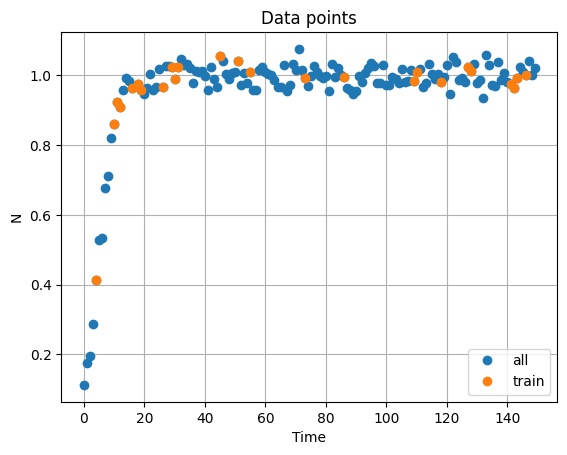

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 9.025e-01, pinn loss: 4.657e-08, data loss: 9.025e-01, r: 0.010, K: 1.000000
It: 100, Loss: 5.538e-01, pinn loss: 1.274e-09, data loss: 5.538e-01, r: -0.000, K: 1.000000
It: 200, Loss: 1.685e-01, pinn loss: 4.431e-09, data loss: 1.685e-01, r: 0.000, K: 1.000000
It: 300, Loss: 1.549e-02, pinn loss: 1.012e-08, data loss: 1.549e-02, r: 0.001, K: 1.000000
It: 400, Loss: 1.341e-02, pinn loss: 1.381e-08, data loss: 1.341e-02, r: 0.002, K: 1.000000
It: 500, Loss: 1.313e-02, pinn loss: 1.324e-08, data loss: 1.313e-02, r: 0.004, K: 1.000000
It: 600, Loss: 1.283e-02, pinn loss: 1.068e-08, data loss: 1.283e-02, r: 0.007, K: 1.000000
It: 700, Loss: 1.252e-02, pinn loss: 7.827e-09, data loss: 1.252e-02, r: 0.009, K: 1.000000
It: 800, Loss: 1.220e-02, pinn loss: 7.990e-09, data loss: 1.220e-02, r: 0.012, K: 1.000000
It: 900, Loss: 1.186e-02, pinn loss: 2.019e-08, data loss: 1.186e-02, r: 0.016, K: 1.000000
Loss: 4.265e-04, pinn loss: 1.157e

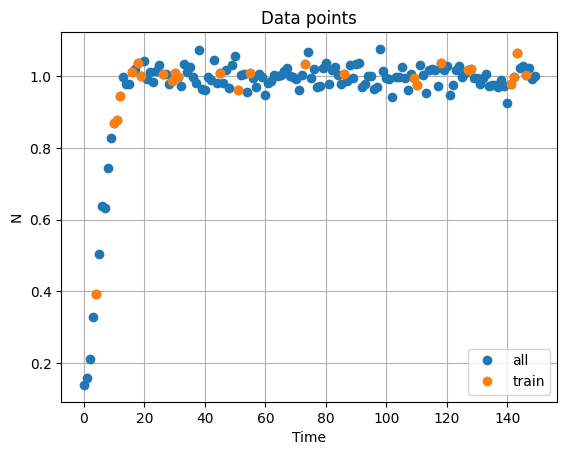

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 6.270e-01, pinn loss: 2.258e-06, data loss: 6.270e-01, r: 0.010, K: 1.000000
It: 100, Loss: 3.111e-01, pinn loss: 4.557e-08, data loss: 3.111e-01, r: 0.001, K: 1.000000
It: 200, Loss: 4.317e-02, pinn loss: 2.346e-08, data loss: 4.317e-02, r: 0.001, K: 1.000000
It: 300, Loss: 1.424e-02, pinn loss: 8.608e-08, data loss: 1.424e-02, r: 0.002, K: 1.000000
It: 400, Loss: 1.396e-02, pinn loss: 1.200e-07, data loss: 1.396e-02, r: 0.003, K: 1.000000
It: 500, Loss: 1.370e-02, pinn loss: 1.539e-07, data loss: 1.370e-02, r: 0.005, K: 1.000000
It: 600, Loss: 1.341e-02, pinn loss: 2.001e-07, data loss: 1.341e-02, r: 0.006, K: 1.000000
It: 700, Loss: 1.309e-02, pinn loss: 2.665e-07, data loss: 1.309e-02, r: 0.008, K: 1.000000
It: 800, Loss: 1.279e-02, pinn loss: 3.652e-07, data loss: 1.279e-02, r: 0.011, K: 1.000000
It: 900, Loss: 1.253e-02, pinn loss: 5.101e-07, data loss: 1.253e-02, r: 0.014, K: 1.000000
Loss: 4.449e-04, pinn loss: 1.817e-

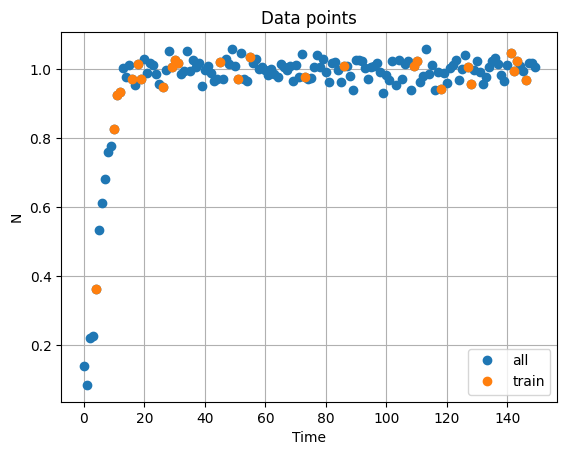

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.448e+00, pinn loss: 8.622e-06, data loss: 1.448e+00, r: 0.010, K: 1.000000
It: 100, Loss: 9.502e-01, pinn loss: 3.168e-09, data loss: 9.502e-01, r: 0.005, K: 1.000000
It: 200, Loss: 2.426e-01, pinn loss: 1.653e-07, data loss: 2.426e-01, r: 0.002, K: 1.000000
It: 300, Loss: 1.848e-02, pinn loss: 2.272e-08, data loss: 1.848e-02, r: 0.001, K: 1.000000
It: 400, Loss: 1.564e-02, pinn loss: 4.895e-08, data loss: 1.564e-02, r: 0.002, K: 1.000000
It: 500, Loss: 1.543e-02, pinn loss: 6.614e-08, data loss: 1.543e-02, r: 0.002, K: 1.000000
It: 600, Loss: 1.521e-02, pinn loss: 8.426e-08, data loss: 1.521e-02, r: 0.003, K: 1.000000
It: 700, Loss: 1.498e-02, pinn loss: 1.042e-07, data loss: 1.498e-02, r: 0.004, K: 1.000000
It: 800, Loss: 1.474e-02, pinn loss: 1.266e-07, data loss: 1.474e-02, r: 0.005, K: 1.000000
It: 900, Loss: 1.449e-02, pinn loss: 1.527e-07, data loss: 1.449e-02, r: 0.007, K: 1.000000
Loss: 7.528e-04, pinn loss: 4.910e-

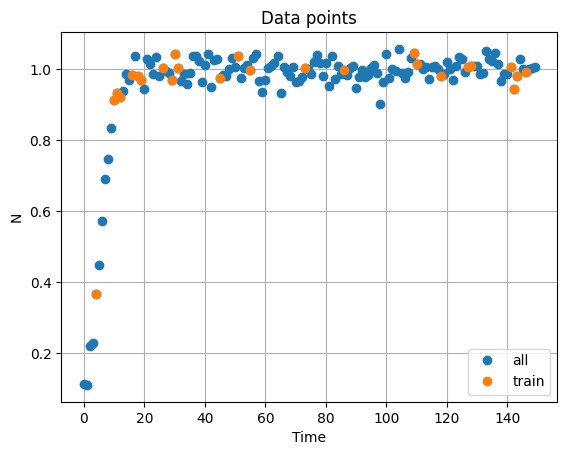

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.182e+00, pinn loss: 1.619e-06, data loss: 1.182e+00, r: 0.010, K: 1.000000
It: 100, Loss: 6.747e-01, pinn loss: 4.947e-07, data loss: 6.747e-01, r: 0.005, K: 1.000000
It: 200, Loss: 1.283e-01, pinn loss: 1.497e-08, data loss: 1.283e-01, r: -0.001, K: 1.000000
It: 300, Loss: 1.658e-02, pinn loss: 1.659e-08, data loss: 1.658e-02, r: -0.001, K: 1.000000
It: 400, Loss: 1.565e-02, pinn loss: 1.795e-08, data loss: 1.565e-02, r: -0.001, K: 1.000000
It: 500, Loss: 1.539e-02, pinn loss: 2.374e-08, data loss: 1.539e-02, r: -0.000, K: 1.000000
It: 600, Loss: 1.513e-02, pinn loss: 2.896e-08, data loss: 1.513e-02, r: 0.001, K: 1.000000
It: 700, Loss: 1.486e-02, pinn loss: 3.152e-08, data loss: 1.486e-02, r: 0.003, K: 1.000000
It: 800, Loss: 1.458e-02, pinn loss: 3.122e-08, data loss: 1.458e-02, r: 0.005, K: 1.000000
It: 900, Loss: 1.430e-02, pinn loss: 2.922e-08, data loss: 1.430e-02, r: 0.008, K: 1.000000
Loss: 5.013e-04, pinn loss: 6.1

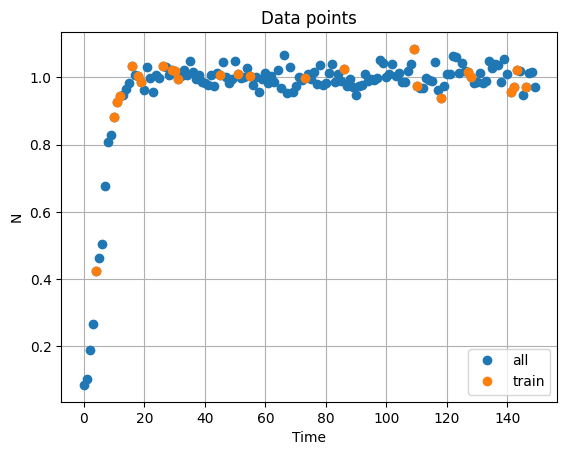

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 9.276e-01, pinn loss: 2.403e-08, data loss: 9.276e-01, r: 0.010, K: 1.000000
It: 100, Loss: 5.696e-01, pinn loss: 1.909e-09, data loss: 5.696e-01, r: -0.000, K: 1.000000
It: 200, Loss: 1.276e-01, pinn loss: 2.549e-09, data loss: 1.276e-01, r: -0.000, K: 1.000000
It: 300, Loss: 1.568e-02, pinn loss: 3.290e-09, data loss: 1.568e-02, r: -0.000, K: 1.000000
It: 400, Loss: 1.405e-02, pinn loss: 3.385e-09, data loss: 1.405e-02, r: -0.000, K: 1.000000
It: 500, Loss: 1.399e-02, pinn loss: 3.758e-09, data loss: 1.399e-02, r: -0.000, K: 1.000000
It: 600, Loss: 1.391e-02, pinn loss: 4.039e-09, data loss: 1.391e-02, r: 0.001, K: 1.000000
It: 700, Loss: 1.384e-02, pinn loss: 4.130e-09, data loss: 1.384e-02, r: 0.001, K: 1.000000
It: 800, Loss: 1.375e-02, pinn loss: 4.060e-09, data loss: 1.375e-02, r: 0.002, K: 1.000000
It: 900, Loss: 1.365e-02, pinn loss: 3.829e-09, data loss: 1.365e-02, r: 0.003, K: 1.000000
Loss: 7.615e-04, pinn loss: 9.

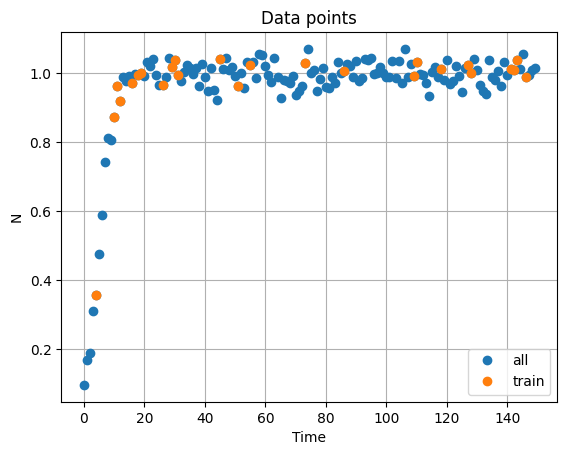

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.011e+00, pinn loss: 6.679e-08, data loss: 1.011e+00, r: 0.010, K: 1.000000
It: 100, Loss: 6.648e-01, pinn loss: 3.425e-09, data loss: 6.648e-01, r: -0.000, K: 1.000000
It: 200, Loss: 1.464e-01, pinn loss: 2.397e-09, data loss: 1.464e-01, r: 0.000, K: 1.000000
It: 300, Loss: 2.021e-02, pinn loss: 1.935e-09, data loss: 2.021e-02, r: 0.001, K: 1.000000
It: 400, Loss: 1.675e-02, pinn loss: 1.730e-09, data loss: 1.675e-02, r: 0.002, K: 1.000000
It: 500, Loss: 1.671e-02, pinn loss: 1.420e-09, data loss: 1.671e-02, r: 0.003, K: 1.000000
It: 600, Loss: 1.668e-02, pinn loss: 1.409e-09, data loss: 1.668e-02, r: 0.003, K: 1.000000
It: 700, Loss: 1.664e-02, pinn loss: 1.444e-09, data loss: 1.664e-02, r: 0.004, K: 1.000000
It: 800, Loss: 1.660e-02, pinn loss: 1.483e-09, data loss: 1.660e-02, r: 0.004, K: 1.000000
It: 900, Loss: 1.655e-02, pinn loss: 1.520e-09, data loss: 1.655e-02, r: 0.004, K: 1.000000
Loss: 4.751e-04, pinn loss: 1.721e

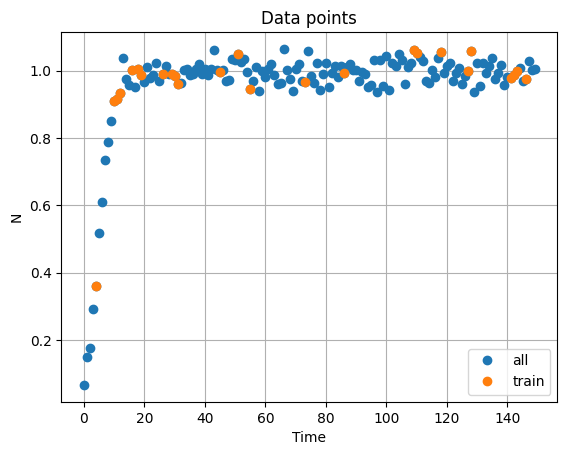

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.059e+00, pinn loss: 3.201e-07, data loss: 1.059e+00, r: 0.010, K: 1.000000
It: 100, Loss: 6.508e-01, pinn loss: 1.824e-09, data loss: 6.508e-01, r: 0.000, K: 1.000000
It: 200, Loss: 2.284e-01, pinn loss: 1.942e-09, data loss: 2.284e-01, r: 0.000, K: 1.000000
It: 300, Loss: 2.510e-02, pinn loss: 3.573e-09, data loss: 2.510e-02, r: 0.001, K: 1.000000
It: 400, Loss: 1.634e-02, pinn loss: 4.144e-09, data loss: 1.634e-02, r: 0.002, K: 1.000000
It: 500, Loss: 1.623e-02, pinn loss: 3.270e-09, data loss: 1.623e-02, r: 0.003, K: 1.000000
It: 600, Loss: 1.612e-02, pinn loss: 2.778e-09, data loss: 1.612e-02, r: 0.004, K: 1.000000
It: 700, Loss: 1.598e-02, pinn loss: 2.459e-09, data loss: 1.598e-02, r: 0.005, K: 1.000000
It: 800, Loss: 1.581e-02, pinn loss: 2.066e-09, data loss: 1.581e-02, r: 0.006, K: 1.000000
It: 900, Loss: 1.560e-02, pinn loss: 1.570e-09, data loss: 1.560e-02, r: 0.008, K: 1.000000
Loss: 8.740e-04, pinn loss: 1.792e-

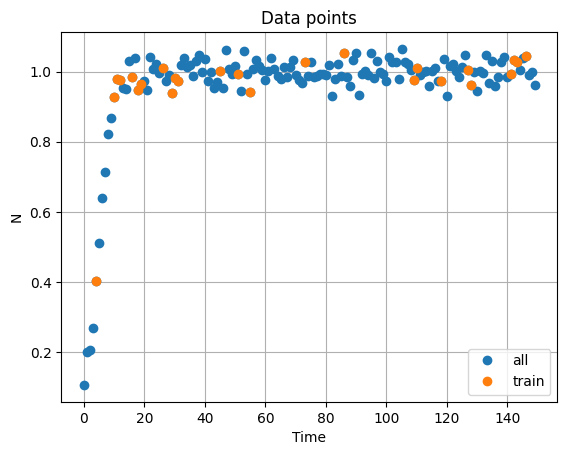

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 5.973e-01, pinn loss: 2.604e-06, data loss: 5.973e-01, r: 0.010, K: 1.000000
It: 100, Loss: 3.229e-01, pinn loss: 1.001e-07, data loss: 3.229e-01, r: 0.001, K: 1.000000
It: 200, Loss: 3.819e-02, pinn loss: 6.237e-09, data loss: 3.819e-02, r: 0.000, K: 1.000000
It: 300, Loss: 1.365e-02, pinn loss: 1.680e-08, data loss: 1.365e-02, r: 0.001, K: 1.000000
It: 400, Loss: 1.339e-02, pinn loss: 3.121e-08, data loss: 1.339e-02, r: 0.001, K: 1.000000
It: 500, Loss: 1.309e-02, pinn loss: 5.352e-08, data loss: 1.309e-02, r: 0.002, K: 1.000000
It: 600, Loss: 1.275e-02, pinn loss: 8.708e-08, data loss: 1.275e-02, r: 0.003, K: 1.000000
It: 700, Loss: 1.238e-02, pinn loss: 1.374e-07, data loss: 1.238e-02, r: 0.004, K: 1.000000
It: 800, Loss: 1.202e-02, pinn loss: 2.117e-07, data loss: 1.202e-02, r: 0.006, K: 1.000000
It: 900, Loss: 1.173e-02, pinn loss: 3.142e-07, data loss: 1.173e-02, r: 0.009, K: 1.000000
Loss: 7.074e-04, pinn loss: 3.142e-

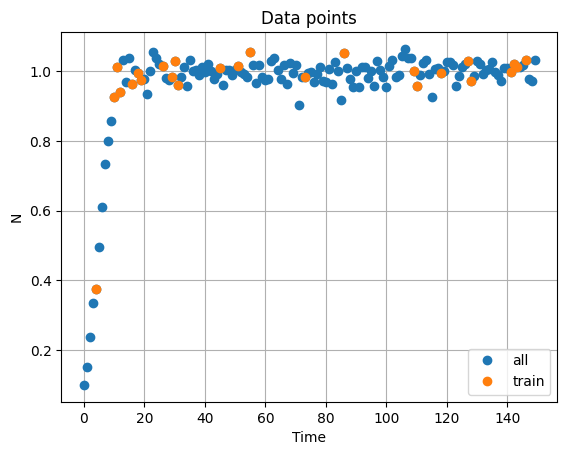

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.156e+00, pinn loss: 1.105e-06, data loss: 1.156e+00, r: 0.010, K: 1.000000
It: 100, Loss: 6.477e-01, pinn loss: 1.903e-07, data loss: 6.477e-01, r: 0.003, K: 1.000000
It: 200, Loss: 1.130e-01, pinn loss: 6.971e-09, data loss: 1.130e-01, r: 0.001, K: 1.000000
It: 300, Loss: 1.568e-02, pinn loss: 1.566e-08, data loss: 1.568e-02, r: 0.002, K: 1.000000
It: 400, Loss: 1.491e-02, pinn loss: 2.186e-08, data loss: 1.491e-02, r: 0.004, K: 1.000000
It: 500, Loss: 1.480e-02, pinn loss: 1.843e-08, data loss: 1.480e-02, r: 0.006, K: 1.000000
It: 600, Loss: 1.468e-02, pinn loss: 1.572e-08, data loss: 1.468e-02, r: 0.008, K: 1.000000
It: 700, Loss: 1.454e-02, pinn loss: 1.477e-08, data loss: 1.454e-02, r: 0.009, K: 1.000000
It: 800, Loss: 1.439e-02, pinn loss: 1.682e-08, data loss: 1.439e-02, r: 0.011, K: 1.000000
It: 900, Loss: 1.423e-02, pinn loss: 2.421e-08, data loss: 1.423e-02, r: 0.013, K: 1.000000
Loss: 7.288e-04, pinn loss: 1.696e-

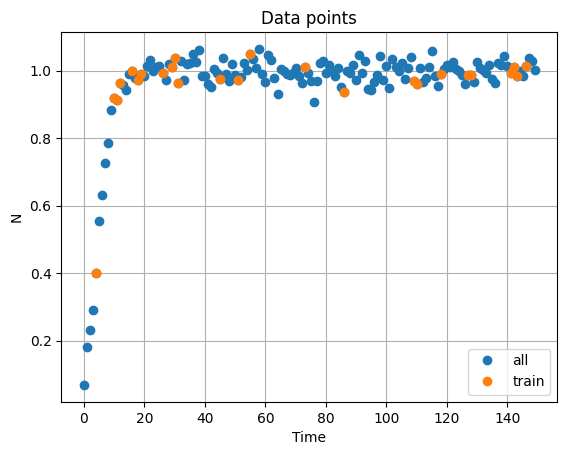

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 4.293e-01, pinn loss: 4.448e-06, data loss: 4.293e-01, r: 0.010, K: 1.000000
It: 100, Loss: 2.029e-01, pinn loss: 1.784e-07, data loss: 2.029e-01, r: 0.002, K: 1.000000
It: 200, Loss: 2.909e-02, pinn loss: 2.513e-09, data loss: 2.909e-02, r: 0.001, K: 1.000000
It: 300, Loss: 1.341e-02, pinn loss: 1.397e-08, data loss: 1.341e-02, r: 0.001, K: 1.000000
It: 400, Loss: 1.331e-02, pinn loss: 1.967e-08, data loss: 1.331e-02, r: 0.001, K: 1.000000
It: 500, Loss: 1.320e-02, pinn loss: 2.629e-08, data loss: 1.320e-02, r: 0.002, K: 1.000000
It: 600, Loss: 1.307e-02, pinn loss: 3.488e-08, data loss: 1.307e-02, r: 0.002, K: 1.000000
It: 700, Loss: 1.294e-02, pinn loss: 4.651e-08, data loss: 1.294e-02, r: 0.003, K: 1.000000
It: 800, Loss: 1.278e-02, pinn loss: 6.270e-08, data loss: 1.278e-02, r: 0.004, K: 1.000000
It: 900, Loss: 1.263e-02, pinn loss: 8.518e-08, data loss: 1.263e-02, r: 0.005, K: 1.000000
Loss: 5.714e-04, pinn loss: 1.179e-

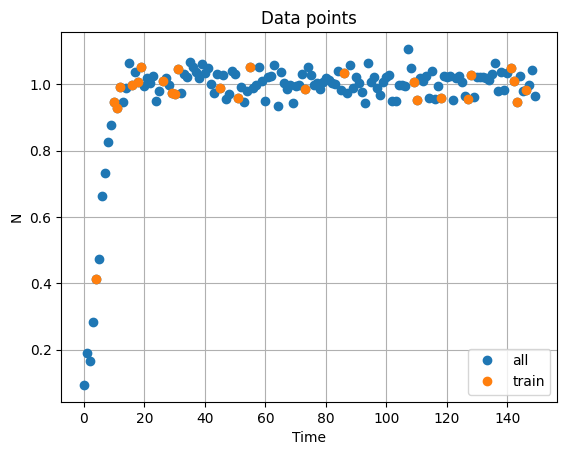

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 7.051e-01, pinn loss: 1.463e-06, data loss: 7.051e-01, r: 0.010, K: 1.000000
It: 100, Loss: 3.360e-01, pinn loss: 4.047e-08, data loss: 3.360e-01, r: 0.001, K: 1.000000
It: 200, Loss: 4.184e-02, pinn loss: 3.507e-09, data loss: 4.184e-02, r: -0.000, K: 1.000000
It: 300, Loss: 1.401e-02, pinn loss: 6.775e-09, data loss: 1.401e-02, r: 0.000, K: 1.000000
It: 400, Loss: 1.386e-02, pinn loss: 1.251e-08, data loss: 1.386e-02, r: 0.000, K: 1.000000
It: 500, Loss: 1.372e-02, pinn loss: 2.160e-08, data loss: 1.372e-02, r: 0.001, K: 1.000000
It: 600, Loss: 1.358e-02, pinn loss: 3.391e-08, data loss: 1.358e-02, r: 0.002, K: 1.000000
It: 700, Loss: 1.343e-02, pinn loss: 4.904e-08, data loss: 1.343e-02, r: 0.003, K: 1.000000
It: 800, Loss: 1.329e-02, pinn loss: 6.648e-08, data loss: 1.329e-02, r: 0.004, K: 1.000000
It: 900, Loss: 1.317e-02, pinn loss: 8.555e-08, data loss: 1.317e-02, r: 0.006, K: 1.000000
Loss: 1.032e-03, pinn loss: 1.655e

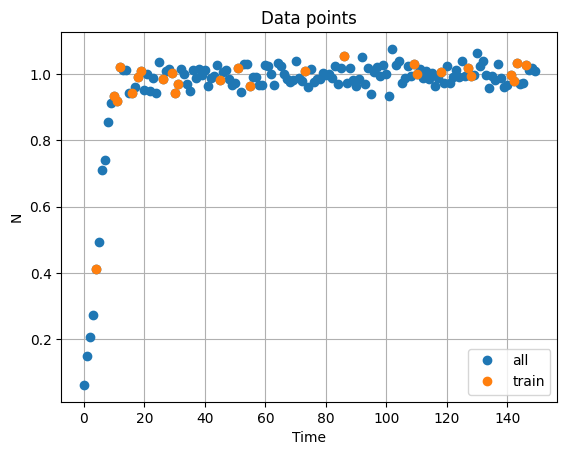

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 7.797e-01, pinn loss: 6.831e-07, data loss: 7.797e-01, r: 0.010, K: 1.000000
It: 100, Loss: 3.914e-01, pinn loss: 1.786e-09, data loss: 3.914e-01, r: 0.001, K: 1.000000
It: 200, Loss: 4.008e-02, pinn loss: 1.787e-08, data loss: 4.008e-02, r: 0.002, K: 1.000000
It: 300, Loss: 1.235e-02, pinn loss: 8.342e-08, data loss: 1.235e-02, r: 0.004, K: 1.000000
It: 400, Loss: 1.225e-02, pinn loss: 7.738e-08, data loss: 1.225e-02, r: 0.006, K: 1.000000
It: 500, Loss: 1.213e-02, pinn loss: 7.045e-08, data loss: 1.213e-02, r: 0.007, K: 1.000000
It: 600, Loss: 1.201e-02, pinn loss: 6.815e-08, data loss: 1.201e-02, r: 0.009, K: 1.000000
It: 700, Loss: 1.187e-02, pinn loss: 7.310e-08, data loss: 1.187e-02, r: 0.011, K: 1.000000
It: 800, Loss: 1.172e-02, pinn loss: 8.904e-08, data loss: 1.172e-02, r: 0.013, K: 1.000000
It: 900, Loss: 1.157e-02, pinn loss: 1.214e-07, data loss: 1.157e-02, r: 0.015, K: 1.000000
Loss: 7.384e-04, pinn loss: 1.387e-

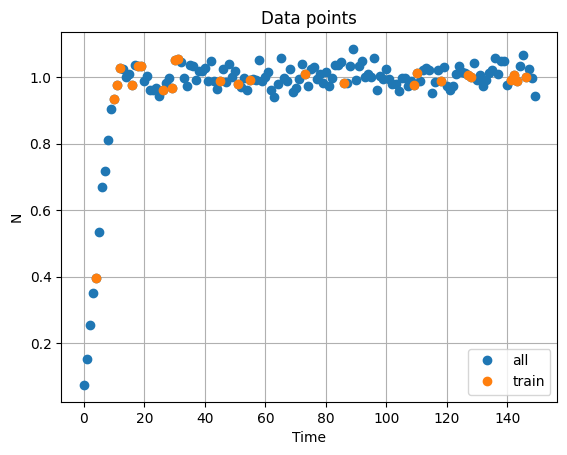

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.147e+00, pinn loss: 9.734e-07, data loss: 1.147e+00, r: 0.010, K: 1.000000
It: 100, Loss: 7.317e-01, pinn loss: 2.517e-07, data loss: 7.317e-01, r: 0.004, K: 1.000000
It: 200, Loss: 2.298e-01, pinn loss: 2.538e-09, data loss: 2.298e-01, r: -0.000, K: 1.000000
It: 300, Loss: 2.364e-02, pinn loss: 3.276e-09, data loss: 2.364e-02, r: 0.000, K: 1.000000
It: 400, Loss: 1.443e-02, pinn loss: 3.639e-09, data loss: 1.443e-02, r: 0.001, K: 1.000000
It: 500, Loss: 1.431e-02, pinn loss: 4.181e-09, data loss: 1.431e-02, r: 0.001, K: 1.000000
It: 600, Loss: 1.425e-02, pinn loss: 4.440e-09, data loss: 1.425e-02, r: 0.002, K: 1.000000
It: 700, Loss: 1.419e-02, pinn loss: 4.477e-09, data loss: 1.419e-02, r: 0.002, K: 1.000000
It: 800, Loss: 1.413e-02, pinn loss: 4.323e-09, data loss: 1.413e-02, r: 0.003, K: 1.000000
It: 900, Loss: 1.406e-02, pinn loss: 4.024e-09, data loss: 1.406e-02, r: 0.004, K: 1.000000
Loss: 5.568e-04, pinn loss: 1.029e

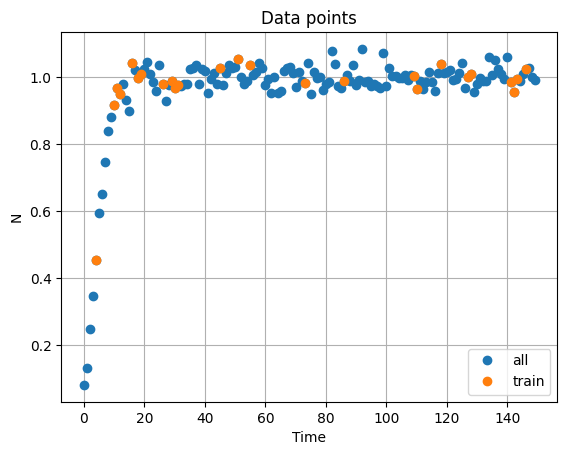

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.634e+00, pinn loss: 1.509e-05, data loss: 1.634e+00, r: 0.010, K: 1.000000
It: 100, Loss: 1.136e+00, pinn loss: 1.659e-07, data loss: 1.136e+00, r: 0.004, K: 1.000000
It: 200, Loss: 3.743e-01, pinn loss: 4.863e-07, data loss: 3.743e-01, r: 0.003, K: 1.000000
It: 300, Loss: 2.239e-02, pinn loss: 6.890e-09, data loss: 2.239e-02, r: 0.001, K: 1.000000
It: 400, Loss: 1.183e-02, pinn loss: 1.281e-08, data loss: 1.183e-02, r: 0.001, K: 1.000000
It: 500, Loss: 1.176e-02, pinn loss: 1.640e-08, data loss: 1.176e-02, r: 0.001, K: 1.000000
It: 600, Loss: 1.171e-02, pinn loss: 1.982e-08, data loss: 1.171e-02, r: 0.001, K: 1.000000
It: 700, Loss: 1.166e-02, pinn loss: 2.409e-08, data loss: 1.166e-02, r: 0.002, K: 1.000000
It: 800, Loss: 1.160e-02, pinn loss: 2.941e-08, data loss: 1.160e-02, r: 0.002, K: 1.000000
It: 900, Loss: 1.153e-02, pinn loss: 3.605e-08, data loss: 1.153e-02, r: 0.002, K: 1.000000
Loss: 6.341e-04, pinn loss: 6.070e-

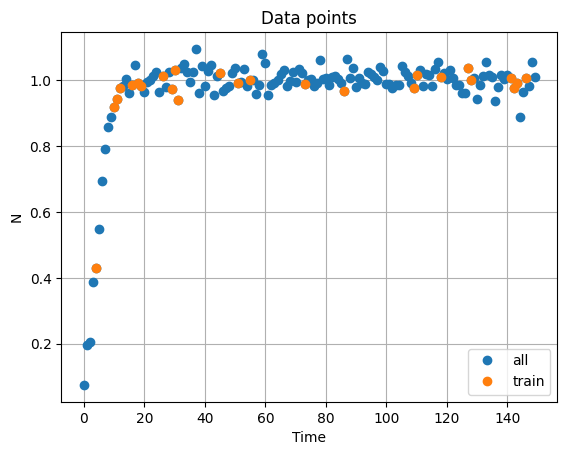

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 8.655e-01, pinn loss: 1.819e-07, data loss: 8.655e-01, r: 0.010, K: 1.000000
It: 100, Loss: 4.597e-01, pinn loss: 2.582e-09, data loss: 4.597e-01, r: 0.000, K: 1.000000
It: 200, Loss: 9.514e-02, pinn loss: 5.391e-09, data loss: 9.514e-02, r: 0.001, K: 1.000000
It: 300, Loss: 1.429e-02, pinn loss: 8.378e-09, data loss: 1.429e-02, r: 0.001, K: 1.000000
It: 400, Loss: 1.207e-02, pinn loss: 1.204e-08, data loss: 1.207e-02, r: 0.003, K: 1.000000
It: 500, Loss: 1.199e-02, pinn loss: 9.953e-09, data loss: 1.199e-02, r: 0.004, K: 1.000000
It: 600, Loss: 1.191e-02, pinn loss: 7.786e-09, data loss: 1.191e-02, r: 0.005, K: 1.000000
It: 700, Loss: 1.182e-02, pinn loss: 6.283e-09, data loss: 1.182e-02, r: 0.007, K: 1.000000
It: 800, Loss: 1.173e-02, pinn loss: 5.193e-09, data loss: 1.173e-02, r: 0.008, K: 1.000000
It: 900, Loss: 1.162e-02, pinn loss: 4.343e-09, data loss: 1.162e-02, r: 0.009, K: 1.000000
Loss: 4.049e-04, pinn loss: 2.430e-

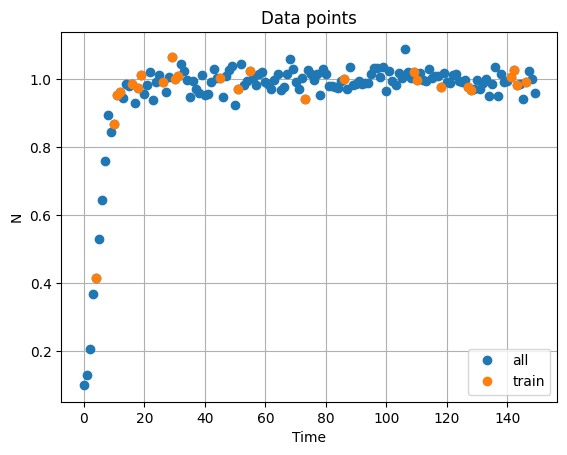

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 6.004e-01, pinn loss: 2.525e-06, data loss: 6.004e-01, r: 0.010, K: 1.000000
It: 100, Loss: 3.424e-01, pinn loss: 8.593e-08, data loss: 3.424e-01, r: 0.001, K: 1.000000
It: 200, Loss: 8.026e-02, pinn loss: 7.179e-09, data loss: 8.026e-02, r: 0.000, K: 1.000000
It: 300, Loss: 1.426e-02, pinn loss: 1.658e-08, data loss: 1.426e-02, r: 0.001, K: 1.000000
It: 400, Loss: 1.311e-02, pinn loss: 2.384e-08, data loss: 1.311e-02, r: 0.002, K: 1.000000
It: 500, Loss: 1.303e-02, pinn loss: 2.698e-08, data loss: 1.303e-02, r: 0.002, K: 1.000000
It: 600, Loss: 1.294e-02, pinn loss: 3.051e-08, data loss: 1.294e-02, r: 0.003, K: 1.000000
It: 700, Loss: 1.283e-02, pinn loss: 3.492e-08, data loss: 1.283e-02, r: 0.004, K: 1.000000
It: 800, Loss: 1.270e-02, pinn loss: 4.052e-08, data loss: 1.270e-02, r: 0.004, K: 1.000000
It: 900, Loss: 1.256e-02, pinn loss: 4.783e-08, data loss: 1.256e-02, r: 0.006, K: 1.000000
Loss: 5.604e-04, pinn loss: 7.300e-

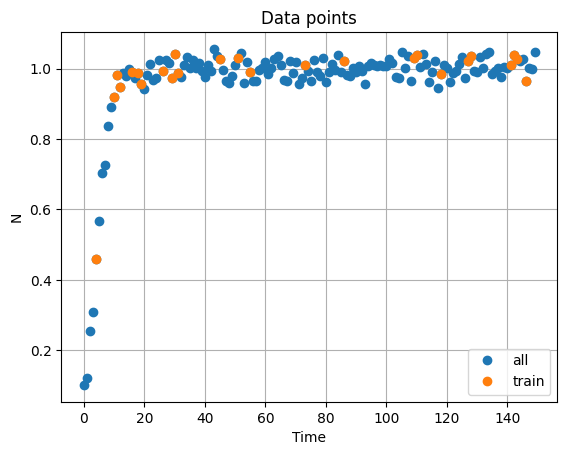

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 1.510e+00, pinn loss: 9.283e-06, data loss: 1.510e+00, r: 0.010, K: 1.000000
It: 100, Loss: 1.067e+00, pinn loss: 9.870e-08, data loss: 1.067e+00, r: 0.005, K: 1.000000
It: 200, Loss: 4.097e-01, pinn loss: 2.612e-07, data loss: 4.097e-01, r: 0.003, K: 1.000000
It: 300, Loss: 3.374e-02, pinn loss: 2.443e-08, data loss: 3.374e-02, r: 0.001, K: 1.000000
It: 400, Loss: 1.122e-02, pinn loss: 5.870e-08, data loss: 1.122e-02, r: 0.002, K: 1.000000
It: 500, Loss: 1.097e-02, pinn loss: 7.462e-08, data loss: 1.097e-02, r: 0.002, K: 1.000000
It: 600, Loss: 1.089e-02, pinn loss: 8.428e-08, data loss: 1.089e-02, r: 0.003, K: 1.000000
It: 700, Loss: 1.080e-02, pinn loss: 9.557e-08, data loss: 1.080e-02, r: 0.003, K: 1.000000
It: 800, Loss: 1.069e-02, pinn loss: 1.096e-07, data loss: 1.069e-02, r: 0.004, K: 1.000000
It: 900, Loss: 1.057e-02, pinn loss: 1.274e-07, data loss: 1.057e-02, r: 0.004, K: 1.000000
Loss: 5.080e-04, pinn loss: 2.915e-

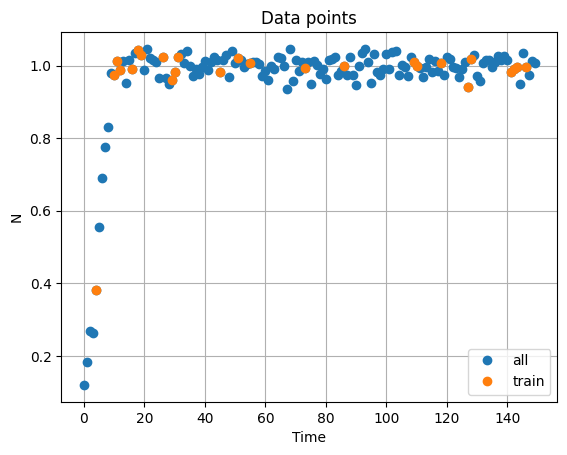

layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 9.847e-01, pinn loss: 1.643e-08, data loss: 9.847e-01, r: 0.010, K: 1.000000
It: 100, Loss: 5.952e-01, pinn loss: 2.342e-09, data loss: 5.952e-01, r: 0.000, K: 1.000000
It: 200, Loss: 1.256e-01, pinn loss: 1.061e-08, data loss: 1.256e-01, r: 0.001, K: 1.000000
It: 300, Loss: 1.550e-02, pinn loss: 1.252e-08, data loss: 1.550e-02, r: 0.002, K: 1.000000
It: 400, Loss: 1.467e-02, pinn loss: 1.036e-08, data loss: 1.467e-02, r: 0.005, K: 1.000000
It: 500, Loss: 1.464e-02, pinn loss: 7.333e-09, data loss: 1.464e-02, r: 0.006, K: 1.000000
It: 600, Loss: 1.460e-02, pinn loss: 5.898e-09, data loss: 1.460e-02, r: 0.007, K: 1.000000
It: 700, Loss: 1.456e-02, pinn loss: 4.780e-09, data loss: 1.456e-02, r: 0.009, K: 1.000000
It: 800, Loss: 1.451e-02, pinn loss: 3.636e-09, data loss: 1.451e-02, r: 0.010, K: 1.000000
It: 900, Loss: 1.446e-02, pinn loss: 2.426e-09, data loss: 1.446e-02, r: 0.011, K: 1.000000
Loss: 4.312e-04, pinn loss: 1.248e-

<Figure size 640x480 with 0 Axes>

In [ ]:
# Step 2. Setup Training
print("Step 2. Set Up Training")

"""## Configurations"""

layers = [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
t_colloc = np.expand_dims(np.arange(0, 150.0, 0.001),axis=1)

"""## Training on Non-noisy Data"""

adam_epochs = 1000
polish_adam_epochs = 2000
bfgs_epochs = 2000

true_alphas = np.arange(0.0, 0.5, 0.5/100.0) # can also test on a smaller set [0.01,0.02,0.05,0.1,0.3,0.5] which will run faster

print("true alphas: ", true_alphas)

inferred_alphas = []
for idx,alpha in enumerate(true_alphas):
  # train a PINN for each alpha
  data = generate_data(noise=0.03,alpha=alpha,id=idx)
  model = PhysicsInformedNN(t_colloc, layers, data["t_train"], data["N_train"])
  model.train(adam_epochs, bfgs_epochs, polish_adam_epochs)
  print("estimated alpha: ",model.r.item())
  inferred_alphas.append(model.r.item())

In [ ]:
print("true alphas: ",true_alphas)
print("inferred alphas",inferred_alphas)

np.savetxt('inferred_alphas.csv', inferred_alphas, delimiter=',',header='inferred alphas')

true alphas:  [0.    0.005 0.01  0.015 0.02  0.025 0.03  0.035 0.04  0.045 0.05  0.055
 0.06  0.065 0.07  0.075 0.08  0.085 0.09  0.095 0.1   0.105 0.11  0.115
 0.12  0.125 0.13  0.135 0.14  0.145 0.15  0.155 0.16  0.165 0.17  0.175
 0.18  0.185 0.19  0.195 0.2   0.205 0.21  0.215 0.22  0.225 0.23  0.235
 0.24  0.245 0.25  0.255 0.26  0.265 0.27  0.275 0.28  0.285 0.29  0.295
 0.3   0.305 0.31  0.315 0.32  0.325 0.33  0.335 0.34  0.345 0.35  0.355
 0.36  0.365 0.37  0.375 0.38  0.385 0.39  0.395 0.4   0.405 0.41  0.415
 0.42  0.425 0.43  0.435 0.44  0.445 0.45  0.455 0.46  0.465 0.47  0.475
 0.48  0.485 0.49  0.495]
inferred alphas [4.1852108552120626e-05, 0.005378918722271919, 0.009863650426268578, 0.01496865227818489, 0.019695501774549484, 0.024503424763679504, 0.029932966455817223, 0.03626313805580139, 0.039735347032547, 0.045748550444841385, 0.04833364859223366, 0.055817827582359314, 0.057718921452760696, 0.058786552399396896, 0.06966355443000793, 0.07871092855930328, 0.08065962046

len(true_alphas) =  100
len(inferred_alphas) =  100


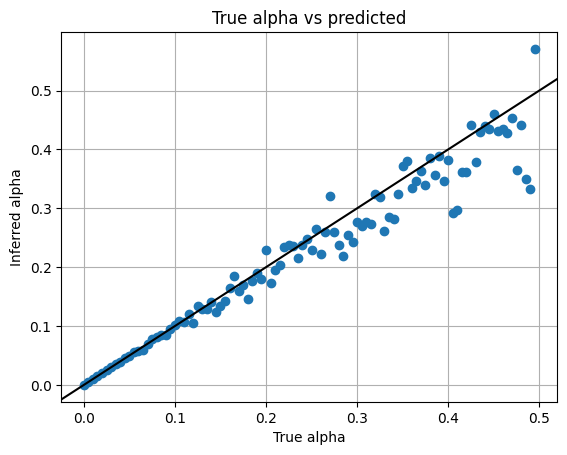

In [ ]:
print("len(true_alphas) = ",len(true_alphas))
print("len(inferred_alphas) = ",len(inferred_alphas))

plt.plot(true_alphas,inferred_alphas,'o')
plt.xlabel("True alpha")
plt.ylabel("Inferred alpha")
plt.gca().axline((0, 0), slope=1,c='k')
plt.title("True alpha vs predicted")
plt.grid()

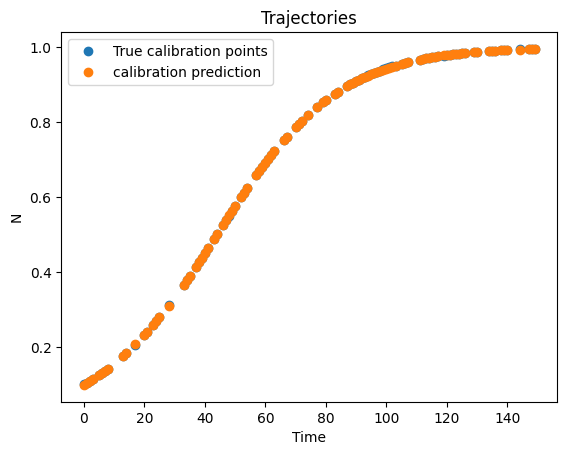

In [ ]:
# evaluations
u_pred= model.predict(model.t_colloc) # predict on collocation time-points
u_pred_calibration = model.predict(t_cal) # predict on calibration points
# print(u_pred)

plt.title("Trajectories")
plt.xlabel('Time')
plt.ylabel("N")
# plt.plot(t_train, N_train, 'o',label='train data')
plt.plot(t_cal,N_cal,'o',label='True calibration points')
plt.plot(t_cal, u_pred_calibration, 'o',label='calibration prediction')
# plt.plot(t_test, N_test, 'o',label='test data')
# plt.plot(model.t_colloc.detach().cpu().numpy(), u_pred[:, 0],'-', label='PINN approximation', color='r')
plt.savefig('trajectories')
plt.legend()
plt.show()

In [ ]:
class Conformalizer():
  def __init__(self,
               pre_trained_model,
               non_conformity_func,
               delta,
               calib_data):

    # Initialize the conformalizer with required parameters
    self.point_predictor = pre_trained_model
    self.non_conformity_func = non_conformity_func
    self.n_calib = calib_data['X'].shape[0]
    self.delta = delta
    #self.X_calib, self.y_calib = calib_data['X'], calib_data['y']
    self._calibrate(calib_data['X'], calib_data['y'])


  def _calculate_quantile(self, scores_calib, delta):
    # Calculate the quantile value based on delta and non-conformity scores
    self.which_quantile = np.ceil((self.delta)*(self.n_calib + 1))/self.n_calib
    return np.quantile(scores_calib, self.which_quantile, method='lower')


  def _calibrate(self, X_calib, y_calib):
    # Calibrate the conformalizer to calculate q_hat
    y_calib_pred = self.point_predictor.predict(X_calib)
    scores_calib = self.non_conformity_func(y_calib_pred, y_calib)
    self.q_hat = self._calculate_quantile(scores_calib, self.delta)


  def predict(self, X):
    # Returns the predicted interval
    y_pred = self.point_predictor.predict(X)
    y_lower, y_upper = y_pred - self.q_hat, y_pred + self.q_hat
    return y_lower, y_pred, y_upper

In [ ]:
def non_conformity_func(y, y_hat):
  return np.abs(y - y_hat)

In [ ]:
t_cal.shape, N_cal.shape

((100, 1), (100, 1))

In [ ]:
fresh_points_for_conformalizer_X = t_cal
fresh_points_for_conformalizer_y = N_cal

In [ ]:
alpha = 0.07
sig_level_delta = 1 - alpha
calib_data, valid_data = {}, {}
n_calib = 80
n_valid = fresh_points_for_conformalizer_X.shape[0] - n_calib

lower_bound, upper_bound, exact_coverage = sig_level_delta, (sig_level_delta + 1/(n_calib+1)), (np.ceil((n_calib+1)*sig_level_delta))/(n_calib+1)
# To see how the relations for upper bound and the exact coverage are derived, see the following video:
# Uncertainty Quantification (4A): Implementing Split Conformal - Relation for Prediction Intervals


empirical_coverages_for_all_trials = []
num_trials = 10000

for trial_num in range(num_trials):
  calib_data['X'], valid_data['X'], calib_data['y'], valid_data['y'] = train_test_split(fresh_points_for_conformalizer_X, N_cal, test_size=n_valid)
  conformalized_model = Conformalizer(model, non_conformity_func, sig_level_delta, calib_data)
  y_lower, y_pred, y_upper = conformalized_model.predict(valid_data['X'])
  fraction_within_bounds = np.mean((valid_data['y']  >= y_lower) & (valid_data['y'] <= y_upper))
  empirical_coverage = fraction_within_bounds
  empirical_coverages_for_all_trials.append(empirical_coverage)


In [ ]:
def running_average(arr):
  cumsum = np.cumsum(arr)
  indices = np.arange(1, len(arr) + 1)
  running_avg = cumsum / indices
  return running_avg

In [ ]:
running_averages = running_average(empirical_coverages_for_all_trials)

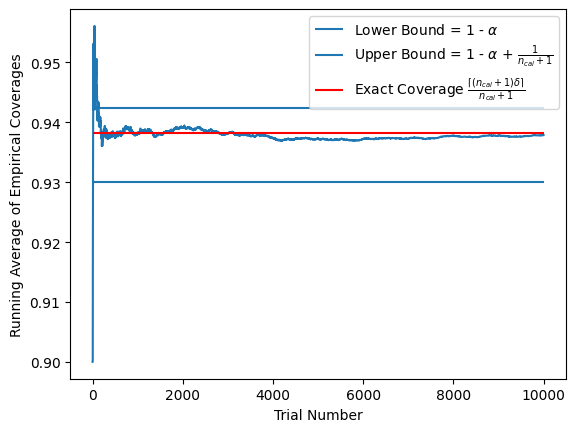

In [ ]:
plt.plot(running_averages)
plt.hlines(lower_bound, 0, num_trials, label=r'Lower Bound = 1 - $\alpha$')
plt.hlines(upper_bound, 0, num_trials, label=r'Upper Bound = 1 - $\alpha$ + $\frac{1}{n_{cal}+1}$')
plt.hlines(exact_coverage, 0, num_trials, label=r'Exact Coverage $\frac{\lceil (n_{cal}+1)\delta \rceil}{n_{cal}+1}$', color='r')
# (np.ceil((n_calib+1)*sig_level_delta))/(n_calib+1)
# \frac{\lceil (n+1) \cdot \text{sig\_level} \rceil}{n+1}
plt.xlabel('Trial Number')
plt.ylabel('Running Average of Empirical Coverages')
plt.legend()
#plt.ylim(0.899, 0.903)

In [ ]:
# Just want to isolate that inside of the loop to know what the interval is
calib_data['X'], valid_data['X'], calib_data['y'], valid_data['y'] = train_test_split(fresh_points_for_conformalizer_X, N_cal, test_size=n_valid)
conformalized_model = Conformalizer(model, non_conformity_func, sig_level_delta, calib_data)
y_lower, y_pred, y_upper = conformalized_model.predict(valid_data['X'])
print((y_upper - y_lower)[0])

# the value is about 0.001 for noiseless data
# the value is about 0.075-0.08 for noise=0.03 data

[0.34989154]
